[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/a_Many_To_Many_BDL_tmpf_and_vsby.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 15 — Many-to-many: two targets at once, then multi-step ahead
- Flavor A (this notebook): predict SEVERAL targets at once - both Y columns placed LAST because split_sequences chops from the right; Dense(2, linear) so one LSTM's weights are shaped by both targets ('borrow strength').
- Flavor B (notebook b_): MULTI-STEP - forecast the next 3 hours (3 outputs); quality degrades further out.
- One recurrent model doing a whole forecasting job - the most general setup in the module.
- Keep to 8 minutes: the 2022 video ran 8:05.
-->


# a_Many To Many (Numeric Sequences)
------------------------------------
**Dr. Dave Wanik - University of Connecticut**

[y is two different variables, at (one) the same timestep]

Let's read in the BDL data and see if we can *predict two quantities at once*! Dewpoint (dwpf) and Mean Sea-level Pressure (mslp).

In [1]:
# import modules
from numpy import array
from tensorflow.keras.preprocessing.text import one_hot
#from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Dense
from keras.layers import Flatten, LSTM
from keras.layers import GlobalMaxPooling1D
from keras.models import Model
#from keras.layers.embeddings import Embedding
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.layers import Input
#from keras.layers.merge import Concatenate
from keras.layers import Bidirectional

import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt

# reproducibility: same seed every run (numbers on CPU match exactly; a GPU may drift a little)
import keras
keras.utils.set_random_seed(5509)


In [2]:
# # https://drive.google.com/file/d/1vhWT7__EDc-WQ7WGnK0RP2qq7-25LCWS/view?usp=sharing
# !gdown 1vhWT7__EDc-WQ7WGnK0RP2qq7-25LCWS
# # read the data
# df = pd.read_csv('../data/cleanBDL.csv')

In [3]:
# Link to the data file on Github
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module4_Files/data/cleanBDL.csv"

# retrieve the CSV data and build a dataframe
df = pd.read_csv(url)

df.shape

(46272, 10)

In [4]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 46272 entries, 0 to 46271
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   valid   46272 non-null  str    
 1   tmpf    46272 non-null  float64
 2   dwpf    46272 non-null  float64
 3   relh    46272 non-null  float64
 4   drct    46272 non-null  float64
 5   sknt    46272 non-null  float64
 6   p01i    46272 non-null  float64
 7   alti    46272 non-null  float64
 8   mslp    46272 non-null  float64
 9   vsby    46272 non-null  float64
dtypes: float64(9), str(1)
memory usage: 4.4 MB


,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,mslp,vsby
0,2015-01-01 00:00:00,17.96,6.08,59.10,190.0,5.0,0.0,30.09,1019.0,10.0
1,2015-01-01 01:00:00,19.94,8.06,59.40,190.0,5.0,0.0,30.08,1018.7,10.0
2,2015-01-01 02:00:00,23.00,6.98,49.69,210.0,9.0,0.0,30.06,1018.1,10.0
3,2015-01-01 03:00:00,21.92,5.00,47.52,230.0,11.0,0.0,30.04,1017.4,10.0
4,2015-01-01 04:00:00,23.00,3.92,43.21,250.0,13.0,0.0,30.05,1017.7,10.0


# Define X and Y
If we are going to use our split sequences script from Brownlee, then we need to make sure our Y variables are on the end!

In [5]:
# let's drop the valid column
# Y will be dwpf and relh
# X will be everything else!

del df['valid']
df.head() # check your work

,tmpf,dwpf,relh,drct,sknt,p01i,alti,mslp,vsby
0,17.96,6.08,59.10,190.0,5.0,0.0,30.09,1019.0,10.0
1,19.94,8.06,59.40,190.0,5.0,0.0,30.08,1018.7,10.0
2,23.00,6.98,49.69,210.0,9.0,0.0,30.06,1018.1,10.0
3,21.92,5.00,47.52,230.0,11.0,0.0,30.04,1017.4,10.0
4,23.00,3.92,43.21,250.0,13.0,0.0,30.05,1017.7,10.0


In [6]:
Y = df[['dwpf', 'mslp']]
X = df.drop(columns=['dwpf', 'mslp'])
print(df.shape, X.shape, Y.shape)

# looks good! Let's prepare samples for modeling

(46272, 9) (46272, 7) (46272, 2)


In [7]:
# put Y all the way on the left
df = pd.concat([X, Y], axis=1, sort=False)
df.head(n=11)

,tmpf,relh,drct,sknt,p01i,alti,vsby,dwpf,mslp
0,17.96,59.10,190.0,5.0,0.0,30.09,10.0,6.08,1019.0
1,19.94,59.40,190.0,5.0,0.0,30.08,10.0,8.06,1018.7
2,23.00,49.69,210.0,9.0,0.0,30.06,10.0,6.98,1018.1
3,21.92,47.52,230.0,11.0,0.0,30.04,10.0,5.00,1017.4
4,23.00,43.21,250.0,13.0,0.0,30.05,10.0,3.92,1017.7
5,23.00,43.21,250.0,11.0,0.0,30.06,10.0,3.92,1018.1
6,23.00,41.45,240.0,13.0,0.0,30.07,10.0,3.02,1018.4
7,24.08,41.30,240.0,11.0,0.0,30.08,10.0,3.92,1018.9
8,26.06,38.03,210.0,8.0,0.0,30.08,10.0,3.92,1018.9
9,28.04,35.05,220.0,14.0,0.0,30.08,10.0,3.92,1018.8


<Axes: xlabel='alti', ylabel='mslp'>

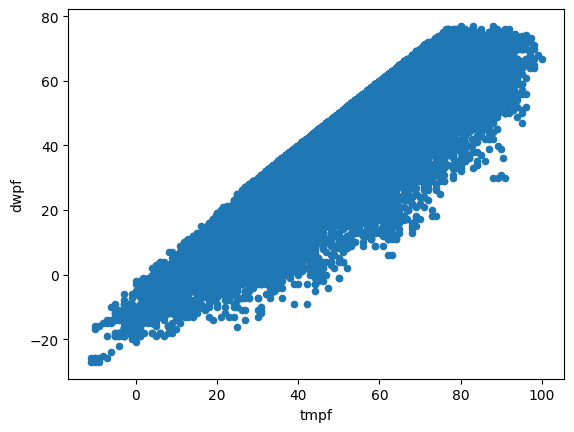

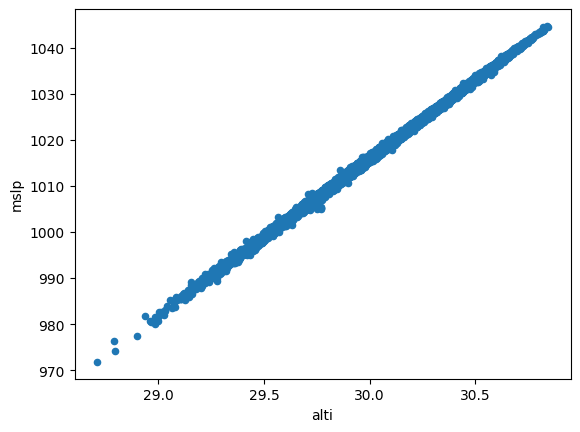

In [8]:
# some eda
df.plot.scatter(x='tmpf', y='dwpf')
df.plot.scatter(x='alti', y='mslp')

In [9]:
# to get our other code to run, we will put Y
# on the end then re-run our code (needs updating from blog)

# prep data for modeling (multivariate)
# link: https://machinelearningmastery.com/how-to-develop-lstm-models-for-time-series-forecasting/

from numpy import array

# split a multivariate sequence into samples
def split_sequences(sequences, n_steps):
	X, y = list(), list()
	for i in np.arange(len(sequences)): # be careful of this line!
		# find the end of this pattern
		end_ix = i + n_steps
		# check if we are beyond the dataset
		if end_ix > len(sequences):
			break
		# gather input and output parts of the pattern
    # X and Y have been UPDATED so the last two columns drop off
		# USERS NEED TO UPDATE THIS FOR THEIR OWN PROBLEMS!!!
		seq_x, seq_y = sequences[i:end_ix, :-2], sequences[end_ix-1, 7:]
		X.append(seq_x)
		y.append(seq_y)
	return np.array(X), np.array(y)

# Prepare Samples for Modeling
Everything needs to be in 3D arrays.

In [10]:
# let's turn X into lookbacks of 10 with all of our samples
# all we need to do is decide on is n_steps (what our lookback period is)
# since we have a bunch of data, why not n_steps=10? then try 30 later on.
n_steps = 10
raw_seq = np.array(df) #make sure your data is stored as a numpy array!
# let's ignore the date column and just use the temperature data
X, y = split_sequences(raw_seq, n_steps=10)

In [11]:
# check your work
print(df.shape, X.shape, y.shape)

(46272, 9) (46263, 10, 7) (46263, 2)


In [12]:
# here's the first X
X[0]

array([[ 17.96,  59.1 , 190.  ,   5.  ,   0.  ,  30.09,  10.  ],
       [ 19.94,  59.4 , 190.  ,   5.  ,   0.  ,  30.08,  10.  ],
       [ 23.  ,  49.69, 210.  ,   9.  ,   0.  ,  30.06,  10.  ],
       [ 21.92,  47.52, 230.  ,  11.  ,   0.  ,  30.04,  10.  ],
       [ 23.  ,  43.21, 250.  ,  13.  ,   0.  ,  30.05,  10.  ],
       [ 23.  ,  43.21, 250.  ,  11.  ,   0.  ,  30.06,  10.  ],
       [ 23.  ,  41.45, 240.  ,  13.  ,   0.  ,  30.07,  10.  ],
       [ 24.08,  41.3 , 240.  ,  11.  ,   0.  ,  30.08,  10.  ],
       [ 26.06,  38.03, 210.  ,   8.  ,   0.  ,  30.08,  10.  ],
       [ 28.04,  35.05, 220.  ,  14.  ,   0.  ,  30.08,  10.  ]])

In [13]:
# here's the first Y
y[0]

# go scroll up and make sure this matches!
# and it does!

# you will need to customize your split script when
# prepping your data... be careful! take control of your data!

array([   3.92, 1018.8 ])

In [14]:
df.head(n=15)

,tmpf,relh,drct,sknt,p01i,alti,vsby,dwpf,mslp
0,17.96,59.10,190.0,5.0,0.0,30.09,10.0,6.08,1019.0
1,19.94,59.40,190.0,5.0,0.0,30.08,10.0,8.06,1018.7
2,23.00,49.69,210.0,9.0,0.0,30.06,10.0,6.98,1018.1
3,21.92,47.52,230.0,11.0,0.0,30.04,10.0,5.00,1017.4
4,23.00,43.21,250.0,13.0,0.0,30.05,10.0,3.92,1017.7
5,23.00,43.21,250.0,11.0,0.0,30.06,10.0,3.92,1018.1
6,23.00,41.45,240.0,13.0,0.0,30.07,10.0,3.02,1018.4
7,24.08,41.30,240.0,11.0,0.0,30.08,10.0,3.92,1018.9
8,26.06,38.03,210.0,8.0,0.0,30.08,10.0,3.92,1018.9
9,28.04,35.05,220.0,14.0,0.0,30.08,10.0,3.92,1018.8


# Fit a Model
This will be similar to the last example in 'Sequence Problems_Pt1.ipynb'

In [15]:
# note how there's a 2 at the end
# usually we did this for a multi-classification problem, but not today!
# by default, it's a 'linear' activiation function
# so this is 2 node output and we're doing regression.

n_steps = X.shape[1]
n_features = X.shape[2]

model = Sequential()
model.add(LSTM(50, activation='relu',
               recurrent_dropout = 0.1,
               input_shape=(n_steps, n_features)))
model.add(Dropout(0.2))
model.add(Dense(2)) # since Y has two values, we need to predict two values
model.compile(optimizer='adam', loss='mse')

import keras
from keras.callbacks import EarlyStopping

# early stopping callback
# This callback will stop the training when there is no improvement in
# the validation loss for 10 consecutive epochs.
es = keras.callbacks.EarlyStopping(monitor='val_loss',
                                   mode='min',
                                   patience=10, # you can play with this!
                                   restore_best_weights=True) # important - otherwise you just return the last weigths...

# now we just update our model fit call
history = model.fit(X,
                    y,
                    callbacks=[es],
                    epochs=800, # you can set this to a big number!
                    batch_size=10,
                    validation_split=0.2,
                    verbose=1)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 9:03:36 9s/step - loss: 502519.1875

   5/3701 ━━━━━━━━━━━━━━━━━━━━ 59s 16ms/step - loss: 495608.9688  

  10/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 482724.5312

  15/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 12ms/step - loss: 472375.3750

  20/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 459240.5312

  25/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 446154.6875

  28/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - loss: 431051.0000

  31/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 14ms/step - loss: 414692.2188

  35/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 14ms/step - loss: 388895.4062

  41/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - loss: 356843.4375

  45/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - loss: 334554.3438

  48/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - loss: 322231.0000

  53/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - loss: 302750.1250

  58/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - loss: 287715.4062

  64/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 14ms/step - loss: 274267.8750

  69/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 260804.5000

  74/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 248697.5156

  78/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 243304.3125

  83/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 233331.0469

  88/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 225498.8438

  93/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 218374.9375

  96/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 214904.6094

 101/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 211084.6406

 105/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 206124.2812

 109/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 201330.2969

 113/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 196891.8906

 116/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 193771.7188

 119/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 190867.2344

 122/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 188022.3594

 127/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 184442.7656

 132/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 180853.9688

 138/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 175954.2656

 143/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 172901.2969

 147/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 170725.3594

 152/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 167835.2656

 156/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 165452.9375

 160/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 163230.2812

 165/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 160417.1562

 171/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 157676.9844

 176/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 154868.8906

 180/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 153025.8594

 184/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 151315.1719

 189/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 148980.8594

 194/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 147121.9844

 197/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 145694.7344

 202/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 143459.9531

 206/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 141917.3438

 210/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 140240.6875

 213/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 139192.4062

 217/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 138027.7188

 222/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 136135.8281

 227/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 134460.3281

 232/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 132932.5312

 237/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 131387.7969

 242/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 129779.8359

 247/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 128050.2188

 251/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 126982.1484

 256/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 125747.6406

 259/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 124828.8828

 264/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 123663.7188

 270/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 122158.8516

 273/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 121550.8281

 277/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 120450.6328

 282/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 119396.8984

 286/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 118912.1875

 289/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 118206.9375

 294/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 117198.4531

 297/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 116700.9609

 301/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 115857.1172

 306/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 114925.2891

 311/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 114054.8516

 315/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 113308.6484

 319/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 112746.9141

 323/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 111947.2031

 327/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 111221.2734

 330/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 110534.9531

 334/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 109708.9688

 337/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 109062.8281

 339/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 108737.7109

 341/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 108385.6328

 342/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 108156.1719

 344/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 107827.0078

 346/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 107583.3047

 348/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 107303.2188

 351/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 106914.8047

 354/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 106707.2422

 357/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 106854.2188

 359/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 106536.0859

 363/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 106099.7031

 366/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 105893.1484

 369/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 105577.4844

 371/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - loss: 105489.2578

 374/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - loss: 105138.3125

 378/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - loss: 104683.2812

 381/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 104286.3828

 385/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 103805.2734

 388/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 103391.2109

 391/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 103009.1719

 394/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 102681.5703

 399/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 102152.3984

 403/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 101667.6875

 406/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 101298.6875

 410/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 100805.0000

 415/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 100195.0625

 418/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 99885.1953 

 421/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 99561.9922

 424/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 99275.4531

 428/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 98794.3516

 432/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 98509.2656

 435/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 98218.9844

 438/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 97895.5391

 442/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 97455.2656

 446/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 96992.2344

 449/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 96757.6328

 453/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 96390.2734

 456/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 96043.3125

 460/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 95745.7578

 463/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 95498.0391

 466/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 95132.6641

 469/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 94737.4609

 473/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 94251.4766

 477/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 93778.8828

 482/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 93416.5547

 488/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 92817.9141

 495/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 92074.4375

 500/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 91495.0156

 505/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - loss: 90955.3672

 509/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - loss: 90645.2812

 513/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - loss: 90210.3984

 517/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - loss: 89756.9688

 522/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - loss: 89403.4219

 528/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - loss: 88901.7266

 532/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - loss: 88443.3047

 537/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 15ms/step - loss: 87976.2109

 541/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 15ms/step - loss: 87743.5156

 545/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 15ms/step - loss: 87320.0938

 550/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 15ms/step - loss: 86967.9219

 555/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 86581.2109

 560/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 86100.3281

 565/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 85574.7031

 570/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 85276.9453

 575/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 84905.9609

 581/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 84426.0391

 585/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 84063.4531

 590/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 83848.1016

 594/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 83663.9375

 598/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 83405.6562

 603/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 83078.2812

 607/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 82776.6328

 611/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 82493.8125

 615/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 82191.2578

 620/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 81841.7422

 623/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 81703.4531

 626/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 81523.0391

 630/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 81246.0547

 633/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 80974.8359

 637/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 80700.3984

 641/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 80425.0625

 646/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 80133.6172

 650/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 79872.9141

 654/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 79684.0156

 658/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 79437.8281

 662/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 79238.4688

 667/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 79031.9141

 671/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 78867.4922

 675/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 78779.7500

 680/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 78626.9453

 684/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 78620.0312

 689/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 78381.0625

 693/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 78252.0703

 698/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 78084.3125

 703/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 77772.1953

 708/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 77530.4922

 713/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 77281.9375

 718/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 77066.6797

 722/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 76883.9922

 727/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 76673.3906

 731/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 76394.6250

 734/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 76289.5938

 739/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 76103.9453

 742/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 75938.5547

 747/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 75690.0156

 750/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 75551.0156

 754/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 75306.2344

 758/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 75097.1172

 763/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 74831.4219

 768/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 74726.1016

 771/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 74618.1016

 774/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 74505.1953

 779/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 74278.0625

 782/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 74092.1719

 786/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 73879.6406

 790/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 73683.6406

 794/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 73494.6641

 798/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 73326.5078

 802/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 73173.8047

 806/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 73011.3750

 809/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 72887.3438

 813/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 72669.9688

 819/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 72377.6094

 823/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 72186.9531

 827/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 72009.4375

 831/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 71863.0312

 835/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 71712.9375

 840/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 71479.2266

 844/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 71272.6641

 849/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 71123.9531

 853/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 71279.5078

 857/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 71158.1406

 861/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 71074.9297

 865/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 70998.5000

 870/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 70879.7969

 874/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 70739.6094

 879/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 70578.5469

 883/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 70372.4219

 886/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 70246.3203

 889/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 70149.5625

 894/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 69982.7422

 898/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 69852.7578

 902/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 69664.7344

 906/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 69496.5703

 910/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 69388.6172

 914/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 69183.8281

 919/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 69027.4844

 923/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 68869.2734

 927/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 68705.6406

 931/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 68605.0391

 935/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 68468.0312

 939/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 68331.1406

 944/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 68164.2344

 948/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 68020.6016

 952/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 67896.5547

 957/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 67765.8125

 961/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 67595.7031

 966/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 67483.1797

 970/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 67317.4531

 974/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 67182.7031

 977/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 67056.2188

 981/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 66924.8438

 986/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 66738.2734

 990/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 66618.1875

 994/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 66461.3828

 999/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 66276.5391

1002/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 66147.9922

1005/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 66016.5703

1009/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 65871.0391

1012/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 65776.8672

1017/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 65617.4609

1021/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 65453.3125

1026/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 65242.6680

1031/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 65157.8164

1035/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 65063.5391

1039/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 64937.0039

1044/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 64825.8945

1048/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 64697.3125

1052/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 64569.9727

1057/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 64381.8086

1061/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 64257.3086

1065/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 64138.1133

1067/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 64076.2070

1071/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 63972.5352

1075/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 63870.8867

1080/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 63683.8828

1085/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 63510.4688

1089/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 63377.6914

1094/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 63219.7422

1097/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 63180.3047

1101/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 63065.3047

1104/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 62985.7500

1108/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 62886.5000

1112/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 62765.6172

1117/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 62608.1016

1121/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 62495.0000

1126/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 62348.2031

1130/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 62185.2617

1135/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 62024.9727

1139/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 61909.6289

1144/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 61799.3242

1148/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 61685.9375

1152/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 61586.5430

1156/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 61504.1484

1159/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 61422.8320

1162/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 61323.2617

1167/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 61171.7266

1171/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 61027.6992

1176/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 60863.6445

1181/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 60724.8359

1185/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 60611.1719

1189/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 60513.5195

1192/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 60442.5039

1196/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 60332.6445

1199/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 60222.3945

1204/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 60078.9648

1208/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 59933.9336

1211/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 59884.6641

1217/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 59759.3828

1219/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 59731.9805

1223/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 59621.8867

1226/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 59560.4531

1230/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 59422.1484

1233/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 59357.1562

1238/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 59214.4062

1243/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 59114.8984

1246/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 59020.1211

1249/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 58934.3477

1252/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 58868.2227

1255/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 58804.3281

1259/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 58700.7305

1262/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 58665.3008

1265/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 58624.2617

1268/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 58550.1328

1272/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 58442.7305

1277/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 58332.8945

1281/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 58250.5273

1285/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 58143.8164

1288/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 58076.2539

1292/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 57998.5352

1297/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 57907.3516

1300/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 57828.0312

1304/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 57743.5742

1309/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 57618.2773

1314/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 57493.4219

1318/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 57421.6250

1322/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 57323.6055

1325/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 57241.5039

1329/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 57157.0898

1332/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 57109.8320

1336/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 57028.5898

1340/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 56939.9922

1343/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 56903.0469

1348/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 56808.1289

1353/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 56721.5664

1356/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 56680.0195

1359/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 56628.8828

1362/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 56576.0547

1366/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 56468.8164

1369/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 56390.6133

1372/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 56335.9375

1375/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 56284.9180

1380/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 56170.6484

1385/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 56027.3828

1391/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 55922.7656

1395/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 55823.9531

1398/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 55757.3125

1402/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 55655.5781

1407/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 55553.8203

1412/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 55411.8281

1415/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 55344.5312

1419/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 55254.8164

1423/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 55157.2773

1427/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 55086.1094

1432/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 54994.7930

1436/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 54894.4727

1440/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 54806.5742

1445/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 54703.7070

1446/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 54689.8945

1448/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 54655.8320

1451/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 54578.5352

1455/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 54485.3555

1459/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 54380.0898

1461/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 54341.4922

1464/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 54280.7266

1469/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 54175.8789

1474/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 54069.5508

1477/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53994.4180

1480/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53922.8633

1483/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53853.1992

1486/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53779.1602

1489/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53730.1523

1492/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53690.0273

1495/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53616.9297

1499/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53531.0312

1501/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53487.9648

1505/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53404.0000

1509/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53317.3555

1512/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53251.2188

1515/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53183.0000

1518/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53123.5703

1523/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 53034.9414

1528/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 52953.4297

1532/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 52871.6055

1537/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 52788.7812

1541/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 52710.7422

1544/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 52641.5820

1548/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 52562.1250

1552/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 52494.8008

1556/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 52396.0312

1561/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 52293.9727

1565/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 52217.8945

1568/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 52150.6172

1572/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 52106.4141

1576/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 52043.2148

1579/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 51985.2344

1582/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 51929.3320

1587/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 51819.7695

1591/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 51743.1992

1596/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 51662.7539

1600/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 51587.6953

1603/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 51519.7148

1607/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 51453.0820

1611/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 51381.0352

1614/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 51313.6055

1617/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 51256.3711

1620/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 51194.8555

1623/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 51151.2188

1626/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 51087.8125

1630/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 51029.3359

1634/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50966.9648

1638/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50879.6055

1642/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50808.7031

1646/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50753.6562

1651/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50666.2031

1656/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50562.5234

1659/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50515.2305

1662/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50456.0352

1667/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50362.3711

1672/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50277.8711

1675/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50235.6562

1679/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50151.9258

1682/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50102.0508

1685/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50051.3008

1688/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 50000.5508

1691/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 49946.2461

1695/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 49876.6680

1699/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 49803.0273

1702/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 49750.5312

1706/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 49698.2539

1709/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 49652.3594

1713/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 49568.6797

1718/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 49473.0391

1723/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 49381.3203

1727/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 49313.2500

1732/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 49238.3242

1737/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 49165.5312

1741/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 49093.8164

1744/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 49037.3945

1748/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 48986.9883

1752/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 48918.1836

1756/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 48845.8906

1760/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 48785.0352

1766/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 48671.4883

1770/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 48614.3359

1776/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 48525.9258

1780/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 48446.7344

1784/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 48377.2227

1788/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 48302.4336

1792/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 48252.3555

1794/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 48232.7344

1799/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 48149.0391

1804/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 48063.8555

1807/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 48022.4648

1811/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 47972.8320

1815/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 47915.4844

1818/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 47873.0508

1822/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 47801.3281

1825/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 47741.1523

1830/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 47677.4883

1835/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 47596.3164

1840/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 47518.8594

1844/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 47458.8008

1848/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 47403.5586

1853/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 47325.5977

1857/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 47258.0703

1861/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 47203.4922

1865/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 47156.5703

1868/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 47108.3906

1872/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 47039.1172

1877/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 46948.7891

1881/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 46898.8242

1885/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 46840.6172

1888/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 46801.6016

1892/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 46753.7305

1895/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 46700.4297

1900/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 46643.3555

1905/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 46571.6055

1908/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 46526.6172

1911/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 46486.9492

1916/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 46411.6562

1919/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 46372.8984

1925/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 46281.8828

1930/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 46187.3242

1933/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 46136.3359

1936/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 46099.1875

1939/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 46055.2188

1942/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 46020.9023

1946/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 45966.5742

1951/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 45909.3398

1954/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 45872.4023

1958/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 45808.3555

1963/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 45728.1094

1966/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 45689.1914

1970/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45629.1094

1975/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45579.1836

1980/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45517.9766

1985/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45475.1680

1989/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45413.0977

1991/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45389.3047

1995/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45354.0234

1999/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45309.3516

2003/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45262.7344

2007/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45204.3867

2009/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45179.0039

2012/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45131.2227

2015/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45094.2578

2017/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45078.1094

2022/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 45006.5078

2025/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 44971.3281

2028/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 44923.6367

2030/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 44902.3438

2033/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 44853.3086

2036/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 44823.8633

2039/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 44789.3555

2043/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 44741.5508

2046/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 44713.0000

2050/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 44661.2422

2053/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 44623.8008

2058/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 44551.7578

2062/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 44504.9180

2067/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 44427.0625

2073/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 44366.1914

2077/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 44323.7773

2081/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 44266.3477

2086/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 44205.3438

2090/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 44147.6289

2094/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 44096.1328

2099/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 44034.8906

2105/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 43957.5625

2110/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 43908.0508

2115/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43836.6523

2120/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43775.8789

2125/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43726.7461

2129/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43678.7422

2135/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43605.9102

2139/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43546.5430

2143/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43508.9141

2146/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43491.0586

2150/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43440.7461

2153/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43400.8789

2156/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43376.0078

2159/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43348.9180

2163/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43292.0352

2169/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43217.4570

2172/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43186.7578

2176/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43144.2422

2179/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 43117.2188

2183/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 43068.7695

2186/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 43033.3438

2190/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42981.2695

2194/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42936.1719

2198/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42890.6758

2202/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42836.7500

2206/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42794.5820

2212/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42720.9570

2216/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42674.4844

2221/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42614.6758

2225/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42571.0234

2229/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42518.8164

2233/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42476.3398

2236/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42438.7617

2239/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42400.4219

2242/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42366.0312

2245/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42324.6641

2247/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42306.4453

2249/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 42287.4023

2252/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 42260.0312

2256/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 42219.2266

2259/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 42198.6328

2264/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 42148.6172

2267/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 42110.7773

2271/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 42061.3750

2274/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 42028.0078

2278/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 41978.0508

2282/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 41926.4727

2285/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 41892.9258

2289/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 41851.1680

2294/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 41788.7930

2297/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 41752.4531

2301/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 41705.7852

2306/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 41641.5117

2310/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 41602.6172

2315/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 41541.7422

2320/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 41481.4414

2323/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 41446.5234

2326/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 41411.4414

2330/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 41369.2383

2334/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 41334.9609

2338/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 41301.3008

2343/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 41247.3320

2349/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 41176.7344

2352/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 41143.4414

2356/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 41118.4766

2360/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 41075.4102

2363/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 41037.7578

2367/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 40992.6992

2371/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 40958.6367

2375/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 40921.6289

2379/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 40875.9805

2383/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 40842.8164

2386/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 40814.6797

2391/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 40766.3359

2395/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 40725.1250

2397/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 40702.8672

2401/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 40650.6914

2404/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 40614.3086

2409/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 40557.4062

2414/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 40498.4883

2419/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 40454.4727

2424/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 40401.5781

2430/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 40337.3398

2434/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 40296.3398

2438/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 40247.8789

2443/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 40195.1562

2448/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 40142.6758

2455/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 40084.2070

2459/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 40035.7344

2464/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39991.7344

2469/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39933.4180

2475/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39877.0977

2479/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39838.4727

2483/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39796.5898

2487/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39753.8320

2491/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39705.6602

2495/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39667.1211

2499/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39630.9922

2503/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39592.1602

2508/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39544.4961

2511/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39520.1133

2515/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39484.0977

2519/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39437.9570

2523/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 39401.8672

2527/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 39363.5781

2532/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 39308.1875

2536/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 39267.2461

2541/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 39229.0586

2545/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 39191.9688

2549/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 39158.4609

2553/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 39116.3555

2558/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 39062.1055

2563/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 39016.7188

2569/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 38962.3203

2573/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 38934.4375

2578/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 38887.7734

2583/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 38839.0273

2587/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 38802.3359

2592/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 38754.3945

2598/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 38693.7383

2603/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 38654.0586

2606/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 38625.4609

2610/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 38590.9375

2614/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 38557.9453

2619/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 38505.3594

2624/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 38462.0234

2628/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 38430.3828

2633/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 38379.4258

2637/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 38341.0664

2642/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 38298.3398

2647/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 38246.2773

2652/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 38200.5273

2657/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 38163.1055

2661/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 38122.4102

2664/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 38099.2109

2667/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 38074.2734

2672/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 38029.0938

2677/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 37993.1719

2681/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 37967.7734

2686/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 37924.7070

2691/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 37887.8203

2695/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 37854.7734

2699/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 37817.8438

2704/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 37767.6836

2708/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 37734.5781

2712/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 37697.7344

2718/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 37655.8516

2722/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 37623.8477

2726/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37588.6289

2731/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37552.0820

2736/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37512.8242

2740/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37484.3398

2744/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37449.6055

2748/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37413.5469

2753/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37372.7422

2755/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37352.5352

2759/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37317.2656

2763/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37282.5625

2767/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37249.0469

2770/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37223.7930

2774/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37190.2188

2778/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37161.2227

2782/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37126.8164

2785/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37103.2109

2788/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37074.6484

2792/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 37047.5273

2796/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 37012.2422

2802/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36960.4023

2807/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36916.6719

2812/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36871.3438

2815/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36844.6523

2820/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36808.7852

2825/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36779.3438

2830/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36738.8398

2836/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36686.1328

2840/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36648.6211

2844/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36623.9922

2849/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36584.2930

2854/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36544.1562

2859/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 36503.1758

2864/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36472.7266

2868/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36440.1680

2871/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36413.2891

2876/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36372.0820

2881/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36333.8711

2885/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36301.4961

2889/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36276.6836

2892/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36252.8711

2896/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36224.9805

2901/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36188.8398

2904/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36162.2227

2908/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36135.5078

2912/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36106.3945

2916/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36075.9766

2921/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36036.3281

2925/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 36008.8984

2928/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 35981.2383

2932/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35958.5547

2935/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35935.0977

2939/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35898.4766

2944/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35860.7031

2948/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35837.1367

2953/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35794.6133

2958/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35754.9922

2963/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35713.5117

2968/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35681.3125

2972/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35649.2891

2976/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35624.7109

2981/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35584.3398

2987/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35537.0156

2992/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35497.6602

2997/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 35462.8086

3002/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35434.3164 

3006/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35398.7266

3011/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35364.0859

3015/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35333.8008

3019/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35307.2812

3024/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35271.3594

3027/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35251.5391

3032/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35213.3516

3036/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35189.9336

3041/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35162.8320

3045/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35137.7109

3050/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35105.0742

3054/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35078.8555

3059/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35049.7383

3064/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 35008.9883

3068/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34982.8320

3072/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34960.4297

3076/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34937.6016

3079/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34914.5859

3082/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34899.4883

3085/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34875.1680

3090/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34841.8867

3093/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34820.8047

3097/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34790.8086

3101/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34757.9805

3102/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34751.1758

3105/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34729.8164

3109/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34704.4727

3113/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34674.9375

3117/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34648.5469

3121/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34620.4336

3126/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34598.9453

3129/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34578.1680

3132/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34563.0898

3135/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34540.6172

3138/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 34519.6992

3141/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34498.1875

3143/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34481.1406

3147/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34449.2656

3149/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34438.2891

3153/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34416.8555

3156/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34398.3555

3160/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34374.0898

3166/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34333.5391

3172/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34292.7305

3176/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34260.7695

3180/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34235.8906

3182/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34224.2227

3186/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34194.7031

3189/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34170.6914

3193/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34149.6250

3197/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34122.9336

3199/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34108.7070

3203/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34083.3086

3208/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34050.6133

3211/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 34027.9883

3216/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33994.0859

3220/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33966.1992

3224/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33941.5117

3228/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33913.9844

3232/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33888.6250

3236/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33871.4609

3241/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33843.7852

3246/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33803.0234

3249/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33782.5469

3253/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33757.2852

3257/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33728.9023

3260/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33710.6250

3263/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33691.1211

3269/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33650.3828

3274/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33621.4375

3278/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33601.9297

3281/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 33582.3867

3285/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33558.8438

3289/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33530.0391

3292/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33508.7188

3297/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33475.5977

3301/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33449.8164

3304/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33431.0430

3308/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33405.9414

3311/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33392.9375

3317/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33360.3438

3322/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33331.1719

3327/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33305.7266

3330/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33284.2383

3333/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33262.5586

3336/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33245.5625

3342/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33209.9531

3346/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33185.3945

3350/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 33155.9961

3354/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 33126.2930

3357/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 33107.2852

3362/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 33073.6523

3366/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 33048.5156

3370/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 33036.1406

3375/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 33005.7578

3380/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 32972.6680

3385/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 32942.6836

3389/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 32922.5078

3393/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 32895.3828

3396/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 32876.1602

3401/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 32842.9414

3404/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 32824.5469

3410/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 32789.2344

3413/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 32768.0625

3418/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 32735.1348

3422/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32708.6309

3426/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32684.9453

3431/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32655.6953

3435/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32630.1953

3440/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32595.1992

3444/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32575.1484

3448/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32549.7910

3454/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32514.1602

3459/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32494.6855

3463/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32470.4551

3467/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32454.4160

3471/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32430.7969

3475/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32413.8184

3479/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32390.4492

3483/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32365.5586

3487/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32342.6270

3491/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32318.3164

3495/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32292.4219

3497/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32282.8809

3501/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32259.7812

3504/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32245.5664

3508/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32220.2129

3512/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32202.1875

3514/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32190.4746

3516/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32180.8750

3520/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32158.4727

3523/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32143.9238

3528/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32114.6406

3532/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32093.1836

3536/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32067.7285

3540/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32047.7500

3544/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32032.7520

3549/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 32005.4141

3553/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 31982.2754

3559/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 31950.8203

3562/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31934.3398

3565/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31919.8008

3568/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31904.8926

3570/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31893.4980

3575/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31880.5176

3579/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31860.2402

3584/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31836.8652

3588/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31816.8828

3592/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31793.0508

3597/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31765.6465

3601/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31743.6367

3607/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31708.8652

3610/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31692.9941

3614/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31670.2246

3618/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31650.7461

3622/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31630.3379

3624/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31617.4336

3627/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31606.1816

3628/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31599.6074

3632/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31579.7207

3635/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31568.0898

3640/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31544.8027

3644/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31522.0723

3649/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31493.9277

3653/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31471.5586

3656/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31454.5918

3661/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31428.2559

3665/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31408.8184

3670/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31380.5820

3674/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31364.5039

3679/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31333.3633

3684/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31300.9727

3689/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31274.0156

3692/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31258.1445

3697/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31231.1582

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 74s 18ms/step - loss: 31205.3652 - val_loss: 11950.8232


Epoch 2/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 7:21 119ms/step - loss: 7417.0869

   5/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - loss: 13449.4014 

  10/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 12607.4316

  15/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 12880.5947

  18/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 13ms/step - loss: 12258.2002

  23/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 12169.8066

  26/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 14ms/step - loss: 11912.8584

  29/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - loss: 12072.8574

  34/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - loss: 11394.3047

  37/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 14ms/step - loss: 10941.0098

  41/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 14ms/step - loss: 11118.3975

  44/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 11173.5703

  48/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 11373.0518

  52/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 11347.8740

  57/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 14ms/step - loss: 11214.1758

  61/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 14ms/step - loss: 11252.2070

  66/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 14ms/step - loss: 11275.1523

  70/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 14ms/step - loss: 11412.9736

  74/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 14ms/step - loss: 11227.9160

  77/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 11651.9805

  80/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 11795.3037

  82/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 11759.2305

  86/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 11640.7363

  89/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 11638.0908

  93/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 11605.8584

  96/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - loss: 11698.8818

  99/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - loss: 11763.9385

 102/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11747.7314

 105/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11631.1709

 108/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11634.3945

 112/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11560.0137

 116/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11488.0742

 120/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 16ms/step - loss: 11420.7412

 123/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11460.5977

 126/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11477.2461

 131/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11339.2393

 134/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11373.9160

 137/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11453.6582

 140/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11363.4189

 142/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 16ms/step - loss: 11364.7871

 146/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 16ms/step - loss: 11263.9336

 150/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11442.2578

 153/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11430.4785

 156/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 16ms/step - loss: 11385.6748

 159/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 16ms/step - loss: 11412.6846

 163/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 16ms/step - loss: 11492.8564

 166/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 16ms/step - loss: 11486.3652

 170/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 16ms/step - loss: 11464.6221

 174/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11379.2217

 179/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 11395.4668

 184/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 16ms/step - loss: 11396.1025

 189/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 16ms/step - loss: 11372.4512

 193/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 16ms/step - loss: 11447.4014

 198/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 16ms/step - loss: 11515.5693

 202/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 16ms/step - loss: 11562.7939

 206/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 16ms/step - loss: 11541.9395

 210/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 16ms/step - loss: 11539.0000

 215/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 11521.3418

 219/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 11445.4668

 223/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 11468.8428

 227/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 11519.5840

 230/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 11616.6807

 235/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 11538.3145

 239/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 11486.8779

 244/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 11520.6748

 248/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 11473.6943

 252/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 11425.9160

 255/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 11436.1602

 260/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 11425.7012

 263/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 11389.4209

 267/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 11382.1523

 271/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 11405.9385

 275/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11365.7109

 279/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11339.8418

 282/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11321.6338

 285/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 11324.7930

 291/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11350.3564

 295/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11312.5762

 298/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11271.9521

 302/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11252.5918

 307/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11167.3242

 313/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 11152.1709

 316/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11179.1211

 318/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11181.8115

 321/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11138.1494

 323/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11141.4590

 327/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11127.2803

 330/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11150.1367

 334/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11124.7529

 338/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11173.0566

 343/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 11226.5830

 349/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 11284.5557

 353/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 11223.6562

 356/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 11232.2715

 359/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 11218.2041

 363/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 11306.9189

 368/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 11267.8369

 372/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 11240.9619

 377/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 11231.1035

 381/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 11228.1504

 386/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 11222.9111

 391/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 11197.4473

 394/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 11212.6455

 398/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 11216.1592

 402/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 11204.8721

 405/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 11230.5391

 410/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 11201.5557

 414/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 11211.7852

 418/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 11178.5039

 423/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 11160.8779

 428/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 11134.3164

 433/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 11121.0000

 437/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 11103.4502

 441/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 11147.6875

 445/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 11166.0654

 450/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 11141.9834

 455/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 11097.1582

 459/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 11066.8906

 464/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 11074.2314

 468/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 11054.2041

 473/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 11048.1035

 478/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 11034.6182

 482/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 11020.6777

 485/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 11009.0713

 490/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 11017.5879

 494/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 11034.2100

 498/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - loss: 11039.1924

 503/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - loss: 11024.9014

 508/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - loss: 11019.8125

 512/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - loss: 11001.3350

 517/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - loss: 11007.8193

 521/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - loss: 11009.8408

 526/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 10993.2227

 530/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 10994.1270

 534/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 11007.6201

 539/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 10986.3721

 543/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 10979.2793

 547/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 11012.3711

 550/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 11012.9043

 554/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 10999.8447

 557/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 15ms/step - loss: 10982.6211

 561/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 15ms/step - loss: 10968.4795

 565/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 10981.3701

 570/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 10965.7520

 573/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 10956.8496

 578/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 10969.4854

 582/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 10966.6553

 586/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 10931.0605

 591/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10921.4189

 595/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10924.4414

 599/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10923.2031

 604/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10910.2988

 609/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10900.8613

 613/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10898.2109

 617/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10909.3857

 621/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10898.2354

 625/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10886.9668

 629/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10877.5928

 633/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10889.2100

 636/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10883.4238

 640/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10877.7588

 644/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10865.5928

 648/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 10881.4336

 653/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 10883.0938

 660/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 10910.0742

 665/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 10928.9092

 668/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 10919.6650

 672/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 10957.6338

 676/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 10927.4209

 680/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 10899.8555

 683/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 10893.8203

 689/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 10871.1836

 693/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 10863.5537

 699/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 10862.7754

 704/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 10858.4707

 709/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 10881.7734

 713/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 10870.3623

 717/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 10882.8652

 722/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 10886.1738

 728/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 10874.4326

 731/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 10876.8633

 737/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 10895.9131

 742/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 10902.4561

 747/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 10903.3359

 751/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 10894.7285

 755/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 10885.6670

 759/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 10882.1289

 763/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 10872.6641

 768/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 10863.2402

 771/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 10871.4395

 775/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 10872.3213

 780/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 10864.6006

 786/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10854.8213

 790/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10845.5938

 794/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10840.6885

 798/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10844.9854

 802/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10827.8047

 807/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10825.8311

 812/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10828.8867

 816/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10820.8291

 819/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10803.5000

 823/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10800.0137

 827/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10784.0977

 831/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10790.8379

 835/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10795.8379

 840/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10788.1924

 844/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 10771.9951

 848/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10758.2080

 852/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10755.8926

 857/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10771.1182

 863/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10767.5527

 867/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10756.8115

 871/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10745.6416

 873/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10741.4219

 876/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10724.4473

 880/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10715.4541

 883/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10703.9463

 887/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10710.7988

 890/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10705.2402

 894/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10694.0312

 899/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10683.6943

 904/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10673.3096

 908/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10677.1035

 911/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10672.7773

 914/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10660.3760

 920/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10667.9502

 924/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10664.3018

 928/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 10645.1260

 932/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 10628.2256

 936/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 10630.5615

 940/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 10619.5029

 943/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 10623.0518

 947/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 10622.1309

 952/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 10616.1484

 958/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 10625.3184

 963/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 10609.5322

 968/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 10610.0850

 972/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 10606.8086

 978/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 10590.5664

 982/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 10585.2275

 985/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 10602.6182

 991/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 10607.5703

 995/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 10593.5977

1000/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 10597.9805

1004/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 10593.5732

1010/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 10578.3506

1014/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 10572.1328

1019/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 10553.6035

1024/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 10548.1953

1028/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 10543.4697

1032/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 10546.1699

1036/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 10542.1455

1041/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 10544.6357

1045/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 10542.4814

1049/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 10554.1338

1054/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 10555.0957

1060/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 10547.4854

1064/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 10539.3906

1067/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 10530.1572

1072/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 10522.3232

1078/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 10546.3242

1083/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 10538.5645

1089/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 10538.9551

1095/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 10527.7080

1100/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 10506.9873

1104/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 10498.3848

1108/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 10494.8691

1113/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 10503.0693

1117/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 10490.8887

1122/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 10481.8877

1129/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 10480.9473

1135/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 10489.6299

1139/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 10502.6465

1144/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 10497.6289

1148/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 10499.5918

1152/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 10502.9473

1157/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 10510.2227

1162/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 10505.7891

1167/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 10509.3164

1170/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 10508.0332

1175/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 10500.6855

1180/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 10490.3887

1186/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 10491.9834

1191/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 10493.4473

1196/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 10478.1797

1200/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 10483.6328

1205/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10485.3203

1209/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10479.7607

1212/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10474.5635

1216/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10474.8721

1221/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10485.0664

1225/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10487.1553

1229/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10480.7139

1233/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10485.0869

1237/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10479.3809

1241/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10465.6230

1246/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10466.8350

1251/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10452.0381

1254/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10445.5400

1258/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10442.9717

1262/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10433.8506

1266/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10426.5625

1270/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10423.0254

1273/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10421.9473

1277/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10420.3066

1281/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10412.1826

1286/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10423.8965

1290/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10430.8145

1294/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10435.8779

1299/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10418.9131

1303/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10404.7002

1306/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10410.3428

1311/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10398.6797

1316/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10390.6738

1320/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10384.8389

1323/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10381.4316

1328/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10374.8301

1331/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10374.4941

1335/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10359.8779

1337/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10358.9082

1340/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10358.0869

1342/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10349.8174

1346/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10345.2627

1352/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10337.9766

1356/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10347.3506

1359/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 10342.5000

1363/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10343.3477

1367/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10339.3213

1372/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10331.5605

1377/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10331.0293

1381/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10321.0088

1384/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10319.3691

1388/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10318.0039

1393/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10312.8711

1397/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10304.2461

1402/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10304.5195

1405/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10300.0566

1410/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10294.6895

1414/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10297.1152

1417/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10290.7695

1421/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10289.5156

1426/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10282.4648

1430/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 10288.6807

1435/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10286.5547

1440/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10282.6230

1445/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10266.0635

1449/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10261.5342

1453/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10249.8311

1457/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10241.6045

1461/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10245.8320

1465/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10235.5244

1470/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10222.4902

1475/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10221.6445

1479/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10229.2354

1483/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10219.8203

1487/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10215.4512

1491/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10212.9863

1496/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10200.8848

1500/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10190.1484

1503/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10185.8623

1507/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10184.7617

1510/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 10177.2363

1513/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10174.6084

1516/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10170.6934

1520/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10163.4961

1524/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10168.5986

1527/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10160.2783

1531/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10160.7861

1535/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10152.8066

1541/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10146.9199

1545/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10140.7041

1549/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10126.2383

1553/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10126.5811

1556/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10121.9951

1559/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10118.1777

1563/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10118.5791

1566/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10113.7686

1569/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10120.5596

1573/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10122.1816

1578/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10112.4160

1583/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10106.3877

1587/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 10105.0645

1591/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10097.5498

1595/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10093.0635

1599/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10093.0889

1602/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10087.9004

1605/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10084.9473

1610/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10091.1475

1614/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10089.3701

1618/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10086.5615

1621/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10082.8955

1624/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10084.5791

1628/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10078.1406

1632/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10072.6191

1635/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10072.4990

1640/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10074.3428

1643/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10066.7637

1648/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10058.6641

1653/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10049.4961

1658/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10039.7314

1661/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10038.0244

1666/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10032.9814

1670/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 10025.0234

1675/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 10018.0215

1678/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 10020.2295

1684/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 10016.3174

1689/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 10015.8643

1692/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 10012.8721

1695/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 10001.6523

1698/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 10000.8994

1702/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 9993.7471 

1705/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 9995.5840

1709/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 9986.1230

1714/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 9981.6514

1718/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 9974.6113

1721/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 9974.3447

1725/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 9975.0723

1730/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 9968.6846

1734/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 9966.9668

1739/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 9970.1396

1744/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 9977.6816

1748/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 9966.5107

1752/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 9960.2051

1758/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 9955.2021

1764/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 9949.9463

1769/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 9945.2432

1773/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 9940.8428

1777/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 9940.4727

1781/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 9940.8633

1785/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 9944.6299

1790/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 9941.3525

1794/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 9940.2969

1799/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 9931.3740

1803/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 9926.3691

1807/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 9923.4150

1811/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 9922.0918

1815/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 9919.7393

1817/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 9926.2305

1819/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 9925.5137

1823/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 9922.8564

1828/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 9919.8105

1833/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 9918.4756

1838/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 9912.2627

1844/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 9912.7188

1849/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 9910.5488

1855/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 9906.4346

1860/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 9908.7266

1866/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 9908.1348

1873/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 9899.9531

1878/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 9902.2139

1884/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 9895.9395

1889/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 9895.1172

1896/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 9886.0078

1902/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 9873.9570

1908/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 9877.8193

1914/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 9888.5771

1920/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 9894.5508

1925/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 9892.2119

1929/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 9893.5195

1933/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 9887.6328

1938/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 9881.9814

1944/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 9877.6660

1949/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 9877.4883

1954/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 9874.6709

1958/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 9879.5518

1963/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 9878.2480

1969/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 9870.5605

1973/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 9874.0215

1978/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - loss: 9865.2549

1984/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - loss: 9863.6611

1990/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - loss: 9859.7607

1996/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 9855.0049

2002/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 9858.8145

2007/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 9856.2061

2013/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 9847.6904

2018/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 9843.0166

2024/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 9850.3496

2030/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 9848.2295

2034/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 9855.0557

2038/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 9850.2930

2043/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 9851.1152

2047/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 9844.7363

2052/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 9844.6074

2056/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 9840.6367

2061/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9843.7383

2065/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9843.0400

2070/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9839.7275

2074/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9832.7803

2078/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9825.4355

2079/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9822.8789

2083/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9824.9072

2088/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9823.9521

2091/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9821.0000

2096/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9815.3223

2099/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9821.3701

2103/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9816.1143

2108/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9816.0488

2111/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9819.2148

2116/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9809.7783

2120/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9800.4170

2124/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9796.6953

2130/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9795.1553

2136/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 9793.3438

2141/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 9785.6328

2146/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 9777.0195

2149/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 9776.5547

2152/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 9775.6768

2158/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 9772.1436

2163/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 9761.6533

2168/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 9757.7949

2174/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 9752.3223

2181/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 9754.0586

2186/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 9746.9189

2193/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 9742.8252

2198/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 9745.7812

2202/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 9745.5918

2206/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 9745.9463

2212/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 9743.6494

2219/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 9744.2061

2224/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 9736.7471

2229/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 9738.8320

2234/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 9730.2363

2240/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 9728.5381

2247/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 9715.6426

2252/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 9718.8115

2258/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 9711.3848

2262/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 9709.5508

2266/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 9702.4814

2270/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9707.3975

2275/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9705.3008

2279/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9700.9473

2284/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9694.0195

2289/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9691.5361

2293/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9681.5293

2296/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9680.5898

2299/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9677.4707

2302/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9676.0762

2305/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9674.5605

2310/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9667.5176

2315/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9666.6855

2320/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9661.2080

2324/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9659.9238

2329/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9651.5049

2334/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9650.9463

2340/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9648.3867

2344/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9645.5059

2346/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9645.2148

2348/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 9647.1953

2350/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9647.6885

2353/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9648.9014

2356/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9644.9082

2359/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9643.8623

2363/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9642.9375

2367/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9646.0078

2370/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9647.1455

2374/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9644.9609

2378/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9643.3545

2380/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9644.7637

2384/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9641.3164

2387/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9639.8896

2392/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9634.6758

2396/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9628.6709

2400/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9631.5742

2404/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9625.9961

2408/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9618.0791

2412/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9617.0771

2418/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9613.5381

2422/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9610.7246

2426/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9611.8984

2429/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9612.5420

2431/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9612.0088

2434/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 9606.5771

2438/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9605.9619

2440/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9605.1396

2443/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9604.5234

2445/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9603.1611

2448/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9601.6592

2453/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9604.0898

2456/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9600.0898

2459/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9596.9590

2463/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9591.9238

2467/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9588.1465

2471/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9584.4199

2474/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9579.3975

2478/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9574.3086

2481/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9572.7178

2485/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9571.0400

2489/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9573.9072

2492/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 9571.7666

2497/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9567.9678

2501/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9565.7822

2505/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9557.7949

2508/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 9554.6016

2512/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 9549.4717

2515/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 9549.3750

2518/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 9546.7090

2522/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9543.2490

2526/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9545.7588

2529/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9540.9668

2533/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9536.0049

2538/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9530.4023

2542/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9532.3770

2546/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9527.7227

2549/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9524.9072

2554/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9521.0371

2558/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9519.2861

2562/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9514.4326

2566/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9514.0713

2570/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9513.8096

2574/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9510.7998

2577/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9513.2490

2580/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9511.5928

2583/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9510.3740

2585/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9512.7705

2588/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9510.6240

2592/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9508.9238

2596/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 9507.0195

2600/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9507.4746

2603/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9505.9170

2607/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9504.5439

2611/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9496.9424

2614/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9500.0488

2617/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9497.6602

2620/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9497.2451

2624/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9496.4062

2627/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9489.6182

2630/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9489.7803

2634/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9483.8115

2638/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9478.0020

2641/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9474.8535

2644/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9473.3154

2647/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9473.1279

2650/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9475.7373

2654/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9474.9385

2658/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9470.0664

2662/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9466.1387

2664/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9462.8486

2667/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9459.2812

2670/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9460.4609

2673/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9458.3799

2676/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9459.0391

2679/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9457.0488

2682/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 9452.7275

2686/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9447.9736

2689/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9446.5449

2693/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9444.3535

2697/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9446.0361

2701/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9446.8379

2704/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9446.7451

2709/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9443.8916

2713/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9443.7021

2717/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9443.5195

2721/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9443.9482

2725/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9442.1963

2728/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9441.1211

2731/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9444.4102

2734/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9443.7080

2738/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9444.0391

2741/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9451.1855

2744/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9454.3525

2747/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9456.3594

2749/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9461.2676

2752/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9466.0283

2755/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9470.6729

2759/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 9474.2715

2762/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9479.0381

2766/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9479.0166

2770/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9480.1064

2773/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9480.1768

2775/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9481.8350

2779/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9479.8262

2781/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9479.4932

2784/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9478.5664

2785/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9476.8594

2788/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9473.7959

2791/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9471.3105

2794/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9474.2422

2797/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9472.6943

2801/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9470.8496

2805/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9473.2832

2808/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9476.7051

2812/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9475.0586

2815/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9475.0312

2820/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9477.0850

2823/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9478.5957

2828/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9480.0117

2831/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9478.8184

2836/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 9480.1963

2842/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9482.3105

2847/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9480.9668

2851/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9480.4092

2855/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9491.2471

2860/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9490.6816

2865/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9488.3076

2869/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9486.0293

2874/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9486.3262

2880/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9483.4092

2886/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9485.4512

2891/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9482.2158

2895/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9483.1289

2897/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9480.8057

2902/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9474.7031

2907/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 9474.0176

2912/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9473.5322

2917/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9473.3193

2920/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9472.2744

2925/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9472.7393

2929/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9470.7285

2934/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9466.6357

2937/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9469.5059

2942/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9467.1729

2947/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9465.5840

2951/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9462.5225

2955/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9458.7178

2958/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9456.2305

2961/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9454.1016

2966/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9450.8799

2971/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9448.8887

2974/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9446.7861

2978/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 9441.4170

2982/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9446.4248 

2985/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9445.4482

2990/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9439.8896

2993/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9438.4297

2997/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9440.0352

3001/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9438.3916

3005/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9437.3418

3009/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9436.5029

3012/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9433.7314

3015/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9436.3809

3019/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9442.8594

3023/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9442.1250

3027/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9443.5244

3031/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9441.9062

3036/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9439.7285

3042/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9444.5967

3045/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9444.4023

3049/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9440.4775

3054/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 9437.9336

3058/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9434.2051

3061/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9432.1006

3064/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9432.5879

3070/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9430.1855

3073/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9428.6582

3078/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9424.6582

3085/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9420.0693

3088/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9416.9258

3093/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9414.2051

3097/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9414.7412

3101/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9412.9863

3106/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9411.5469

3112/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9409.5596

3117/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9408.8721

3121/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 9406.6621

3127/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9403.0645

3132/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9399.9023

3137/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9398.4727

3142/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9393.7559

3147/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9393.1162

3153/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9387.2354

3157/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9386.5332

3160/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9390.9492

3166/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9388.3262

3171/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9382.6729

3175/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9378.3467

3178/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9378.4199

3182/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9374.8896

3186/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9375.4062

3190/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9375.6328

3195/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 9369.5732

3198/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9368.1289

3202/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9368.2090

3206/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9369.9688

3211/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9366.0537

3214/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9370.0762

3216/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9371.3057

3219/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9370.4180

3223/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9365.8057

3229/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9365.5186

3235/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9366.0840

3240/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9365.3076

3246/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9361.1836

3251/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9356.4600

3256/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9355.8076

3260/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9351.9785

3265/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 9349.6543

3269/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9352.5107

3272/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9352.8281

3275/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9349.9609

3278/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9351.5049

3280/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9349.9375

3282/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9350.7607

3284/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9349.8057

3288/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9347.4609

3292/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9344.1104

3296/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9343.2070

3300/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9342.2490

3305/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9340.4775

3310/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9340.7939

3312/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9339.7461

3315/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9336.1006

3319/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9333.4248

3322/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9331.6709

3327/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9325.3428

3331/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9322.6367

3335/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9318.4316

3340/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9315.5654

3344/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9313.1328

3348/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9311.2754

3353/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9313.3301

3356/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9313.3301

3361/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9308.9736

3364/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9306.4668

3367/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9304.4219

3370/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9303.9746

3373/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9301.7432

3375/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9298.8887

3377/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9296.0127

3380/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9294.8838

3383/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9293.5479

3384/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9292.7451

3386/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9294.4375

3388/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9292.4922

3390/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9292.5088

3394/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9287.6299

3397/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9286.4512

3399/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9288.1836

3401/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9288.0654

3404/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9289.4961

3407/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9286.5010

3411/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9283.6260

3415/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 9288.1816

3419/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9286.2168

3423/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9286.7598

3427/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9285.6270

3431/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9283.4434

3434/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9284.8770

3436/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9285.3252

3440/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9283.5859

3442/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9282.1338

3444/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9281.9385

3446/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9283.9014

3448/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9282.9209

3449/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9282.1807

3452/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9283.7686

3454/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9283.3320

3456/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9282.9668

3458/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9280.2607

3462/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9279.3643

3465/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9281.2871

3469/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9279.0049

3473/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9273.7100

3477/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9272.1943

3480/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9269.6787

3483/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9266.5791

3485/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9266.3262

3487/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9264.1299

3489/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9261.1807

3491/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9258.7051

3493/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9256.8047

3495/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9256.4570

3497/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9256.9844

3501/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9253.1738

3506/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9249.6504

3510/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9245.7549

3514/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9244.9756

3517/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9243.7588

3520/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9240.7090

3523/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9237.0059

3525/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9236.8174

3529/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9237.7998

3531/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9239.1064

3533/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9237.8760

3537/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9234.9902

3541/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9229.4170

3545/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9228.9521

3550/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9224.3018

3552/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9225.1260

3553/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9224.3008

3554/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9224.4766

3555/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9226.4619

3557/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9224.6055

3559/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9225.7080

3562/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9223.5732

3564/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9222.8213

3567/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9223.5205

3570/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9221.8809

3573/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9221.8027

3575/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9218.8379

3578/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9218.5947

3580/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9217.4023

3584/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9212.1963

3589/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9211.0088

3593/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9205.3584

3598/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9202.7139

3601/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9199.4863

3603/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9201.0264

3607/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9199.0107

3611/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9196.6055

3615/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9192.4072

3618/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9190.9854

3622/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9187.8916

3627/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9183.5732

3630/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9183.2070

3635/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9180.1025

3639/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9181.4248

3642/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9180.9424

3645/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9178.8105

3648/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9181.5830

3653/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9177.6182

3657/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9173.6230

3661/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9172.2061

3665/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9172.2510

3670/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9171.4980

3674/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9168.5225

3679/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9166.0283

3682/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9165.2510

3687/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9161.4199

3691/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9161.4307

3694/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9159.6357

3697/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9159.6855

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9158.9004

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 61s 16ms/step - loss: 9158.9004 - val_loss: 2900.8816


Epoch 3/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 6:58 113ms/step - loss: 7485.2485

   5/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 5260.8833  

  10/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 6792.1050

  14/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - loss: 7268.6226

  19/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - loss: 7727.3936

  22/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 7672.3867

  26/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 7687.3267

  30/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 7919.1133

  32/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 14ms/step - loss: 8046.0376

  35/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 7736.4272

  39/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 7759.1831

  42/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 15ms/step - loss: 7701.3169

  47/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - loss: 7393.3252

  51/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - loss: 7626.4258

  56/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 7660.8413

  61/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 14ms/step - loss: 7741.9180

  66/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - loss: 7581.8066

  72/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - loss: 7591.1870

  79/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 7673.0874

  83/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 14ms/step - loss: 7589.3145

  87/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 14ms/step - loss: 7506.7607

  92/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 7603.3979

  97/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 7609.2124

 102/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 7789.1670

 106/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 7806.3931

 111/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 7707.8379

 116/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 7768.0430

 121/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 7694.6191

 125/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 7716.9248

 130/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 7750.4102

 136/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 7748.6914

 142/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 7685.5317

 147/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 7744.7769

 150/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 7796.3799

 154/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 7729.0532

 159/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 7684.8521

 164/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 7736.8096

 170/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 7938.7266

 176/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 7878.7676

 182/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 7852.4600

 187/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 7850.7939

 193/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 7911.7031

 199/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 7915.7954

 205/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 7853.1221

 212/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 7974.7681

 217/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 8047.4849

 224/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 8057.0830

 229/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 8013.5039

 234/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 7999.0112

 240/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 7978.6606

 245/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 7983.2900

 250/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 7946.6152

 255/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 7921.5576

 260/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 7903.6260

 261/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 7889.6450

 267/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 7893.1812

 268/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 7892.8979

 271/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 7876.4634

 273/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 7861.7583

 277/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 7846.9663

 278/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 7841.8086

 284/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 7857.4888

 289/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 7852.0366

 290/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 7842.8813

 295/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 7837.0942

 296/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 7821.6851

 302/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 7771.4482

 308/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 7739.7993

 313/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 7688.6250

 314/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7682.7568

 320/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7669.0542

 323/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7674.7690

 329/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 7651.4863

 331/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7633.3315

 337/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 7632.0776

 343/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7590.7178

 348/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7623.4219

 350/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7616.0112

 355/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7610.0757

 361/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7569.4556

 367/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7558.2222

 373/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7549.3262

 378/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7525.5298

 380/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7524.9907

 384/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7551.6304

 387/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7544.3643

 393/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7539.3135

 400/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7519.0708

 405/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 7532.5103

 406/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 7550.7188

 413/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 7570.4707

 417/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 7546.6235

 422/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 7550.0405

 427/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 7534.2817

 429/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 7540.0435

 431/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 7528.3403

 437/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 7514.3721

 442/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 7505.9922

 447/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 7492.7446

 450/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 7483.3047

 456/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 7458.9966

 463/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 7489.3208

 469/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 7468.1929

 471/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 7465.6831

 477/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 7444.6626

 482/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 7423.9321

 488/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 7426.9893

 494/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 7427.0024

 499/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 7430.1152

 506/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 7443.3140

 512/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 7449.6250

 520/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 7475.6294

 526/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - loss: 7491.4800

 531/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - loss: 7498.3286

 538/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - loss: 7498.9116

 544/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - loss: 7506.7368

 551/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7510.1074

 554/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7513.7949

 558/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7522.1797

 563/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7519.8628

 565/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7524.9619

 572/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7503.8555

 577/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7512.3467

 584/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7534.5679

 589/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7525.8257

 595/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 7533.0620

 600/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 7533.6108

 601/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7538.2954

 607/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7525.7173

 611/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7517.7803

 616/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7506.4111

 620/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7508.7935

 626/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7499.0513

 633/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 7507.2266

 638/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 7505.7456

 646/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 7510.5908

 653/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 7516.7080

 658/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 7521.0151

 665/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 7516.2119

 670/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 7517.5547

 675/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 7519.2793

 678/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 7510.0137

 684/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 7504.5767

 691/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 7500.2520

 698/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 7490.8916

 706/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 7500.2100

 713/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 7485.3584

 719/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 7498.7993

 725/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 7497.3164

 730/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - loss: 7518.3315

 734/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - loss: 7511.1655

 741/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - loss: 7524.6494

 747/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - loss: 7529.5591

 751/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - loss: 7546.3730

 755/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - loss: 7559.6401

 761/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - loss: 7550.6489

 768/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - loss: 7551.7056

 775/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - loss: 7546.0479

 782/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 7535.2842

 789/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 7534.5405

 795/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 7532.8218

 800/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 7516.6924

 807/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 7509.7524

 814/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - loss: 7505.2471

 821/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - loss: 7519.8652

 827/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - loss: 7519.5664

 834/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - loss: 7526.5449

 840/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - loss: 7532.8135

 845/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - loss: 7532.4487

 850/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - loss: 7530.5864

 852/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - loss: 7527.8867

 857/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 7523.0146

 859/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 7522.4434

 863/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 7512.9502

 865/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 7508.0898

 873/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 7519.5142

 880/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 7522.9966

 885/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 7519.5352

 891/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 7521.8872

 896/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 7518.0552

 901/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 7518.8306

 907/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 7539.3667

 914/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 7526.3062

 920/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 13ms/step - loss: 7542.8784

 923/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 13ms/step - loss: 7541.4170

 929/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 13ms/step - loss: 7549.9805

 935/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 13ms/step - loss: 7547.8350

 941/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 13ms/step - loss: 7577.6899

 945/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 13ms/step - loss: 7581.0557

 949/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 13ms/step - loss: 7584.3042

 956/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step - loss: 7593.7480

 964/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step - loss: 7593.3062

 970/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - loss: 7596.5635

 976/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - loss: 7598.8467

 981/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - loss: 7591.5435

 988/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - loss: 7591.0059

 994/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - loss: 7599.2280

 997/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - loss: 7593.6230

1005/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - loss: 7593.2153

1012/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - loss: 7578.5986

1018/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - loss: 7578.3003

1024/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - loss: 7569.0166

1030/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - loss: 7555.1401

1035/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - loss: 7563.3198

1040/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - loss: 7557.4321

1046/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - loss: 7560.3696

1050/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - loss: 7551.2817

1056/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - loss: 7551.9478

1062/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - loss: 7555.0132

1067/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - loss: 7555.0337

1072/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - loss: 7545.2983

1077/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - loss: 7546.1860

1083/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - loss: 7522.0366

1085/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - loss: 7516.6943

1089/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - loss: 7521.3589

1094/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - loss: 7516.8862

1101/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - loss: 7516.0503

1106/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - loss: 7527.9731

1112/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - loss: 7520.3379

1118/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - loss: 7516.2617

1123/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - loss: 7512.5776

1130/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - loss: 7513.3535

1137/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - loss: 7509.2480

1144/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - loss: 7492.5156

1150/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - loss: 7479.9312

1157/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - loss: 7474.6611

1158/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - loss: 7472.7080

1164/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - loss: 7464.0679

1166/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - loss: 7461.9961

1170/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - loss: 7472.9663

1174/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - loss: 7468.3027

1181/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - loss: 7457.9956

1187/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - loss: 7450.6245

1193/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - loss: 7465.4653

1201/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - loss: 7453.6680

1207/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: 7453.6392

1215/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: 7461.2363

1223/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: 7481.6660

1232/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: 7561.3423

1237/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: 7574.5591

1244/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: 7610.6230

1251/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: 7633.2871

1257/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 7660.6133

1262/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 7659.0737

1271/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 7675.4946

1279/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 7672.3770

1286/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 7679.3916

1292/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 7677.4048

1299/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 7690.2866

1302/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 7689.5010

1307/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 7683.8340

1313/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 7689.7817

1317/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 7688.4233

1324/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 7676.3379

1328/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 7677.6279

1333/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 7684.0742

1341/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 7666.2041

1347/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 7666.1445

1354/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 7672.3042

1361/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 7660.8066

1366/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 7668.5078

1371/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 7675.7227

1377/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 7684.1323

1384/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - loss: 7698.0483

1390/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - loss: 7701.1333

1397/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - loss: 7704.1265

1404/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - loss: 7708.7700

1410/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - loss: 7724.2661

1417/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - loss: 7727.4062

1423/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - loss: 7724.0952

1431/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 7712.9165

1435/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 7712.0083

1442/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 7723.5913

1449/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 7735.1934

1455/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 7736.6787

1463/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 7740.3374

1471/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 7733.5674

1480/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 7734.8628

1487/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 7741.4639

1495/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 7745.9756

1502/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 7743.6426

1511/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 7742.1245

1519/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 7737.2192

1528/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 7741.2173

1535/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 7738.6299

1544/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 7734.9014

1552/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 7731.3276

1561/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 7732.6836

1569/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 7734.7974

1574/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 7734.0923

1582/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 7733.0635

1589/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 7730.4727

1598/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 7732.1255

1607/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 7733.6548

1613/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 7728.8115

1622/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 7725.0537

1628/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 7720.3472

1632/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 7718.5420

1639/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 7710.2153

1643/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 7702.2998

1648/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 7695.5933

1656/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 7691.4810

1660/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 7693.3447

1667/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 7686.6406

1676/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 7690.2856

1680/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 7693.0771

1688/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 7698.8042

1695/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 7698.3828

1703/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 7702.8398

1710/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 7709.4971

1714/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 7709.7437

1722/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 7707.9321

1731/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 7700.9019

1738/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 7707.0400

1744/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 7716.8506

1750/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 7717.8818

1757/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 7717.1851

1761/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 7730.1567

1768/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 7726.8306

1774/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 7728.6992

1777/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 7728.4170

1785/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 7723.7593

1791/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 7726.4126

1799/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 7718.3848

1802/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 7721.0781

1810/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 7719.8091

1818/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 7718.9766

1826/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 7720.6309

1834/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 7725.0645

1842/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 7726.8770

1850/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 7739.7354

1857/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 7735.6577

1860/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 7736.2798

1868/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 7732.2178

1877/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 7729.7227

1881/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 7724.6655

1890/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 7722.9961

1896/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 7726.9780

1904/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 7727.5000

1911/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 7731.3315

1919/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 7733.2544

1927/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 7732.2070

1935/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 7735.7749

1944/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 7749.3530

1953/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 7746.3726

1961/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 7758.5688

1969/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 7759.1631

1978/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 7756.2510

1988/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 7753.6489

1997/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 7747.0679

2006/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 7745.1504

2016/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 7758.5903

2026/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 7747.0020

2035/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 7737.9380

2044/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 7739.8770

2053/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 7736.9624

2063/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 7733.7534

2072/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 7735.7891

2080/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 7734.5977

2089/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 7730.7451

2097/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 7725.1440

2106/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 7728.0503

2116/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 7735.1235

2124/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 7725.8154

2132/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 7722.6333

2141/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 7713.9585

2149/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 7707.9155

2158/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 7703.0190

2167/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 7699.5117

2176/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 7695.9087

2185/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 7689.5679

2191/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 7682.4106

2200/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 7682.7812

2208/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 7688.4536

2217/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 7698.2529

2226/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 7692.1631

2235/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 7685.7563

2243/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 7682.0366

2251/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 7679.4648

2259/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 7679.1147

2268/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 7672.1191

2274/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 7675.9717

2281/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 7669.8438

2289/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 7666.5078

2298/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 7669.2705

2307/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 7664.0962

2316/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 7659.0596

2324/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 7657.4150

2333/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 7654.1484

2342/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 7653.5811

2350/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 7645.2100

2358/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 7644.2300

2365/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 7647.9023

2373/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 7648.5508

2381/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 7646.3447

2387/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 7648.1353

2392/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 7651.0645

2401/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 7644.4995

2409/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 7642.7842

2417/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 7637.0986

2425/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 7634.0664

2432/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 7626.2100

2439/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 7622.0254

2444/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 7624.3618

2452/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 7623.9492

2459/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7625.2090

2467/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7624.7764

2471/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7622.7905

2479/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7617.1616

2487/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7619.2700

2493/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7620.4360

2497/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7622.0801

2504/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7621.6021

2511/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7627.4292

2519/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7629.1836

2526/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7630.9575

2533/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7631.7788

2539/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7627.6577

2546/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7631.2783

2552/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7637.3159

2555/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7635.5181

2563/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7630.6431

2570/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7630.4951

2578/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7626.3760

2582/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7624.0562

2590/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7621.6470

2598/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7621.6030

2607/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7613.1387

2613/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7608.3647

2619/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7606.9062

2627/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7599.3149

2632/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7594.8979

2640/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7596.3716

2649/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7587.9702

2657/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 7583.9126 

2666/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 7581.0557

2674/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 7577.9990

2682/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 7575.2744 

2690/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 7577.5293

2699/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 7575.8169

2706/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 7570.8433

2714/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 7569.1738

2721/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 7566.6372

2730/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 7565.9106

2737/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 7559.3203

2746/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 7558.8096

2755/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7558.7363

2764/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7553.3535

2771/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7545.5942

2778/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7548.2056

2784/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7548.7793

2792/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7548.6133

2798/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7552.7173

2805/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7550.6270

2813/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7552.7617

2816/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7552.6938

2823/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7550.1147

2830/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7545.8735

2838/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7540.2998

2844/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7544.5366

2852/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7541.3384

2859/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7543.0005

2867/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7539.6401

2875/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7537.5547

2881/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7533.0225

2889/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7536.2188

2897/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7536.5190

2904/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7533.8081

2912/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7528.0488

2918/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7528.4917

2926/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7529.8945

2934/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7524.3447

2942/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7522.5664

2950/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7519.1362

2957/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7517.6880

2960/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7516.5664

2967/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7512.4189

2972/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7511.0161

2979/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7509.4619

2983/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7507.7764

2991/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7510.2554

2997/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7510.1294

3002/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7509.5845

3009/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7512.9761

3017/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7506.6104

3024/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7507.2261

3032/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7505.5581

3040/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7497.9150

3047/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7493.5591

3053/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7490.8784

3061/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7491.1025

3067/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7487.2856

3074/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7485.4658

3082/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7478.3896

3090/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7478.9087

3098/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7477.3560

3107/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7472.7446

3116/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7468.0205

3123/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7467.2490

3131/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7462.2773

3137/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7461.3154

3144/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7460.1831

3152/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7456.9932

3158/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7455.1138

3166/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7452.2520

3175/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7450.8882

3183/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7448.3535

3190/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7449.7324

3198/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7446.0122

3205/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7447.1523

3213/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7442.9829

3221/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7434.7681

3229/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7425.9897

3236/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7425.8130

3242/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7420.7485

3251/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7414.1489

3258/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7412.2529

3267/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7408.4736

3275/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7404.3311

3284/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7401.2490

3293/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7392.1553

3302/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7393.4053

3311/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7390.7944

3319/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7392.5391

3325/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7394.6714

3334/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7391.7856

3343/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7386.5654

3350/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7382.3857

3355/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7381.1475

3362/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7381.7705

3371/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7379.4028

3380/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7379.6489

3388/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7377.0312

3397/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7372.3701

3407/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7370.5688

3416/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7366.6523

3425/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7367.2476

3433/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7364.6504

3442/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7361.3594

3451/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7363.2510

3460/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7365.1602

3468/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7364.1060

3476/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7367.4512

3482/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7368.8486

3490/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7365.8486

3497/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7365.8745

3502/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7362.7319

3509/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7359.4292

3517/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7357.9873

3525/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7356.0493

3534/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7355.5054

3540/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7354.3232

3546/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7354.0469

3554/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7349.8892

3562/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7348.9048

3570/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7349.1216

3577/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7347.0757

3582/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7348.6343

3588/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7348.7974

3595/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7348.4424

3602/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7348.2739

3610/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7343.1221

3614/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7342.7642

3623/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7341.0952

3631/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7341.8511

3637/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7342.7959

3646/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7341.5034

3655/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7339.3525

3663/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7335.5845

3671/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7335.7832

3676/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7332.8149

3684/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7329.5503

3691/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7325.7612

3698/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7319.6211

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - loss: 7317.2456 - val_loss: 1096.6273


Epoch 4/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 3:52 63ms/step - loss: 3044.7417

   9/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 6499.6284  

  18/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 6627.1807

  26/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 6987.8970

  34/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 6786.5859

  40/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 7118.6201

  46/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 7268.9233

  52/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 7102.5640

  60/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 7222.2114

  65/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - loss: 7032.8452

  74/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 7202.0244

  78/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 7104.9751

  86/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 7174.2266

  93/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 7203.6221

 100/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 7228.3159

 105/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 7207.5376

 113/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 7133.3418

 120/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 7109.6792

 127/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 7064.9565

 133/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 7053.4517

 135/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 7042.6172

 142/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 6980.9795

 145/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 6945.5371

 154/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 6902.0713

 162/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 6838.8394

 170/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 6837.1055

 177/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 6839.2261

 184/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 6790.0679

 192/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 6789.4097

 200/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6803.2759

 204/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 6757.9995

 211/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 6680.3496

 217/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 6677.1377

 225/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6592.0024

 230/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6585.7017

 237/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6556.9414

 244/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6529.6602

 251/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 6471.8208

 260/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6459.8198

 266/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6431.8398

 273/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6433.8730

 280/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6446.1724

 287/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6412.3130

 294/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6406.0522

 300/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6354.4927

 307/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6319.6357

 313/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6299.9268

 322/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 6293.3545

 331/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 6312.5293

 339/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 6285.4028

 344/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 6281.6719

 351/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 6274.1665

 356/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 6276.9473

 364/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 6275.6987

 372/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 6240.6851

 381/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 6263.9790

 390/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 6300.7329

 399/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6310.8315

 408/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6295.6289

 417/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6284.3774

 426/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6268.3286

 433/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6247.0156

 440/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6253.8584

 443/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6261.1284

 450/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6247.3506

 456/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6252.4409

 463/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6269.8809

 469/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6267.9409

 477/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6266.2324

 482/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6266.9180

 490/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6243.8213

 492/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6255.6558

 499/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6266.5244

 506/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6268.8262

 514/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6253.3535

 519/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6262.0347

 526/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 6251.0854

 533/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6271.8130

 541/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6280.2593

 549/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6257.6562

 557/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6261.3115

 564/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6258.3545

 572/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6277.6538

 579/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6289.6509

 587/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6286.1606

 595/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6282.5000

 603/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6248.4595

 609/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6236.4146

 611/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6231.4790

 620/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6246.9062

 626/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6237.3472

 631/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6241.9971

 638/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6226.0200

 643/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6230.5171

 650/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 6221.2373

 658/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6219.5532

 664/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6220.8330

 671/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6240.9507

 679/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6245.8623

 684/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6248.9224

 691/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6245.2012

 696/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6256.5508

 703/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6253.5459

 709/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6245.5718

 715/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6236.1533

 723/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6251.3091

 730/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6253.5659

 733/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6248.7300

 740/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6264.2563

 743/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6286.1738

 751/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6294.7329

 753/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6306.0542

 761/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6303.3882

 767/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6311.9609

 772/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6323.7715

 779/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6333.7930

 786/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6339.7598

 788/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6340.2842

 796/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6337.2114

 802/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6332.3066

 809/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6330.6353

 815/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6337.8931

 822/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6330.7349

 826/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6341.8101

 834/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6348.0649

 840/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6345.7046

 843/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6348.6953

 851/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6370.1382

 857/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6381.4907

 861/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6375.6250

 869/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6393.7764

 876/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6409.8213

 883/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6404.4404

 889/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6407.0088

 897/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6398.8364

 905/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6405.4438

 912/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6394.5576

 917/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6398.0396

 924/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 6408.1934

 930/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6401.6816

 937/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6417.6689

 942/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6416.5332

 950/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6406.7490

 953/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6396.3564

 960/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6408.5708

 966/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6398.4644

 972/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6396.0806

 977/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6388.1963

 984/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6413.8945

 993/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6427.8677

1000/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6424.7026

1006/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6422.9238

1012/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6433.9980

1017/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6438.9458

1024/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6436.0381

1029/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6444.3672

1035/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6457.5713

1042/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6474.8154

1048/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6465.1299

1054/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6453.1870

1060/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6449.6934

1066/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6447.4644

1073/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6451.1514

1081/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6450.1040

1088/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6445.1016

1094/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 6435.6094

1102/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6438.5967

1108/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6441.3696

1114/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6439.0068

1122/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6460.3550

1127/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6464.7271

1134/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6469.8330

1138/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6467.4058

1146/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6466.7681

1152/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6451.7832

1157/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 6448.6611

1164/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6451.0269

1171/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6447.6470

1177/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6454.9531

1185/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6457.5815

1192/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6464.9102

1199/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6466.5850

1205/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6466.8262

1212/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6468.4507

1219/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6473.3540

1225/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 6472.9790

1228/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 6471.6836

1235/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 6475.8696

1242/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 6472.0122

1249/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 6477.7437

1250/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6481.4443

1257/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6492.3560

1264/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6502.1641

1271/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6495.0708

1279/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6489.2715

1286/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6489.0981

1292/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6489.6138

1299/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6488.9028

1305/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6490.3555

1310/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6487.8945

1317/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6476.9688

1324/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6482.1089

1332/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6482.2085

1337/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6482.8535

1340/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6481.8066

1347/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6479.2241

1351/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6489.4551

1359/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6496.8218

1363/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6497.2583

1368/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6488.8906

1373/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 6491.6602

1380/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6482.2705

1385/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6475.8716

1393/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6472.7393

1398/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6475.2998

1405/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6469.3467

1411/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6465.5728

1418/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6473.1035

1423/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6475.9043

1431/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6471.1543

1437/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6472.4956

1441/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6470.7021

1447/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6468.8521

1453/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6464.6685

1458/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6459.3257

1466/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6456.0537

1470/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6455.2627

1475/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6450.2290

1483/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6447.9556

1490/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 6442.6357

1498/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6432.5479

1501/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6433.2397

1507/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6433.7812

1514/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6434.0874

1517/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6434.5576

1525/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6429.0298

1530/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6422.5898

1536/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6428.8843

1539/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6428.2876

1541/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6425.2456

1547/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6445.5762

1552/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6449.9614

1557/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6453.6328

1563/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6447.0630

1568/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6450.5674

1572/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6460.6392

1577/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6460.0005

1583/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6468.4780

1590/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6470.1348

1596/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6465.5264

1602/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6462.5454

1607/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6459.9668

1612/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6453.5288

1618/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6455.9082

1622/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6456.9497

1623/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6456.2715

1629/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6460.8774

1635/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6461.2441

1641/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6460.9595

1644/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6456.9253

1651/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6453.9976

1657/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6453.5532

1663/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6453.5850

1670/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6452.1133

1676/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6454.9683

1680/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6456.2139

1681/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6456.7944

1687/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6454.7656

1693/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6453.5713

1694/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6457.9644

1701/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6468.5312

1706/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6468.7041

1712/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6470.9639

1718/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6469.9048

1723/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6464.1172

1725/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6467.4146

1731/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6460.8354

1738/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 6458.8843

1743/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6459.9326

1747/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6459.6006

1751/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6461.5322

1759/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6462.1821

1764/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6459.9160

1770/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6466.7910

1776/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6459.9214

1783/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6454.2856

1789/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6450.7446

1797/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6444.5615

1804/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6447.7051

1808/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6447.6104

1815/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6440.3784

1822/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6430.6528

1830/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6435.0903

1835/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6433.6670

1842/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6431.0713

1847/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 6428.8677

1854/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6437.7505

1860/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6437.1646

1867/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6447.6821

1873/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6450.8408

1881/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6460.7827

1887/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6462.1787

1894/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6463.7622

1901/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6465.7773

1909/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6469.8848

1915/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6469.4937

1921/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6467.3198

1925/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6467.8940

1933/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6470.4404

1938/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6477.1899

1946/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6477.2959

1952/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 6475.6064

1959/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6481.3105

1964/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6476.6406

1968/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6478.0962

1976/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6483.5220

1981/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6479.3638

1989/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6470.8706

1994/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6470.7275

2001/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6468.9014

2007/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6470.4243

2013/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6468.3413

2019/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6472.4004

2026/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6472.7554

2030/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6477.0474

2037/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6476.4453

2044/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6473.9253

2050/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6475.5835

2054/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6480.3770

2062/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6476.0195

2066/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6468.7612

2074/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6468.5728

2077/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6466.6055

2084/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6469.9087

2089/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6473.2446

2096/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6466.3237

2103/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6467.5537

2109/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6468.8364

2115/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6473.5312

2122/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6475.8921

2128/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6482.4077

2134/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6482.7764

2142/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6485.4067

2149/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6484.5806

2157/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6498.1504

2161/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6502.2720

2166/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6503.1304

2174/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6501.2046

2180/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 6499.0884

2187/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6497.3965

2190/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6494.1123

2197/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6493.6104

2203/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6493.6992

2208/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6493.5601

2215/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6495.5679

2222/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6489.6523

2230/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6496.3833

2234/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6502.7266

2241/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6502.6313

2249/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6502.3701

2254/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6508.0000

2262/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6504.4888

2270/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6502.6904

2278/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6500.8687

2285/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 6501.3315

2292/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6494.8511

2298/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6496.2764

2305/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6500.0620

2312/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6498.6455

2317/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6498.5039

2324/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6501.9946

2332/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6506.0928

2340/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6501.0078

2348/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6496.0737

2355/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6490.6606

2362/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6493.3823

2370/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6494.9507

2376/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6496.1333

2379/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6500.2739

2386/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6501.0854

2393/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6497.0557

2399/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 6497.8159

2406/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6491.4106

2412/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6487.6929

2415/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6488.8892

2420/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6488.6875

2426/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6488.0620

2432/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6486.2993

2433/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6485.2236

2439/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6484.9268

2446/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6484.3506

2448/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6482.1665

2455/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6479.9170

2460/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6476.9053

2467/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6475.6597

2471/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6472.8682

2473/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6469.8643

2480/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6469.4819

2486/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6469.0098

2493/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6468.2397

2499/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6467.0708

2505/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6467.2881

2512/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6464.1011

2517/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 6463.0518

2523/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6460.3901

2529/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6458.9072

2535/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6456.9341

2539/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6461.3940

2547/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6460.4092

2552/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6458.6353

2555/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6460.5503

2558/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6461.1367

2564/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6461.7402

2571/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6462.5488

2578/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6461.1421

2584/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6456.8311

2589/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6456.0991

2596/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6457.7715

2599/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6457.8940

2604/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6456.0532

2611/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6455.6133

2617/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6459.4829

2621/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6461.3462

2628/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 6458.7603

2635/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6454.7041 

2639/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6452.2227

2645/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6452.3003

2652/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6450.6294

2660/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6453.8413

2666/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6453.7451

2672/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6454.6753

2678/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6454.8130

2685/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6450.3838

2689/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6449.1235

2696/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6447.8301

2702/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6445.6924

2708/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6445.1343

2715/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6443.4375

2721/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6444.9102

2727/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6440.8057

2734/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 6440.0850

2741/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6435.5210

2748/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6429.7568

2755/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6428.0688

2761/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6426.8984

2767/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6425.8286

2775/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6427.1875

2781/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6424.2559

2788/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6424.4019

2793/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6429.9331

2800/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6427.4355

2802/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6427.2642

2809/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6431.9443

2815/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6430.2158

2822/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6432.9512

2828/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6433.4331

2834/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6433.6245

2841/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6435.5508

2848/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6433.3291

2854/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6433.3779

2861/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6429.3418

2867/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6428.3691

2874/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6428.2773

2881/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6426.0771

2887/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6423.5757

2888/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6423.6514

2894/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6422.0967

2901/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6421.2324

2905/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6423.3330

2913/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6417.3735

2919/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6415.7017

2924/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6415.7104

2928/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6414.5283

2934/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6412.0337

2941/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6406.3848

2946/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6406.3086

2952/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6408.1597

2954/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6408.8784

2960/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6408.8984

2967/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6403.9746

2972/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6405.0386

2980/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6401.9824

2986/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6398.6016

2993/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6398.6646

2999/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6399.2358

3004/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6398.8901

3011/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6395.9160

3017/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6394.7637

3021/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6390.3271

3028/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6386.7822

3035/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6388.2886

3040/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6390.8247

3043/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6390.9531

3050/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6391.6147

3057/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6389.9712

3064/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6388.2900

3069/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6389.2515

3074/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6390.0117

3080/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6389.7397

3087/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6389.4756

3093/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6388.1060

3098/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6386.8877

3106/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6384.4424

3114/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6385.1978

3120/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6381.7749

3128/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6376.1807

3134/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6376.0620

3141/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6377.4292

3148/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6372.5293

3155/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6368.8125

3162/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6366.8521

3167/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6365.8789

3173/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6364.2676

3180/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6363.3008

3187/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6363.2495

3192/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6366.0361

3196/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6363.3608

3202/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6364.7119

3206/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6363.1260

3212/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6361.6211

3215/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6359.0000

3219/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6358.6143

3225/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6360.1943

3227/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6360.4316

3234/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6360.0093

3240/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6359.5542

3246/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6359.2046

3251/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6356.4946

3258/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6352.2324

3265/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6352.9746

3267/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6354.9053

3273/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6352.9966

3277/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6353.3022

3284/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 6349.2998

3289/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 6347.8423

3293/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6345.9546

3299/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6347.2109

3306/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 6345.4316 

3311/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6344.4067

3316/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6342.1978

3320/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6345.7944

3327/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6346.1987

3332/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6346.7681

3336/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6345.3467

3344/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6345.8179

3349/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6343.9888

3356/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6339.5337

3362/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6341.0283

3368/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6339.0718

3374/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6338.8311

3379/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6339.7339

3383/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6338.1533

3389/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6336.5767

3395/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6333.7451

3401/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6328.8970

3407/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6328.4995

3414/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6327.5771

3420/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6325.9478

3428/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6323.5229

3435/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6319.8374

3441/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6317.4990

3447/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6318.8574

3454/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6317.4819

3460/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6317.1890

3468/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6315.1416

3474/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6315.6338

3481/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6313.1792

3488/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 6310.9150 

3494/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6313.8853

3501/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6310.9321

3508/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6310.2900

3515/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6308.6021

3519/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6308.0991

3527/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6301.7676

3535/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6299.9038

3543/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6299.4834

3550/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6297.2139 

3558/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6297.1470

3564/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6294.5410

3568/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6292.4893

3575/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6288.6772

3579/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6290.0391

3586/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6287.7617 

3592/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6289.6016

3598/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6288.5322

3602/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6286.1362

3610/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6290.6348

3614/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6289.9165

3621/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6291.0747

3628/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6287.2109

3631/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6286.4575

3635/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6285.5229

3642/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6282.7974

3647/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6282.3477

3654/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6281.9395

3660/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6280.0869

3665/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6277.6777

3670/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6278.8628

3672/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6277.8647

3679/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6278.1650

3685/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6277.2886

3692/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6274.7583

3696/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6273.7705

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6271.0571

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - loss: 6271.0571 - val_loss: 284.8764


Epoch 5/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 8:33 139ms/step - loss: 8919.7773

   7/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 6848.7656   

  14/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 6844.6123

  19/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 6896.7178

  24/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 6852.0161

  31/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 7481.7354

  37/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 7328.3374

  43/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 7810.8203

  50/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 8037.8120

  56/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 7683.6230

  59/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 7568.4600

  64/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 7417.8828

  71/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 7254.6587

  75/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 7101.1372

  82/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 6994.2822 

  88/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 7049.2280

  94/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 6910.3296

 100/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 6811.2139

 107/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 6720.4893

 113/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 6889.2759

 119/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 6887.9800

 126/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 6905.1802

 130/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 6901.2446

 136/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 6901.7183

 138/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 6895.5688

 145/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 6843.3379

 150/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 6816.5142

 154/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 6828.6636

 161/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 6735.8760

 166/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 6725.2651

 171/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6715.3247

 177/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 6733.0801 

 184/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 6737.7422

 190/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6759.0820

 198/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 6706.6147 

 204/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 6780.3589

 208/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6754.9946

 214/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 6669.8823 

 218/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6632.5249

 225/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6618.7192

 229/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6563.6318

 236/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6520.3735

 238/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6516.5698

 246/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6490.1006

 252/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6438.7827

 256/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6419.5723

 262/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 6414.2495

 268/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6427.6479

 274/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6398.1650

 279/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6394.6812

 282/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 6369.2222

 287/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 6337.9663

 294/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 6333.0898

 301/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6326.4805

 307/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6290.0669

 314/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6302.7441

 317/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6295.8638

 321/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6273.3242

 328/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6246.8193

 332/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6256.9253

 339/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6253.1865

 346/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6206.0083

 353/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6172.3701

 360/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6137.5190

 368/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 6107.2915

 371/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6089.6523

 377/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 6072.8613

 385/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 6071.5171

 393/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 6071.8750

 396/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 6074.6851

 402/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 6055.6802

 409/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 6043.1289

 415/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 6068.2881

 420/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 6056.8135

 427/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 6044.6987

 433/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 6045.8340

 439/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 6021.3101

 446/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 6019.0576

 451/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 6006.1470

 457/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5995.4893

 460/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5993.4536

 462/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 5985.9717

 469/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5980.3105

 475/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5965.1440

 481/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5967.1289

 488/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5945.5972

 493/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5936.4604

 500/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5948.7344

 507/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5946.4922

 512/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5933.0459

 516/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5944.0820

 523/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5946.5122

 527/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5952.8857

 533/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5961.4194

 540/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5972.9028

 547/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5966.2388

 552/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5975.4854

 556/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5972.4741

 561/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5978.3833

 563/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5975.2173

 570/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5943.2104

 576/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5940.8838

 582/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5945.4961

 588/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5948.3916

 592/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5959.8838

 598/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5935.1953

 605/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5926.1792

 612/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5924.3071

 615/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5918.8892

 621/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5913.3750

 627/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5902.5474

 628/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5899.7471

 636/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5877.4287

 640/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5891.2202

 647/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5886.5317

 649/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5889.0391

 655/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5915.8994

 661/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5906.2905

 666/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5917.2979

 673/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5913.3687

 680/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5911.2959

 688/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5891.1304

 692/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5905.2979

 700/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5882.5303

 703/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5875.9531

 708/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5878.8403

 715/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5870.0264

 720/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5865.5278

 727/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5867.6392

 734/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5853.7954

 741/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 5843.9863

 746/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 5843.4194

 753/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 5839.4937

 757/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 5847.6870

 763/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 5837.5708

 769/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 5843.2764

 777/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 5848.0830

 784/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 5853.7183

 791/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 5861.5981

 798/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 5869.3574

 806/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 5877.9307

 813/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 5877.8164

 821/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 5889.8403

 829/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 5887.0010

 835/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 5889.8188

 842/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 5899.0376

 847/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 5888.5454

 853/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 5884.8296

 858/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 5880.5508

 863/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5877.0942

 870/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5880.0034

 876/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5889.5605

 883/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5883.1260

 888/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5881.9448

 896/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5887.3032

 897/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5887.0737

 904/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5879.1030

 910/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5886.4014

 914/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5883.5215

 920/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5880.9663

 924/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5874.3403

 932/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5863.2090

 937/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5857.7729

 942/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5846.5630

 949/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5854.0264

 955/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5849.4072

 961/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5853.7515

 968/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5851.8965

 974/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5845.1978

 980/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5836.0879

 986/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5833.1904

 993/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5829.9365

 999/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5821.0464

1003/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5813.6650

1009/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5814.7168

1016/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5809.1597

1022/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5805.4497

1028/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5794.9028

1035/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5796.4087

1042/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5813.7866

1048/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5822.8999

1049/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5822.7109

1057/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5815.8628

1060/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5812.1572

1066/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5812.5952

1071/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5817.3071

1074/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5817.3320

1081/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5818.9985

1087/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5820.2671

1094/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5829.7021

1099/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5826.0220

1107/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5822.8716

1113/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5826.0493

1119/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5817.0449

1126/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5818.9209

1132/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5814.7427

1139/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5809.1665

1146/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5808.0054

1153/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5802.9038

1160/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5797.0771

1163/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5799.3823

1169/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5805.8374

1176/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5818.5225

1183/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5816.4565

1190/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5807.2827

1197/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5802.4883

1204/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5792.5503

1210/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5791.2534

1216/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5785.4956

1220/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5787.3608

1222/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5785.0977

1228/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5784.1074

1235/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5774.2861

1244/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5769.3584

1248/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5766.5537

1255/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5771.2202

1261/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5770.5503

1267/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5771.6567

1273/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5779.1172

1278/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5776.4595

1285/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5777.0142

1291/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5773.8223

1297/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5766.4863

1301/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5771.4595

1306/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5769.7466

1313/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5771.6909

1319/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5773.1001

1327/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5773.3496

1332/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5765.2852

1338/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5763.5410

1340/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5765.0493

1345/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5761.6724

1352/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5760.6724

1357/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5757.2490

1364/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5750.6685

1370/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5749.0723

1377/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5751.9468

1378/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5750.9214

1385/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5746.1245

1389/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5743.0332

1395/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5743.7969

1402/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5745.7354

1408/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5744.2871

1414/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5737.4941

1416/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5736.9326

1423/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5734.0103

1429/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5728.5576

1434/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5729.1987

1438/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5729.2974

1445/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5728.8276

1450/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5729.5239

1457/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5722.0508

1462/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5719.0474

1469/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5724.2568

1476/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5720.1787

1481/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5722.2671

1485/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5722.7656

1491/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5717.9507

1498/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5720.4380

1503/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5726.7998

1511/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5723.3911

1518/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5727.6821

1523/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5722.0059

1529/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5729.1196

1535/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5736.8813

1539/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5737.1914

1546/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5739.0566

1551/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5738.2896

1558/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5733.3530

1566/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5729.5024

1572/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5733.2915

1579/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5733.5371

1583/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5728.5430

1590/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5728.6899

1597/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5725.7627

1605/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5732.0083

1611/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5735.9185

1619/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5740.4810

1625/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5741.9326

1632/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5742.6846

1639/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5745.3130

1643/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5740.1348

1651/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5740.8828

1657/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5744.4756

1664/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5742.4585

1670/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5744.3765

1672/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5747.6978

1679/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5750.4624

1685/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5751.1934

1691/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5748.2490

1698/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5744.8418

1704/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5746.1323

1712/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5749.9390

1719/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5745.5005

1725/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5745.1162

1732/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5746.2124

1738/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5744.6274

1745/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5747.3340

1747/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5744.4897

1754/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5740.2476

1761/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5744.9922

1769/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5744.2593

1775/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5746.8013

1781/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5745.0410

1785/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5748.8599

1790/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5750.6094

1797/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5752.2041

1802/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5749.7310

1808/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5746.7524

1815/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5748.8057

1822/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5747.5229

1828/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5748.1440

1833/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5748.3691

1839/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5745.8623

1846/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5741.7773

1852/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5738.8047

1859/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5737.9536

1862/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5740.2539

1866/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5737.7744

1873/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5741.7236

1878/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5737.6934

1881/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5739.5869

1886/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5739.5991

1893/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5742.2285

1900/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5740.3896

1907/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5745.6152

1913/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5739.4761

1921/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5742.2710

1929/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5741.7578

1933/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5745.3501

1940/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5743.3423

1947/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5744.6162

1954/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5742.4878

1960/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5743.2671

1966/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5744.9497

1973/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5746.4297

1980/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5740.2007

1985/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5741.8477

1989/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5750.8647

1997/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5749.0503

2003/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5752.0654

2011/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5751.0083

2015/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5751.5923

2019/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5752.8491

2025/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5753.5767

2031/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5750.0601

2037/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5751.0205

2039/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5752.6934

2046/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5748.9863

2052/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5749.7671

2059/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5747.7490

2065/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5748.7783

2073/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5746.3076

2077/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5743.0146

2083/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5749.0957

2090/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5748.5537

2095/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5747.2769

2101/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5746.0933

2106/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5746.3408

2113/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5741.0664

2118/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5741.0352

2119/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5743.2393

2126/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5744.3828

2133/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5741.4146

2135/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5738.8525

2141/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5744.9482

2148/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5743.2544

2154/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5743.4902

2161/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5747.1577

2167/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5754.9746

2173/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5755.5708

2176/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5755.4033

2183/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5760.3682

2187/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5761.2769

2195/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5755.6860

2201/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5756.3643

2203/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5757.2642

2210/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5754.8247

2216/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5758.0068

2224/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5760.0962

2230/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5755.9468

2234/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5757.2310

2242/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5754.6475

2248/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5753.4556

2255/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5755.1875

2258/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5757.8403

2265/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5756.2251

2270/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5760.4214

2275/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 5761.0947

2283/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 5757.7280

2289/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 5765.7598

2297/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 5769.9321

2302/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 5770.3931

2309/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 5769.1362

2317/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 5769.3306

2322/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 5767.8755

2329/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 5770.1304

2337/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 5771.7910

2344/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 5772.1870

2352/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 5772.7822

2360/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 5777.7349

2369/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 5779.6143

2378/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5784.0674

2386/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5788.5142

2391/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5787.7046

2398/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5787.8940

2404/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5787.3091

2410/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5788.1421

2418/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5785.4683

2423/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5781.9512

2430/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5782.6772

2437/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5784.3120

2443/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5786.4951

2447/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5782.0913

2455/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5781.2476

2461/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5781.9893

2465/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5780.5625

2472/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 5779.4297

2478/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5777.4917

2485/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5778.7988

2491/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5774.5200

2498/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5776.2778

2502/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5774.9795

2508/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5770.5659

2515/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5772.0879

2519/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5771.0908

2527/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5772.7280

2531/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5773.7964

2537/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5775.5786

2542/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5775.8120

2549/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5778.8442

2555/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5775.0229

2562/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5773.9517

2568/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5776.6743

2571/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5773.5898

2577/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 5773.6040

2583/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5768.4565

2591/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5767.6431

2597/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5765.5537

2604/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5761.3594

2607/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5763.2017

2613/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5763.4951

2619/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5761.0586

2625/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5760.7261

2631/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5760.5234

2639/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5761.6855

2646/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5760.8223

2654/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5763.3442

2661/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5769.6265

2668/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5773.7959

2674/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5775.7734

2681/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5774.7568 

2689/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5774.4312

2697/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5777.8936

2704/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5780.4043

2709/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5782.0068

2716/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5784.2822

2722/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5786.6475

2727/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5784.0029

2735/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5785.3076

2738/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5783.6265

2746/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5782.0459

2751/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5782.2065

2757/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5785.7554

2764/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5781.5347

2772/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5780.3984

2778/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5776.3555

2786/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5777.3564

2792/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5773.7017

2799/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5772.4297

2805/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5771.9395

2812/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5772.5439

2815/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5771.7251

2822/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5772.7114

2826/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5773.6987

2833/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5769.7656

2840/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5770.2007

2846/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5770.2188

2853/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5770.2378

2860/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5773.1431

2865/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5774.1665

2868/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5773.3374

2875/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5772.4229

2880/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5771.1426

2886/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5767.6123

2893/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5764.8418

2899/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5764.8223

2902/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5763.2222

2909/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5759.3501

2915/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5760.9155

2919/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5760.3940

2927/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5759.9561

2928/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5759.1387

2936/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5754.4126

2941/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5755.6221

2947/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5757.5312

2953/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5755.8535

2954/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5756.0747

2960/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5753.5972

2966/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5750.6733

2969/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5751.5122

2976/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5755.3159

2981/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5752.8472

2985/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5750.9380

2989/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5749.7563

2992/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5747.9893

2999/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5744.9956

3003/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5745.0151

3010/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5742.0752

3017/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5741.8589

3024/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5743.8613

3030/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5745.1953

3036/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5747.0835

3044/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5744.1294

3047/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5745.3511

3054/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5744.5342

3060/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5744.2974

3066/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5745.0171

3073/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5744.2202

3080/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5743.8384

3086/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 5743.3433

3092/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5747.6465

3099/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5745.8999

3106/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5740.3726

3113/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5738.9932

3120/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5740.1719

3126/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5741.3203

3133/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5743.9526

3139/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5741.4976

3147/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5738.9551

3153/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5736.1958

3160/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5737.8223

3167/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5736.3311

3175/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5732.9019

3180/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5732.0361

3188/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5732.5015

3195/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5730.5303

3203/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5730.1274

3209/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5729.4282

3216/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5735.2666

3223/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5732.1143

3230/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5739.9932

3236/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5741.3760

3243/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5736.7886

3246/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5738.5537

3253/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5740.0522

3258/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5738.3853

3264/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5736.2188

3271/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5736.0161

3277/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5735.4331

3280/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5735.9263

3287/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5738.5493

3294/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5738.5200

3299/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5740.1313

3303/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5741.9482

3309/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5744.8730

3316/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5750.1221

3323/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5753.2808

3328/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5758.4585

3335/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5762.1138

3341/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5762.8071

3348/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5760.1494

3353/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5758.1826

3360/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5759.9819

3367/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5761.5205

3372/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5762.2632

3380/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5765.1777

3385/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5764.0415

3386/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5763.0229

3393/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5765.1436

3400/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5764.8213

3402/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5766.6646

3407/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5766.4307

3413/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5770.8247

3414/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5769.6001

3421/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5771.3433

3427/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5772.6826

3434/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5774.4590

3438/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5775.9395

3440/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5775.9629

3448/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5778.9512

3452/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5780.5605

3456/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5781.7236

3464/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5779.4487

3471/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5784.6948

3473/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5784.4399

3478/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5783.9004

3486/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5781.0752

3494/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5783.7803

3501/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5784.0586

3505/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5787.5122

3513/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5787.3208

3517/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5786.5649

3523/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5788.9419

3530/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5791.5015

3537/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5790.5845

3543/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5790.9487

3551/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5788.9980

3557/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5788.8433

3562/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5786.5776

3569/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5790.1221

3576/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5790.0947

3583/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5789.5684

3587/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5790.0459

3593/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5787.7158

3600/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5786.0063

3607/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5786.1060

3614/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5785.1704

3621/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5785.6538

3629/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5785.1685

3634/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5784.0562

3640/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5784.6704

3646/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5784.6567

3652/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5783.8091

3659/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5784.4214

3666/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5788.0859

3672/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5790.9077

3678/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5788.6514

3685/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5792.6953

3693/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5792.9546

3698/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5794.2246

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 5793.5264 - val_loss: 1085.4624


Epoch 6/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 13:46 223ms/step - loss: 4786.8447

   8/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 6413.1953   

  15/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5943.0576 

  19/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 5734.4570

  25/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 6009.7559

  30/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 6143.2173

  35/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - loss: 6161.0586

  41/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - loss: 5901.6807

  45/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - loss: 5985.1934

  49/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - loss: 5932.6436

  54/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - loss: 5909.1533

  60/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - loss: 5853.3379

  66/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - loss: 6052.0854

  72/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 5877.2637

  75/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - loss: 5916.0645

  80/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - loss: 5867.1069

  86/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - loss: 5806.3408

  93/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - loss: 5694.1870

  99/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - loss: 5716.4971

 105/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 5733.8125

 111/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 5827.0957

 117/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 5875.3267

 124/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 5858.6084

 131/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 5898.3081

 137/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 5981.9868

 144/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 5949.2949

 151/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 5931.1929

 157/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 6012.3872

 162/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 5994.7949

 166/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 5969.7041

 169/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 5979.7827

 176/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 5944.3276

 179/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 5935.2134

 185/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 5920.1709

 190/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 5949.6523

 191/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 5946.4834

 197/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 5961.9229

 199/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 5972.4580

 203/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 5956.7158

 209/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 5966.7852

 215/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 5933.8584

 220/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 5951.9985

 227/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 5945.0674

 231/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 5941.3452

 237/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 5960.5132

 241/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5953.3687

 246/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5942.4976

 247/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 5942.2280

 253/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 5961.8677

 259/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 5967.8086

 260/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 5955.7715

 265/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5940.1436

 271/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 5921.0083

 272/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5915.1084

 278/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5900.9414

 285/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5866.9971

 291/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5870.2964

 296/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5866.6143

 302/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5839.9771

 308/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 5855.8262

 314/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5857.2588

 316/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5857.7026

 321/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 5873.8687

 328/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5856.5542

 335/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5831.7212

 342/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5810.9937

 349/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5844.7529

 355/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5869.3086

 362/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5852.8618

 368/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5849.0620

 373/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5831.3169

 379/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5834.4043

 381/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5832.1284

 387/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5827.3364

 389/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5821.0752

 396/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5826.8213

 403/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5813.3516

 409/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5800.4150

 416/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 5786.3750

 420/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 5774.6562

 425/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5786.2188

 430/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5775.5835

 435/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5808.4570

 440/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5800.5674

 444/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5786.2437

 448/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5786.2383

 450/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5787.9448

 455/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5768.8789

 461/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5747.0532

 466/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5746.1343

 470/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5743.8828

 474/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5741.7842

 477/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5745.4634

 479/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5735.9360

 484/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5749.4673

 489/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5729.1626

 495/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5736.9194

 498/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5731.3042

 503/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5740.8198

 509/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5738.1895

 513/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5730.0371

 517/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5724.9248

 522/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5704.1201

 524/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5706.7437

 527/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5722.1035

 534/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5706.6509

 539/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5683.6514

 542/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5686.2646

 548/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5701.7637

 551/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5705.3286

 552/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5704.1719

 553/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5718.6982

 558/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5717.7715

 564/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5728.9189

 570/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5724.8584

 575/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5731.9106

 578/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5731.7988

 582/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5725.9780

 587/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5708.8862

 590/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5712.1646

 594/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5714.1797

 600/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5729.3135

 606/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5718.9121

 611/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5712.2954

 617/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5718.3467

 621/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5717.4165

 622/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5716.3950

 627/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5709.5176

 633/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5708.4097

 640/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5710.9663

 646/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5713.5127

 651/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5704.5747

 653/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5700.0688

 659/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5697.5112

 666/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5685.3569

 671/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5672.1802

 676/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5660.8091

 680/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5666.8149

 685/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5659.3291

 689/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5659.6890

 694/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5668.4077

 701/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5649.9087

 708/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5643.7075

 712/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5651.9639

 718/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5640.0688

 724/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5641.1514

 731/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 5632.4819

 738/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 5637.2466

 745/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 5647.3794

 747/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 5646.5913

 752/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 5649.1177

 758/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 5667.6333

 765/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 5688.3193

 773/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 5694.0112

 779/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 5697.0947

 786/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 5684.7622

 792/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 5668.7407

 798/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step - loss: 5661.0703

 804/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - loss: 5664.6655

 810/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - loss: 5660.1343

 815/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - loss: 5655.2134

 823/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - loss: 5653.5264

 831/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 13ms/step - loss: 5657.4072

 838/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5667.7329

 842/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5668.1880

 846/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5666.9053

 851/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5669.5347

 856/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5670.6973

 862/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5678.3521

 866/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5682.6401

 868/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5680.2529

 874/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5671.0181

 879/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5672.9092

 882/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5668.9424

 888/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5668.7666

 891/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5662.1318

 897/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5661.5688

 902/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 5660.9277

 906/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 5667.0127

 911/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 5675.3618

 914/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 5673.0317

 916/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 5673.8955

 920/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - loss: 5670.9937

 922/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5668.9180

 926/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5663.5488

 928/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5662.0063

 934/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5656.7861

 940/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5668.8081

 945/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5664.9399

 946/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - loss: 5667.3672

 952/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 5666.0444

 956/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 5660.6362

 958/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 5657.9438

 959/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 5658.3306

 964/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 5650.8594

 966/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 5654.7935

 967/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 5662.5415

 968/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 5660.0610

 969/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 5659.0015

 970/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5656.6934

 971/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5654.0444

 973/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5658.6660

 974/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5656.4277

 976/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5654.3076

 977/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5652.8716

 979/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5651.6626

 982/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5658.5786

 988/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5654.0244

 993/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5644.7583

 994/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 5648.5244

 995/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 5645.9097

 999/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 5645.3433

1005/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 5647.4058

1006/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 5651.4629

1010/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 5645.0513

1011/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5643.2905

1017/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5642.1338

1022/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5640.4131

1023/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5640.6226

1029/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5636.3110

1034/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5628.9434

1035/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5630.7148

1039/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5625.5537

1041/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5622.3125

1047/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5617.9980

1053/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5626.0698

1054/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5624.9512

1058/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5619.9458

1060/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5625.9331

1064/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5629.1973

1066/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5629.5923

1072/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5633.1660

1074/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5636.4883

1077/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5628.8472

1083/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5631.1733

1089/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5626.1729

1096/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5620.0464

1102/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5632.6777

1105/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5630.2822

1110/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5625.9404

1111/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5626.7500

1118/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5630.5703

1123/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5632.1470

1125/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5633.0142

1130/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5631.3643

1133/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - loss: 5632.2222

1136/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - loss: 5627.4087

1142/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - loss: 5627.6841

1143/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - loss: 5627.2891

1149/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - loss: 5621.9082

1155/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - loss: 5611.5132

1162/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - loss: 5605.2627

1166/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - loss: 5608.0229

1172/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - loss: 5600.4097

1178/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - loss: 5599.0796

1180/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - loss: 5597.1973

1187/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - loss: 5598.0225

1193/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - loss: 5613.0845

1196/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - loss: 5614.9390

1203/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - loss: 5615.9688

1210/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - loss: 5616.8193

1216/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - loss: 5618.1250

1222/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - loss: 5616.0615

1223/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - loss: 5617.1685

1229/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - loss: 5618.7886

1235/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - loss: 5617.1499

1238/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - loss: 5615.5269

1242/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - loss: 5619.1787

1247/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - loss: 5616.4551

1248/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - loss: 5614.4204

1253/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - loss: 5610.6484

1254/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - loss: 5608.7305

1261/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - loss: 5605.2510

1262/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - loss: 5605.0527

1267/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - loss: 5603.2681

1273/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - loss: 5604.9253

1280/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - loss: 5609.0713

1283/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - loss: 5607.1011

1290/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - loss: 5602.1611

1297/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - loss: 5597.0083

1304/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - loss: 5600.3667

1311/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - loss: 5596.6846

1317/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - loss: 5606.2949

1323/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - loss: 5596.5981

1327/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - loss: 5601.5771

1330/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - loss: 5600.6807

1337/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - loss: 5596.8184

1338/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - loss: 5596.3257

1345/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - loss: 5597.1782

1352/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - loss: 5595.9390

1354/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - loss: 5595.2388

1357/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - loss: 5598.6401

1361/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - loss: 5596.9946

1368/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - loss: 5586.6182

1374/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - loss: 5588.4663

1380/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - loss: 5582.9092

1387/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - loss: 5577.8247

1394/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - loss: 5587.8887

1401/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - loss: 5588.1606

1407/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - loss: 5589.5859

1414/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - loss: 5594.2930

1420/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - loss: 5592.3818

1428/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - loss: 5598.8599

1435/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - loss: 5592.9214

1441/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - loss: 5586.2388

1449/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 16ms/step - loss: 5583.7681

1455/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 5584.7754

1456/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 5583.6611

1462/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 5584.2598

1468/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 5579.4658

1475/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 5585.4438

1481/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 5582.6260

1488/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 5580.2070

1493/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 5587.1382

1497/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 5586.7031

1499/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - loss: 5588.0342

1505/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 5592.9917

1509/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 5590.9277

1512/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 5589.6011

1518/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 5586.4512

1522/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 5586.7310

1529/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 5595.0649

1535/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 5592.0093

1538/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 5591.5845

1544/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 5597.5361

1547/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 5595.8154

1550/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 5598.2295

1557/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 5608.7578

1559/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - loss: 5610.7573

1565/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 5609.2603

1570/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 5605.5425

1576/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 5608.2061

1580/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 5605.6899

1584/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 5602.3818

1590/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 5598.8350

1597/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 5594.1128

1603/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 5594.0908

1607/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 5595.5659

1610/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 5591.7598

1615/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 5587.6802

1620/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 5583.4600

1627/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 5589.3462

1633/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 5590.9644

1640/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 5592.6543

1642/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 5593.0864

1647/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 5601.5781

1652/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 5606.2236

1654/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 5609.9541

1660/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - loss: 5607.5957

1666/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - loss: 5616.9980

1673/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - loss: 5615.2197

1680/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - loss: 5610.4844

1686/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - loss: 5606.2944

1693/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - loss: 5613.5347

1700/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - loss: 5611.9341

1706/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - loss: 5613.1479

1710/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 5614.2212

1716/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 5613.6064

1722/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 5609.4912

1729/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 5606.3188

1732/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 5607.9023

1735/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 5608.1533

1742/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 5617.4756

1746/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 5617.4922

1751/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 5622.0474

1757/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 5625.4688

1764/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 5630.6475

1771/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 5638.1533

1776/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 5649.1831

1780/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 5658.5625

1784/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 5655.9980

1790/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 5662.6084

1797/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 5664.3887

1803/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 5663.4453

1810/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 5658.6704

1816/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 5658.4370

1820/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 5656.2373

1824/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 5656.0718

1829/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 5649.6641

1836/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 5654.3892

1838/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 5651.8696

1844/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 5648.8179

1851/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 5644.7666

1856/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 5644.7822

1863/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - loss: 5646.5469

1868/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - loss: 5645.4722

1875/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - loss: 5642.4595

1878/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - loss: 5642.3364

1883/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - loss: 5640.2236

1889/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - loss: 5637.4180

1892/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - loss: 5640.5029

1896/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - loss: 5643.7837

1901/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - loss: 5641.3252

1908/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - loss: 5641.4453

1915/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - loss: 5634.3013

1922/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - loss: 5637.3750

1929/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - loss: 5635.7354

1936/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - loss: 5632.4199

1944/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - loss: 5635.0200

1950/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - loss: 5632.7178

1957/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - loss: 5639.2222

1964/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - loss: 5640.6968

1968/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - loss: 5640.3115

1973/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - loss: 5639.3350

1976/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - loss: 5639.3511

1983/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - loss: 5632.8486

1989/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - loss: 5632.4419

1992/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - loss: 5634.1685

1996/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - loss: 5631.6562

2002/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - loss: 5638.8218

2009/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - loss: 5637.7202

2017/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 5635.2515

2020/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 5631.8887

2026/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 5634.0596

2029/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 5630.6206

2034/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 5634.8286

2040/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 5635.7925

2047/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 5638.1255

2053/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 5636.8789

2060/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 5632.8608

2067/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 5632.4639

2074/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 5631.4282

2078/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 5630.0986

2083/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 5628.0601

2085/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 5628.0444

2090/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 5629.9551

2097/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 5632.7773

2104/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 5628.1113

2111/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 5630.9731

2118/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 5633.0732

2125/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 5635.1812

2132/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 5630.5991

2136/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 5633.2319

2138/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 5632.1240

2144/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 5628.2793

2150/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 5626.0303

2153/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 5627.4126

2160/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 5626.0884

2166/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 5628.4937

2170/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 5628.7563

2177/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 5627.5806

2184/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 5625.9683

2190/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 5628.6665

2196/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 5628.0161

2198/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 5629.0059

2203/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 5627.2651

2210/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 5627.3999

2214/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 5626.8027

2221/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 5625.5342

2226/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 5624.4688

2233/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 5625.8979

2241/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 5620.4331

2245/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 5618.4409

2252/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 5620.3081

2258/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 5620.8286

2265/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 5620.4062

2272/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 5618.8159

2277/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 5618.5283

2284/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 5621.5625

2291/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 5619.1753

2297/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 5616.0020

2304/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 5614.7900

2311/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 5612.7227

2318/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 5611.9395

2324/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 5612.6533

2330/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 5609.1753

2335/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 5605.1577

2340/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 5604.6460

2346/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 5604.0156

2351/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 5607.0352

2357/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 5603.7979

2363/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 5606.7573

2368/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 5606.5225

2374/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 5608.5166

2379/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 5606.7031

2385/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 5608.1323

2392/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 5610.5562

2398/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 5606.7588

2401/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 5604.7505

2406/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 5601.9922

2411/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 5600.8921

2418/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 5596.6191

2425/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 5593.3354

2432/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 5599.2515

2439/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 5594.6201

2446/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 5595.2012

2452/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 5594.6426

2456/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 5595.9863

2459/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 5598.4897

2466/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 5598.1333

2472/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 5597.1348

2475/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 5600.5347

2481/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5598.9912

2482/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5599.7305

2487/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5598.9390

2488/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5599.4663

2495/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5594.9141

2501/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5595.4976

2506/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5596.5068

2509/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5596.8291

2513/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5594.8281

2517/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5594.7075

2520/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5594.5483

2525/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5592.8237

2532/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5592.6465

2538/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5588.4312

2545/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5587.3110

2550/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5586.7188

2555/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5585.5298

2561/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5582.3062

2566/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5579.1182

2571/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5578.9771

2575/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5580.2080

2582/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5581.1528

2586/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5581.3691

2593/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5579.0918

2598/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5575.3809

2605/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5572.6206

2611/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5574.8945

2618/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5575.7637

2622/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5573.2271

2625/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5571.7246

2631/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5571.5791

2637/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5569.6426

2640/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5568.6553

2642/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5566.6738

2648/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5567.4932

2652/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5567.6182

2654/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5566.4375

2661/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5567.1875

2668/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5564.5811

2674/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5563.5947

2681/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5561.1362

2688/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5563.6846

2693/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5563.3652

2694/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5562.9409

2700/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5561.8315

2707/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5564.9668

2713/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5562.1738

2720/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5561.3799

2726/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5562.1001

2732/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5561.3735

2736/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5561.2505

2739/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5560.5654

2746/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5559.1177

2752/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5558.6001

2758/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5554.8457

2759/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5555.6626

2765/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5552.7158

2768/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5552.2046

2775/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5552.2495

2781/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5548.6802

2788/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5548.0557

2795/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5545.9028

2801/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5546.8696

2808/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5543.2173

2810/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5546.0601

2816/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5544.3062

2823/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5545.1201

2829/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5542.8418

2832/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5542.0762

2839/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5546.7544

2845/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5548.1338

2848/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5549.6797

2855/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5547.4028

2862/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5548.3813

2868/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5549.2881

2869/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5549.0142

2875/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5545.9004

2882/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5548.0137

2888/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5544.1787

2894/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5543.6431

2901/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5545.9507

2907/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5545.0415

2914/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5544.5674

2921/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5546.3325

2924/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5546.6919

2931/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5547.8726

2938/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5545.8613

2942/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5545.1006

2944/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5543.9673

2951/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5543.9658

2953/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5546.0635

2955/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5546.2095

2957/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5545.6445

2964/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5543.6235

2971/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5540.4624

2977/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5538.9775

2984/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5536.9653

2991/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5535.7461

2997/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5533.1006

3004/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5534.3521

3010/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5536.4233

3011/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5536.3599

3017/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5534.3730

3023/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 5533.2085 

3030/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 5532.1196

3033/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 5532.4795

3040/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 5534.2085

3046/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 5536.9839

3049/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 5536.9507

3052/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 5538.3101

3059/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 5542.3101

3064/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 5542.2651

3071/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 5540.8184

3073/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 5540.7720

3080/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 5539.4312

3086/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 5539.4375

3091/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 5537.5151

3096/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 5544.3877

3101/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 5545.7231

3107/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 5545.1138

3113/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 5545.8711

3120/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 5544.2363

3125/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 5545.1636

3129/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 5546.1436

3132/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 5545.0654

3139/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 5544.9746

3143/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 5544.5620

3147/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 5545.0078

3150/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 5545.4429

3157/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5545.7554

3159/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5546.6367

3167/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5548.1499

3173/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5548.9482

3176/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5547.3350

3181/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5545.9561

3189/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5551.0049

3196/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5547.8599

3202/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5548.7456

3204/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5549.4189

3209/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5548.7017

3216/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5550.9893

3220/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 5555.1353

3225/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 5554.6157

3230/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 5559.4995

3235/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 5559.4272

3238/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 5559.2876

3245/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 5557.8511

3251/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 5556.8325

3258/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 5556.3618

3265/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 5552.7256

3273/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 5552.3330

3278/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 5552.3540

3282/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 5552.7822

3289/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 5556.5864

3294/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 5555.0103

3300/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 5553.0151

3307/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 5552.6182

3314/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5552.2524

3318/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 5550.1919

3324/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5555.4771

3330/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5554.6265

3333/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5554.4771

3339/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5552.6753

3346/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5549.5630

3349/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5550.4907

3356/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5555.2993

3363/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5558.1533

3369/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5556.6074

3370/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5556.0781

3376/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5554.2168

3383/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5553.8145

3390/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5550.5488

3396/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5548.9233

3403/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5548.1450

3410/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5545.5913

3416/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5546.2056

3420/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5545.2246

3423/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5547.0811

3431/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5544.4097

3435/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5542.4873

3441/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5543.4536

3448/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5542.3257

3453/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5543.0010

3456/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5542.6167

3461/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5542.2231

3465/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5542.6743

3469/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5545.1846

3472/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5545.2661

3477/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5548.3125

3484/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5548.2402

3490/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5550.5381

3497/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5548.5146

3502/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5547.4048

3507/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5548.6201

3512/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5547.0029

3518/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5545.7334

3524/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5548.0908

3531/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5546.2808

3535/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5545.1323

3538/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5545.1616

3544/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5543.9692

3551/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5545.2275

3554/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5544.1782

3561/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5543.4790

3568/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5542.0557

3574/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5545.4565

3577/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5545.2778

3582/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5542.5195

3585/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5545.1055

3591/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5546.3237

3594/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5544.5776

3598/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5544.4409

3601/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5542.7686

3608/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5542.9282

3613/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5542.6885

3620/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5544.4482

3626/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5546.1851

3631/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5549.5405

3635/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5549.0361

3638/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5548.5229

3645/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5550.0117

3652/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5548.5513

3658/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5548.5225

3664/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5547.7383

3670/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5546.4995

3674/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5545.8486

3676/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5544.6426

3681/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5544.4507

3688/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5544.0078

3693/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5545.1494

3696/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5544.4434

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5544.2837

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 60s 16ms/step - loss: 5544.2837 - val_loss: 783.5225


Epoch 7/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 13:31 219ms/step - loss: 5904.0098

   8/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 4917.2295   

  14/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 5643.9468

  18/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - loss: 5626.2651

  23/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 12ms/step - loss: 5378.3369

  25/3701 ━━━━━━━━━━━━━━━━━━━━ 1:23 23ms/step - loss: 5257.2988

  31/3701 ━━━━━━━━━━━━━━━━━━━━ 1:12 20ms/step - loss: 5527.2900

  34/3701 ━━━━━━━━━━━━━━━━━━━━ 1:12 20ms/step - loss: 5330.1040

  38/3701 ━━━━━━━━━━━━━━━━━━━━ 1:09 19ms/step - loss: 5229.3823

  45/3701 ━━━━━━━━━━━━━━━━━━━━ 1:03 17ms/step - loss: 5180.1172

  48/3701 ━━━━━━━━━━━━━━━━━━━━ 1:05 18ms/step - loss: 5295.9595

  54/3701 ━━━━━━━━━━━━━━━━━━━━ 1:02 17ms/step - loss: 5149.6660

  61/3701 ━━━━━━━━━━━━━━━━━━━━ 58s 16ms/step - loss: 5228.9331 

  65/3701 ━━━━━━━━━━━━━━━━━━━━ 59s 16ms/step - loss: 5149.1782

  71/3701 ━━━━━━━━━━━━━━━━━━━━ 58s 16ms/step - loss: 5028.1846

  76/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 5003.1836

  81/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - loss: 5115.8232

  85/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - loss: 5189.3584

  90/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 5163.2339

  96/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 5191.4351

 103/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 5081.9053

 106/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 5082.6616

 111/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 5200.1201

 117/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 5265.5542

 120/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 5246.8799

 123/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 16ms/step - loss: 5263.2954

 130/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 5258.0522

 133/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 5301.2256

 135/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 5281.7358

 141/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 16ms/step - loss: 5333.8306

 146/3701 ━━━━━━━━━━━━━━━━━━━━ 58s 16ms/step - loss: 5344.3086

 152/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 16ms/step - loss: 5300.7051

 159/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 16ms/step - loss: 5290.8428

 166/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 5300.8438

 171/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 5280.3530

 177/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 5271.2129

 182/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 5327.0444

 186/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 5352.3354

 191/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 5406.8613

 196/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 5401.2393

 203/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 5454.1035

 210/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 5492.3252

 213/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 5476.8267

 219/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 5478.3638

 226/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 5509.1572

 232/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 5531.2925

 239/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 5572.6387

 245/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 5533.7324

 250/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 5554.4258

 252/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 5553.9092

 258/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 5541.7437

 264/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 14ms/step - loss: 5503.5142

 271/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 14ms/step - loss: 5486.2598

 278/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 14ms/step - loss: 5461.8818

 285/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 14ms/step - loss: 5438.0259

 290/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - loss: 5448.0342

 291/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 5440.3101

 298/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - loss: 5448.0830

 300/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 5435.6738

 307/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 14ms/step - loss: 5440.6187

 314/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - loss: 5413.9116

 321/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - loss: 5402.7827

 328/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 5412.9878

 336/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 5385.4160

 342/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5392.8608

 348/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5440.6562

 354/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5428.3569

 359/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5435.1318

 361/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5436.9385

 367/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5437.1860

 374/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5448.3530

 379/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5434.2988

 384/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5448.4976

 387/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5441.9443

 392/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5457.5596

 399/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5471.5469

 404/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5474.4907

 407/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5479.3691

 411/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5472.9995

 418/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5491.1543

 423/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5491.9585

 424/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5488.1621

 431/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5483.8428

 437/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5464.1396

 444/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5471.4336

 450/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5475.5181

 457/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5465.6851

 463/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5463.3555

 470/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5482.3721

 476/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5476.2246

 481/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5466.9355

 488/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5467.2373

 494/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5479.9043

 500/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5486.2275

 507/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5514.4658

 513/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5527.5439

 515/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5533.0703

 519/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5555.6992

 521/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5548.5229

 526/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5545.6831

 531/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5538.9570

 536/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5538.0269

 539/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5536.7183

 545/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5543.7046

 548/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5546.4634

 553/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5540.0806

 554/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5540.8042

 560/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5544.3159

 566/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5528.4746

 572/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5541.2998

 576/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5549.8247

 580/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5552.9595

 586/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5547.3042

 589/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5549.8447

 593/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5563.0337

 599/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5572.5791

 604/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5578.8711

 608/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5574.0869

 612/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5592.7505

 616/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5586.7456

 621/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5581.8389

 624/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5582.9897

 628/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5596.1396

 632/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5602.7539

 638/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5584.1973

 640/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5581.3281

 645/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5588.2114

 647/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5597.6797

 651/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5600.6953

 657/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5593.8184

 661/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5592.3491

 664/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5589.4717

 670/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5588.4927

 677/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5587.1753

 684/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5584.4639

 691/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5586.9336

 694/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5595.4575

 699/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5594.2588

 700/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5593.9424

 707/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5594.1270

 714/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5591.3452

 720/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5584.1406

 727/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5583.9253

 734/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5572.6104

 740/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5570.0796

 743/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5570.1792

 746/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5576.8174

 748/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5574.2285

 754/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5575.3433

 760/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5585.2622

 767/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5583.6787

 773/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5584.7559

 780/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5584.6567

 787/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5599.9507

 794/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5605.7773

 801/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5609.8687

 806/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5608.9438

 810/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5604.5239

 813/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5603.7983

 820/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5606.1714

 821/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5607.2910

 826/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5593.9077

 833/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5587.3169

 840/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5574.0820

 845/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5568.8369

 846/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5571.4873

 853/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5554.9629

 860/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5560.5654

 861/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5559.5659

 866/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5562.5737

 873/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5553.4370

 880/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5560.9595

 882/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5571.6099

 888/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5567.2144

 889/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5569.0327

 896/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5566.6094

 902/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5566.7710

 909/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5560.1089

 916/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5561.2622

 917/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5561.6670

 923/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5558.0249

 930/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5554.9126

 937/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5564.1104

 944/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5562.8384

 952/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5561.1641

 959/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5559.7930

 966/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5544.9468

 972/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5543.7866

 975/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5551.4458

 979/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5545.2593

 981/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5545.7695

 988/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5545.8179

 993/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5538.1387

 996/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5542.9570

1001/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5545.9043

1008/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5549.0195

1016/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5555.2686

1022/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5559.0278

1029/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5554.1597

1036/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5551.9111

1043/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5548.9834

1050/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5545.6196

1057/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - loss: 5544.6123

1064/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - loss: 5554.6724

1071/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - loss: 5554.7173

1076/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - loss: 5557.8931

1083/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - loss: 5551.0493

1087/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - loss: 5554.5547

1094/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - loss: 5559.2803

1098/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5565.1670

1104/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5574.8911

1111/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5578.0786

1119/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5594.5562

1125/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5591.3965

1132/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5583.6567

1139/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5595.7700

1146/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 5596.8921

1153/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5595.0527

1158/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5591.6475

1165/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5591.6753

1169/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5587.5171

1176/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5603.3008

1180/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5599.8794

1187/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5612.4902

1192/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5618.7310

1197/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5622.3657

1204/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5629.5527

1211/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5626.1353

1217/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5621.2529

1222/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5620.6738

1229/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5615.6978

1232/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5613.5215

1239/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5616.5444

1242/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5612.0645

1247/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5613.2666

1253/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5617.9263

1261/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5617.5630

1265/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5619.2974

1270/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5626.7100

1276/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5628.1562

1281/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5632.9531

1287/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5635.7583

1295/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5638.0498

1300/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5632.7822

1305/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5630.9990

1309/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5631.3291

1315/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5635.3545

1318/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5640.5444

1324/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5639.7485

1331/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5628.4585

1338/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5632.4028

1345/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5631.5645

1350/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5627.1147

1353/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5630.8286

1359/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5633.4624

1365/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5633.1196

1371/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5628.9062

1377/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5633.6294

1382/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5633.3423

1388/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5637.4292

1392/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5638.4146

1398/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5636.5244

1403/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5638.9546

1408/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5642.3125

1411/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5639.0938

1419/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5631.3257

1425/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5635.4219

1429/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5628.6089

1434/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5627.5996

1439/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5622.1328

1444/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5621.3350

1447/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5619.3955

1453/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5615.3501

1457/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5614.9565

1459/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5614.3110

1466/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5610.3032

1472/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5610.8633

1473/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5609.9312

1479/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5614.6621

1486/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5612.4580

1493/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5607.0645

1500/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5598.1025

1506/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5592.6226

1510/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5593.9209

1515/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5597.8755

1521/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5595.8677

1527/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5597.3208

1531/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5595.2754

1539/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5601.2480

1544/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - loss: 5604.1294

1545/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5603.7378

1546/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5603.4453

1553/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5607.9648

1558/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5606.2231

1564/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5603.6851

1569/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5604.3174

1575/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5610.1240

1576/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5610.9771

1583/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5619.9531

1586/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5620.3701

1591/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5622.6118

1598/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5618.5264

1605/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5615.8936

1612/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5613.9482

1619/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5615.1450

1621/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5614.0444

1628/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5609.8140

1635/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5617.0469

1640/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5621.1416

1643/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5620.7773

1648/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5621.9688

1655/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5623.4590

1662/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5621.6421

1668/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5622.0972

1674/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5619.2837

1680/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5614.1450

1683/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5611.9585

1688/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5615.8193

1694/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5612.4224

1701/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5614.2979

1705/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5614.2295

1711/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5613.6309

1712/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5613.0024

1719/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5609.5986

1722/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5608.2344

1725/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5608.6914

1732/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5614.0044

1739/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5612.4097

1746/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5610.7793

1750/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5609.7515

1757/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5617.5225

1763/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5619.9653

1770/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5620.4727

1773/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5624.6948

1779/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5626.0190

1780/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5628.5347

1786/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5631.2168

1793/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5629.8291

1800/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5625.7358

1805/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5625.7021

1806/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5624.5439

1811/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5623.0098

1812/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5621.7485

1816/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5618.7002

1822/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5618.6450

1829/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5622.4912

1833/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5622.2017

1838/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5622.1074

1843/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5622.3140

1850/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5621.9023

1857/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5625.1123

1864/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5623.8755

1866/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5622.3496

1873/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5616.0371

1875/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5614.6768

1882/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5610.4595

1889/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5609.3169

1891/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5608.5972

1898/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5605.9561

1905/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5604.3291

1912/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5605.3486

1917/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5605.4224

1918/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5604.2476

1923/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5602.9648

1924/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5603.2944

1929/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5601.2939

1931/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5602.2642

1937/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5601.0117

1938/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5601.7183

1945/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5593.4214

1952/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5593.4082

1959/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 5592.3721

1966/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 5597.5005

1974/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 5600.0664

1982/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - loss: 5604.0723

1988/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 5604.8296

1994/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 5605.1963

2003/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - loss: 5604.3906

2012/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5616.7720

2018/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5619.7617

2025/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5617.9712

2029/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5619.8154

2035/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5618.7388

2041/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5613.2529

2043/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5611.0747

2051/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5608.3481

2057/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5606.5791

2065/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5609.4517

2070/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5610.2036

2077/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5608.5073

2081/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5612.1152

2083/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5618.0430

2090/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5615.8057

2097/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5615.6309

2104/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5616.5742

2111/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5617.4062

2115/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5617.7944

2120/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5616.2334

2127/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5621.2598

2133/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5622.0649

2137/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5620.0938

2143/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5621.3345

2149/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5623.0068

2156/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5623.8613

2160/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5624.6313

2167/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5622.2061

2174/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5622.2979

2178/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5622.4468

2182/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5621.3120

2188/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5617.8120

2190/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5619.8774

2196/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5615.1982

2201/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5618.0474

2208/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5620.8242

2215/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5622.1157

2222/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5620.6382

2229/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5622.1978

2236/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5624.6147

2239/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5626.1211

2246/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5626.1509

2253/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5628.8901

2259/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5627.4722

2266/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5626.4189

2271/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5625.3315

2273/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5625.1797

2279/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5621.7725

2284/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5617.5767

2286/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5618.8755

2292/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5612.1211

2299/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5610.7153

2306/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5607.5786

2312/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5607.8013

2314/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5609.4980

2319/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5606.8320

2326/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5605.9692

2331/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5602.8525

2334/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5601.4756

2340/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5600.9067

2346/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5599.2964

2353/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5593.7817

2357/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5594.2739

2362/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5592.4287

2366/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5596.2422

2373/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5596.9980

2380/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5594.3003

2385/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5594.5576

2386/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5593.6348

2392/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5595.5391

2399/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5591.0376

2406/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5594.0508

2411/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5593.1230

2414/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5593.8970

2418/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5592.2993

2425/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5588.0098

2430/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5588.1514

2431/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5587.2979

2439/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5583.7725

2445/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5585.3921

2449/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5587.7607

2455/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 5587.4980

2459/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 5588.0635

2464/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 5591.1030

2470/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 5590.7949

2475/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 5589.2295

2483/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 5591.8569

2489/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 5591.8350

2496/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 5593.3604

2502/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 5592.7969

2507/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 5592.8911

2514/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 5596.1074

2521/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 5600.7920

2525/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 5602.1807

2532/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 5603.3086

2538/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 5603.0342

2544/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 5605.8164

2550/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 5604.8096

2558/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 5600.4272

2563/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 5598.3843

2567/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 5598.4238

2573/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 5599.3657

2576/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 5600.4180

2581/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 5599.0186

2588/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 5592.9990

2593/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 5592.8755

2600/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 5593.8936

2605/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 5592.5161

2612/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 5590.7627

2614/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 5590.5063

2622/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 5589.1260

2628/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 5583.9722

2635/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 5584.4141

2639/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 5585.6030

2646/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 5583.7642

2654/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 5583.8560

2658/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 5582.7080

2663/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 5582.6519

2670/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 5582.3975

2677/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 5586.3174

2684/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 5594.8242

2691/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 5596.4248

2698/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 5598.7969

2702/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 5600.2134

2709/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 5605.1484

2716/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 5607.3862

2721/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 5606.8262

2725/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 5605.3931

2730/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 5604.9521

2734/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 5606.5376

2738/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 5608.1851

2744/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 5609.7295

2751/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 5616.4961

2758/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 5615.1606

2765/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 5615.2798

2770/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 5615.6426

2774/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5613.2280

2779/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5615.7681

2782/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5612.9858

2789/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5610.7114

2796/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5610.1504

2802/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5606.0288

2805/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5603.3887

2809/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5603.8672

2815/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5603.7637

2822/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5604.2114

2826/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5604.8008

2829/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5604.3877

2836/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5608.2554

2843/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5604.9575

2850/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 5604.5825

2857/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 5604.5244

2864/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 5601.6509

2869/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 5600.8467

2876/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 5601.4966

2880/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 5600.7412

2885/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 5603.3149

2892/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 5606.7510

2895/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 5606.2725

2901/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 5609.2856

2908/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 5607.9312

2915/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5606.4048

2923/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5606.3770

2929/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5608.7729

2936/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5607.1611

2940/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5607.2017

2943/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5607.3198

2950/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5604.9980

2954/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5603.9922

2960/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5601.4355

2961/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5601.0962

2966/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5601.7441

2969/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5602.3516

2975/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5606.5645

2980/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5606.5151

2986/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5606.1641 

2992/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5606.3755

2998/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5606.7500

3004/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5609.8940

3009/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5608.4116

3016/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5608.3066

3022/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5611.4834

3029/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5609.5742

3035/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5611.3623

3039/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5612.3394

3042/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5611.1162

3048/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5610.0708

3055/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5608.9922

3060/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5607.1987

3067/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5606.3818

3070/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5605.1011

3076/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5603.6079

3083/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5602.4980

3090/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5598.7251

3097/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5599.1069

3100/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5598.3672

3102/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5598.7188

3109/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5600.4224

3115/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5601.6753

3119/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5601.6089

3123/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5599.7607

3130/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5598.2432

3132/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5596.9790

3138/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5597.5957

3140/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5596.6177

3145/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5595.2798

3152/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5593.4697

3153/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5593.0308

3160/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5590.7729

3167/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5590.4126

3174/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5591.0166

3181/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5592.7466

3183/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5593.2534

3190/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5593.4141

3196/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5593.6128

3203/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5591.8433

3209/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5594.3936

3210/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5593.1528

3215/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5592.0879

3222/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5590.1016

3226/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5587.9463

3233/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5586.3623

3240/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5585.6963

3245/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5584.3096

3251/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5586.4390

3255/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5585.2080

3261/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5585.3633

3268/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5584.3110

3275/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5585.1255

3280/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5584.3428

3282/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5585.2222

3288/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5586.5557

3294/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5585.8677

3301/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5585.0952

3308/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5582.1021

3315/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5582.4619

3319/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5584.5664

3327/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5584.0151

3334/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5584.6357

3342/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5581.0210

3347/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5580.6909

3354/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5578.8408

3356/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5579.8462

3360/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5580.8916

3363/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5581.5698

3370/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5583.6812

3377/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5583.4858

3384/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5582.6948

3387/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5584.5815

3394/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5582.3125

3401/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5583.4727

3408/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5581.6802

3410/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5583.3452

3417/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5585.5903

3422/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5584.6113

3429/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5585.8364

3430/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5587.0049

3437/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5587.9297

3443/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5588.9902

3447/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5587.6099

3453/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5588.0396

3457/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5588.4297

3463/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5590.2783

3468/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5592.0088

3475/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5590.6299

3482/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5590.1201

3490/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5590.2065

3496/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5591.1611

3500/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5593.1289

3505/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5593.1367

3512/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5589.4453

3518/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5592.2324

3522/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5592.2993

3529/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5594.2490

3535/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5593.1978

3541/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5591.8452

3545/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5590.9751

3549/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5590.9536

3554/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5588.6089

3559/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5588.7822

3567/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5587.9888

3572/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5591.7871

3577/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5594.5845

3583/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5593.4043

3586/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5593.4526

3589/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5591.5337

3593/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5590.7832

3598/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5589.7822

3603/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5588.2905

3610/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5587.3931

3616/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5589.7441

3622/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5589.8359

3627/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5591.2749

3635/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5590.1343

3638/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5590.7153

3645/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5591.2788

3652/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5593.3555

3656/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5592.8428

3662/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5593.4277

3668/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5592.5039

3670/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5592.6045

3676/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5595.6128

3680/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5595.0513

3685/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5595.2495

3690/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5593.9517

3697/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5593.1938

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 15ms/step - loss: 5593.3931 - val_loss: 1369.1675


Epoch 8/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 16:40 270ms/step - loss: 2933.4468

   8/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 6070.5054    

  13/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 7032.8213

  19/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 6321.3340

  25/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 5938.8110

  32/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 6113.8838

  37/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 6559.0127

  45/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 6201.5166

  51/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 5862.0781

  58/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 5756.8892

  65/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5872.0337

  70/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5769.7485

  77/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5880.0171

  84/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5754.2788

  91/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5695.3062

  97/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5685.3506

 103/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5832.7300

 110/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5800.4766

 118/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5799.0806

 124/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5649.6396

 130/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5636.1406

 135/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5595.9165

 140/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5581.6450

 148/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5640.2251

 156/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5632.0859

 161/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5622.0093

 168/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5687.2725

 175/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5676.0161

 181/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5709.0332

 188/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5672.9243

 193/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5707.3652

 196/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5688.1162

 202/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5678.5127

 210/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5598.5571

 214/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5609.7061

 219/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5597.5283

 225/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5568.7466

 231/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5532.4609

 236/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5519.8999

 240/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5497.8965

 245/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5492.8398

 251/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5476.7363

 252/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5474.2466

 258/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5504.3091

 265/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5505.8979

 271/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5544.8706

 276/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5557.1021

 281/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5556.2480

 282/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5546.0225

 288/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5532.5288

 292/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5530.1475

 298/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5506.8047

 304/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5487.0488

 308/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5502.4668

 315/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5494.2534

 319/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5500.5098

 324/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5522.7754

 328/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5527.1528

 331/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5511.2627

 337/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5527.0908

 340/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5533.3442

 346/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5533.4727

 351/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5515.5254

 353/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5525.8945

 357/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5514.3379

 361/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5547.7939

 368/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5543.0713

 369/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5538.4985

 377/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5552.9521

 382/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5553.2383

 387/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5545.0566

 391/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5542.2183

 396/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5534.3389

 403/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5543.6528

 407/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5549.8037

 409/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5549.0522

 416/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5548.6406

 423/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5540.0439

 426/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5531.9712

 434/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5505.7837

 441/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5516.8994

 443/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5513.2739

 450/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - loss: 5476.4751

 454/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - loss: 5458.2935

 456/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - loss: 5457.3071

 463/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - loss: 5447.2178

 469/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - loss: 5449.2905

 474/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - loss: 5435.8965

 479/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - loss: 5454.6626

 484/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - loss: 5472.7412

 490/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5476.6133

 494/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5467.4526

 499/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5481.8892

 505/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5459.8564

 510/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5480.1284

 515/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5502.4966

 521/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5519.8574

 523/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 5515.0698

 528/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 5506.1865

 535/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5496.4937

 540/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5490.0366

 548/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 5498.6113

 555/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 5519.1309

 561/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5527.8369

 569/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5527.9932

 577/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5528.8271

 582/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5519.2388

 584/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5512.5781

 590/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5513.7710

 598/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5525.0791

 604/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5539.2905

 610/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5548.7041

 616/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5544.9878

 619/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5564.0576

 626/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5559.1538

 633/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5559.8989

 638/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5558.5234

 644/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5559.2881

 649/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5564.8877

 658/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5548.1953

 665/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5551.4741

 671/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5555.7783

 679/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5564.5161

 685/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5558.3022

 692/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5566.3687

 699/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5579.9336

 705/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5580.4648

 712/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5582.2075

 719/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5574.9067

 725/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5578.7827

 731/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5574.2422

 737/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5564.7969

 742/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5565.8594

 749/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5562.1040

 755/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5560.8325

 760/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5556.1719

 768/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5554.2998

 771/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5546.6118

 777/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5559.7598

 781/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5558.1182

 787/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5573.6411

 791/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5574.8237

 795/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5590.5933

 801/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5584.9277

 807/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5590.4712

 811/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5590.6260

 818/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5588.6406

 822/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5589.9121

 830/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5592.1689

 835/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5591.7588

 843/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5596.5474

 848/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5597.5396

 853/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5592.1733

 859/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5598.4072

 863/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5595.3379

 871/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5598.7075

 875/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5598.8262

 878/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5596.6836

 885/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5585.6807

 890/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5577.8545

 894/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5582.7651

 899/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5586.4888

 907/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5599.4478

 914/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5594.9097

 920/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5603.1528

 926/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5605.5361

 930/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5611.2266

 936/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5602.2905

 942/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5610.8535

 949/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5614.3950

 955/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5607.7866

 961/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5612.7974

 964/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5610.8525

 971/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5612.7368

 977/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5626.6792

 980/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5630.9224

 983/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5636.9551

 989/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5636.1045

 993/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5633.5737

 998/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5633.9810

1000/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5633.6064

1007/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5649.4331

1012/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5648.0737

1016/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5652.9160

1021/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5653.7656

1026/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5642.9561

1032/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5637.7485

1038/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5639.7681

1040/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5642.7231

1047/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5650.1152

1054/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5645.4150

1059/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5637.7798

1064/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5629.8242

1068/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5632.8154

1073/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5635.2959

1080/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5642.3247

1082/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5638.0420

1089/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5647.2300

1096/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5644.8716

1099/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5639.5132

1106/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5638.0957

1113/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5663.7285

1120/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5669.8633

1127/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5664.6323

1133/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5674.4609

1136/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5667.2432

1142/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5679.4702

1148/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5680.4316

1155/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5695.9907

1160/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5700.7134

1164/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5703.1602

1167/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5700.6655

1168/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5701.6787

1173/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5715.8618

1180/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5723.7202

1186/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5732.9390

1192/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5718.2812

1194/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5716.6553

1200/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5717.9531

1204/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5719.8081

1209/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5723.5991

1214/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5723.7627

1216/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5723.2749

1222/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5723.0381

1228/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5723.8481

1233/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5719.7964

1239/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5721.6865

1244/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5736.7275

1247/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5735.9741

1254/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5741.5171

1258/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5734.9731

1265/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5732.1904

1269/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5735.0229

1272/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5734.2432

1279/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5737.9917

1286/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5742.8989

1293/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5750.0894

1298/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5745.8618

1303/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5745.6982

1306/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5742.2632

1311/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5744.5439

1317/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5742.3369

1323/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5745.5264

1328/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5738.8110

1333/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5733.6587

1340/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5737.2085

1346/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5735.1938

1351/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5738.3193

1358/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5749.3848

1363/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5754.2197

1369/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5753.8140

1375/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5755.8687

1377/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5754.7705

1382/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5754.0938

1387/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - loss: 5748.9761

1393/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5751.9644

1398/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5753.2227

1399/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5753.2163

1405/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5755.9956

1412/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5751.4971

1419/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5749.8379

1426/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5748.4243

1431/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5750.8682

1435/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5753.2393

1441/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5756.9370

1447/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5754.9639

1453/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5755.4980

1458/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5766.8101

1464/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5769.8267

1469/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5766.1436

1474/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5769.9893

1478/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5774.1250

1483/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5776.7520

1485/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 5777.6582

1491/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 5774.0986

1496/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 5772.8970

1503/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 5765.0684

1506/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 5763.9282

1510/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 5760.2490

1514/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 5756.5386

1516/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 5756.9546

1523/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 5773.5845

1530/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 5782.8506

1537/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 5782.8921

1544/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 5787.0664

1550/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 5793.1309

1557/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 5790.0791

1564/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 5789.8589

1570/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5791.5034

1573/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5793.9043

1579/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5797.5503

1585/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5799.7559

1590/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5805.2578

1595/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5800.4214

1601/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5804.5552

1606/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5811.7422

1613/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5814.5078

1616/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5813.5215

1619/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5811.0498

1626/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5810.9668

1630/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5816.0654

1636/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5811.4292

1643/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5806.8574

1650/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5807.8657

1655/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - loss: 5801.4155

1663/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 5799.3916

1671/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 5799.4600

1679/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 5800.8999

1685/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 5801.1211

1690/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 5801.3101

1698/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 5804.4507

1704/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 5804.8975

1711/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 5814.7427

1716/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 5816.1235

1723/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 5815.9424

1729/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5814.0552

1736/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5812.5146

1742/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5812.0503

1747/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5815.3799

1754/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5816.5371

1761/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5816.8809

1767/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5809.3457

1774/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5808.5029

1779/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5804.0293

1783/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5799.9536

1788/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5809.5054

1795/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5807.2114

1800/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5806.6396

1802/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5807.0249

1804/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5804.3506

1810/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 5804.5542

1817/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5806.7891

1822/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5805.2642

1828/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5802.5537

1835/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5800.1123

1842/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5796.9795

1844/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5797.4136

1849/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5796.0464

1855/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5795.0029

1858/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5796.8916

1865/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5803.4307

1870/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5805.7515

1876/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5809.5278

1881/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5807.6670

1887/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5808.1152

1893/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5810.0273

1898/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5809.2827

1906/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5811.8042

1912/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5811.9731

1915/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5813.9902

1917/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5816.3579

1924/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5815.9795

1931/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5814.9600

1937/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5815.1895

1944/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5813.1182

1950/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5815.2148

1956/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5813.4951

1960/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5815.3662

1966/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5820.1382

1969/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5816.5601

1976/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5818.9980

1982/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5821.6768

1989/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5819.0996

1995/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5824.3667

1996/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5825.9902

1999/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 5825.9644

2004/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 5825.8130

2011/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 5825.7080

2018/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 5830.8418

2025/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 5831.3682

2031/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 5839.7427

2039/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 5834.9546

2046/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 5834.8955

2051/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 5831.5918

2059/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 5830.8960

2066/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 5825.7983

2072/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 5826.9048

2078/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 5826.5801

2084/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 5826.7358

2089/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 5824.8442

2095/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 5823.0869

2098/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 5821.2671

2106/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 5818.1885

2114/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 5816.8545

2122/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 5818.2690

2128/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 5818.0610

2136/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 5817.7153

2144/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 5817.3442

2149/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 5815.0239

2156/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 5820.4736

2160/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 5825.1377

2165/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 5821.9028

2171/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 5814.6196

2177/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 5820.4116

2184/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 5819.6821

2191/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 5820.8071

2198/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 5818.0801

2206/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 5820.0972

2213/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 5821.2441

2220/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 5822.8770

2226/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 5824.7773

2233/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 5835.6602

2239/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5836.9224

2245/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5833.7100

2249/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5832.1069

2255/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5831.8799

2262/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5828.9141

2268/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5828.4048

2276/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5829.1387

2282/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5828.1812

2288/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5830.6006

2293/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5830.8604

2298/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5829.0728

2305/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5826.5410

2313/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5830.7749

2319/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5833.0776

2326/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5835.9819

2331/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5833.4160

2338/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5839.5381

2344/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5840.5884

2351/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5837.1392

2357/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5835.9351

2364/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5832.0137

2372/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5836.2124

2376/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5837.6426

2383/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5838.8662

2391/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5836.6030

2399/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5838.6968

2406/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5839.3896

2413/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5842.7593

2420/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5849.7202

2427/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5849.1899

2435/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5850.0430

2443/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5848.4834

2449/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5849.3042

2457/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5851.0718

2465/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5850.9443

2472/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5851.7295

2479/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5852.2778

2487/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5852.8857

2494/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5855.0840

2501/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5854.6230

2509/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5853.2241

2518/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5855.4941

2525/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5856.4424

2531/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5855.9897

2539/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5855.3140

2547/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5854.7729

2551/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5853.8066

2558/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5849.3408

2567/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5852.8027

2575/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5849.1265

2581/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5848.5962

2587/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5851.5933

2590/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5851.8003

2596/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5853.6685

2603/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5851.4116

2609/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5856.6250

2616/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5858.3833

2624/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5859.4087

2632/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5864.6978

2639/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5863.6118

2646/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5866.4355

2652/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5866.8042

2659/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5863.1274

2666/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5859.5522

2674/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5856.0806

2682/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5855.3813

2690/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5850.5894

2694/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5848.0996

2700/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5845.8701

2707/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5850.5938

2713/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5849.3008

2718/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5849.8667

2725/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5845.6899

2729/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5844.0200

2733/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5845.7646

2740/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5845.4897

2745/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5843.8027

2747/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5842.3213

2755/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5840.2920 

2760/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5843.2778

2765/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5838.9258

2771/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5837.2998

2775/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5836.9966

2779/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5834.6304

2783/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5833.8501

2789/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5832.3013

2795/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5832.2910

2801/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5833.9873

2806/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5831.4351

2813/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5833.1802

2817/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5836.4155

2821/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5839.5098

2825/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5838.4863

2832/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5836.9834

2839/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5834.7329

2845/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5831.1714

2850/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5832.0054

2856/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5830.5889

2862/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5831.0127

2865/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5833.5859

2872/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5837.0791

2877/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5835.6699

2883/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5838.7437

2891/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5838.0493

2898/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5840.7822

2904/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5841.1709

2911/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5841.4907

2918/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5845.7446

2924/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5846.0020

2931/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5846.4082

2938/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5843.5391

2942/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5844.2993

2949/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5845.1982

2954/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5845.7964

2956/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5844.9985

2962/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5842.2305

2967/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5841.9355

2968/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5843.1519

2975/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5843.0000

2982/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5841.2935

2988/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5840.6392

2995/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5839.4990

3002/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5837.4146

3009/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5841.4443

3016/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5842.7495

3023/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5840.8877

3030/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5846.8691

3035/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5846.7480

3042/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5845.8462

3048/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5842.4771

3055/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5843.0630

3058/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5842.9297

3065/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5846.1636

3072/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5843.4077

3073/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5842.5923

3079/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5844.3818

3086/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5842.7036

3092/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5839.9214

3099/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5840.9302

3103/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5840.8535

3109/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5841.1382

3115/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5842.4639

3121/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5845.1904

3128/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5845.6475

3133/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5844.5156

3140/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5844.3115

3146/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5843.9629

3152/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5844.5845

3155/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5848.1826

3159/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5847.3677

3165/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5847.5190

3171/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5851.1655

3172/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5850.0200

3178/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5849.5972

3185/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5849.4141

3187/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5849.6709

3192/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5849.3833

3197/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5849.2339

3201/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5850.2065

3207/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5850.3198

3213/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5853.2559

3218/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5853.4292

3220/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5853.2739

3226/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5855.1597

3231/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5856.9639

3235/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5854.9595

3240/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5858.3550

3245/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5859.6011

3250/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5861.2520

3253/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5861.3931

3259/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5865.1372

3265/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5865.3379

3270/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5865.4790

3276/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5866.9873

3282/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5866.1992

3289/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5863.2251

3295/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5861.9253

3302/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5861.0288

3308/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5862.3032

3315/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5862.6665

3322/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5864.7124

3328/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5867.4731

3335/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5868.0288

3340/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5869.7627

3345/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5868.8071

3348/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5869.7793

3353/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5872.8989

3356/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5875.1255

3363/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5876.8994

3365/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5877.0903

3372/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5875.4663

3378/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5879.3940

3382/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5882.1245

3384/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5882.0620

3391/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5883.2778

3398/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5883.6768

3405/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5885.0234

3411/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5886.3965

3416/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5886.1675

3417/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5886.8306

3423/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5884.1211

3430/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5885.7129

3436/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5887.2168

3439/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5886.9385

3446/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5888.7764

3453/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5884.5786

3459/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5882.1050

3465/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5879.5005

3468/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5879.3125

3473/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5880.6387

3478/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5879.1606

3482/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5880.4097

3485/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5880.1641

3491/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5878.3003

3497/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5877.8706

3502/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5876.4292

3507/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5876.2593

3510/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5875.6108

3517/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5875.0474

3523/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5874.1997

3529/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5874.7690

3535/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5876.1138

3538/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5876.1636

3543/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5877.1328

3549/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5878.2817

3550/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5877.8931

3556/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5879.2783

3563/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5877.9678

3570/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5880.5156

3577/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5881.0947

3584/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5880.5898

3590/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5882.3374

3596/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5880.6289

3603/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5881.4639

3610/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5879.8071

3613/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5879.7412

3620/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5877.2656

3627/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5876.0830

3633/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5876.0566

3639/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5875.0103

3646/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5876.0488

3651/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5875.0503

3653/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5875.3477

3659/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5875.9019

3664/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5876.8999

3668/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5879.7241

3672/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5881.4487

3679/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5879.7437

3684/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5878.1343

3687/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5877.3364

3693/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5875.9692

3700/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5875.6865

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 5875.5347 - val_loss: 262.7528


Epoch 9/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 33:08 538ms/step - loss: 3619.6069

   7/3701 ━━━━━━━━━━━━━━━━━━━━ 1:31 25ms/step - loss: 6311.2314  

  14/3701 ━━━━━━━━━━━━━━━━━━━━ 1:23 23ms/step - loss: 4812.0493

  21/3701 ━━━━━━━━━━━━━━━━━━━━ 1:10 19ms/step - loss: 5031.1919

  28/3701 ━━━━━━━━━━━━━━━━━━━━ 1:05 18ms/step - loss: 5025.6367

  35/3701 ━━━━━━━━━━━━━━━━━━━━ 1:00 17ms/step - loss: 4909.5049

  41/3701 ━━━━━━━━━━━━━━━━━━━━ 1:02 17ms/step - loss: 5259.7593

  49/3701 ━━━━━━━━━━━━━━━━━━━━ 58s 16ms/step - loss: 5297.9590 

  56/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - loss: 5487.3481

  63/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 5574.1626

  69/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 15ms/step - loss: 5722.3789

  76/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 15ms/step - loss: 5769.0586

  81/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 5816.6548

  87/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 6027.8140

  88/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 6010.3667

  94/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 6070.5273

 101/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 16ms/step - loss: 6083.9214

 108/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - loss: 6030.8564

 115/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 6008.3857

 122/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 5962.0674

 129/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 5919.6646

 135/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 5886.8872

 141/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 5818.6641

 148/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 5793.0073

 155/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - loss: 5749.2886

 159/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - loss: 5764.8052

 166/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 5737.8604

 172/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 5704.4014

 179/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 5707.0210

 186/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - loss: 5702.5591

 192/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 5747.2817

 198/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 5770.5791

 205/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 5793.4390

 212/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 5773.6597

 218/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 5758.8193

 224/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - loss: 5743.6499

 231/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - loss: 5723.1992

 238/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - loss: 5754.6553

 244/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 14ms/step - loss: 5749.4785

 251/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 14ms/step - loss: 5715.6714

 254/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 14ms/step - loss: 5722.5830

 261/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - loss: 5725.2104

 268/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - loss: 5727.3521

 269/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - loss: 5736.0820

 276/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - loss: 5743.6846

 279/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - loss: 5740.3218

 286/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 14ms/step - loss: 5756.7207

 293/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 5752.4575

 300/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 5726.7412

 304/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 5734.5796

 311/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 5726.1758

 318/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 5752.3281

 325/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 5725.4648

 330/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 5734.2002

 337/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 5708.9658

 344/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 5724.0146

 351/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: 5732.1001

 358/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5730.9199

 364/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5749.2769

 368/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5732.7095

 372/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5750.8066

 379/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5798.9717

 385/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 5807.7329

 392/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5824.1001

 400/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5818.7661

 406/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 14ms/step - loss: 5811.1348

 413/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5825.4771

 419/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5802.6587

 423/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5785.7778

 426/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5783.2495

 432/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5762.0332

 438/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5780.6030

 445/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5782.8130

 451/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5790.1987

 457/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5781.1899

 464/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5777.9712

 469/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5763.8872

 474/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5771.6558

 480/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5783.2480

 485/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 5781.2432

 487/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5774.5405

 493/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5784.6284

 500/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5791.2490

 507/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5800.0845

 514/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5787.6221

 521/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5780.5317

 528/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5781.1841

 535/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5782.7041

 542/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - loss: 5781.3481

 546/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5786.9771

 553/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5802.1431

 560/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5802.8770

 566/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5814.2095

 573/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5804.4160

 578/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5791.8989

 581/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5782.4683

 588/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5782.2739

 593/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5774.6899

 597/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5772.1333

 600/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5762.8940

 607/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5739.8042

 612/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5750.0151

 618/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5741.1030

 623/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5752.6968

 627/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5765.5527

 632/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 5762.3867

 638/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5766.4966

 643/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5767.9214

 650/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5755.4565

 657/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5769.1641

 660/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5767.7808

 662/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5764.7817

 669/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5766.1724

 672/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5760.4722

 678/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5761.0308

 685/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5756.8101

 691/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5751.8574

 698/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5767.8262

 705/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5766.1509

 712/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5760.0269

 719/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5757.3999

 722/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5761.4185

 728/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5746.0146

 729/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5747.6294

 735/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5745.0352

 742/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5745.2534

 746/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5755.6362

 748/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - loss: 5754.4351

 755/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5748.2891

 761/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5747.1270

 768/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5752.3579

 775/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5756.3955

 782/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5746.1963

 785/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5748.7920

 792/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - loss: 5740.9224

 799/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5734.2559

 804/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5735.5566

 807/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5733.2471

 811/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5725.7422

 816/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5719.0684

 822/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5719.2422

 829/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5732.8618

 833/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5725.7319

 836/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5724.3223

 842/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5714.4688

 848/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5711.8262

 855/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - loss: 5703.4341

 862/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 5695.6177

 865/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 5699.2905

 872/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 5699.7827

 876/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 5704.9541

 883/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 5693.4858

 890/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 5707.5493

 897/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 5717.8975

 903/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 5722.5576

 907/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 5723.2178

 913/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 5715.5942

 920/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 5724.9072

 927/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 5723.8784

 934/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 5716.4980

 941/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 5704.3257

 947/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 14ms/step - loss: 5710.1802

 954/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 5720.5562

 958/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 5729.4531

 965/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 5736.2778

 972/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 5725.2358

 978/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 5734.2378

 985/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 5725.1919

 991/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 5719.0957

 994/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 5721.7563

 999/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5738.2036

1002/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5738.3032

1007/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5736.6963

1014/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5731.2017

1021/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5737.7061

1028/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5735.8345

1031/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5736.9141

1037/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5737.0605

1038/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5739.7651

1043/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5736.8008

1047/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5743.2407

1054/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5745.6328

1061/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5742.9287

1068/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5744.3481

1075/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5738.3979

1082/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step - loss: 5741.9937

1089/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5740.5894

1095/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5748.1909

1102/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5755.4858

1108/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5771.1353

1115/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5762.9580

1118/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5766.4258

1122/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5760.3975

1128/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5756.2944

1135/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5755.7422

1142/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 5755.0693

1149/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5756.3442

1155/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5745.3003

1157/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5746.9194

1163/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5747.0034

1168/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5747.5903

1172/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5739.8066

1176/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5741.6431

1183/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5737.9604

1189/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5734.0630

1195/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5737.1040

1202/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5735.0068

1209/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5729.6104

1215/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5724.5059

1216/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5725.6060

1222/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5732.1655

1228/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5734.7949

1233/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5729.0342

1239/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5723.1631

1245/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5724.1172

1246/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5723.0596

1251/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5720.8237

1258/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5721.4282

1264/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5733.0176

1271/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5741.1567

1278/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5740.2314

1285/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5738.7905

1292/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5736.3208

1298/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5736.0298

1305/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5751.2710

1312/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5748.1216

1318/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5754.2920

1325/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5755.3979

1332/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5757.1978

1339/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5760.3740

1346/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5762.2676

1352/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5761.1338

1359/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5766.5044

1366/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5769.2715

1371/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5771.6348

1374/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5775.2139

1380/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5779.5879

1386/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5777.3848

1393/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5772.2959

1400/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5768.0000

1407/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5765.3242

1414/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5772.4136

1416/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5772.1001

1423/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5770.0269

1430/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5769.8262

1434/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5770.0640

1437/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5771.6938

1444/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5775.8589

1447/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5770.8931

1453/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5777.0142

1460/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5773.6943

1466/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5771.4805

1473/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5779.6943

1480/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5791.2681

1486/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5781.8193

1490/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5781.1519

1493/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5778.0327

1500/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5784.3408

1506/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5780.8564

1513/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5785.7402

1520/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5788.0693

1524/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5785.5942

1531/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5790.1182

1538/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5789.3540

1541/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5786.5298

1548/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5778.2993

1555/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5772.9028

1562/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5766.0967

1569/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5771.9370

1575/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5774.0742

1582/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5777.5317

1588/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5779.4907

1594/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5774.7798

1600/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5775.3555

1607/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5772.7402

1614/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5778.0420

1621/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5777.0830

1627/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5778.1123

1634/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5779.3843

1637/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5777.6665

1644/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5776.1948

1651/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5771.9233

1653/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5772.8213

1660/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5773.3267

1667/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5770.4253

1673/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5772.6616

1680/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5771.5615

1686/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5770.9844

1687/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5771.9844

1693/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5778.8325

1700/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5776.7305

1707/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5775.9604

1713/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5774.4868

1720/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5768.8350

1727/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5766.6841

1733/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5768.5903

1740/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5773.5791

1747/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5770.8765

1753/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5770.0967

1760/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5770.2393

1767/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5763.0723

1772/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5765.2954

1779/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5760.3096

1786/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5761.0967

1793/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5762.2012

1798/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5768.1768

1799/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5769.2886

1805/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5769.0713

1812/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5773.3857

1818/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5773.3525

1819/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5774.6377

1825/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5769.0449

1832/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5774.9761

1839/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5772.4194

1846/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5772.8843

1854/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5770.4307

1861/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5771.0117

1867/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5769.7446

1874/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5776.7896

1880/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5777.5415

1887/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5781.5068

1893/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5785.6382

1900/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5783.2319

1901/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5782.0811

1907/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5777.6367

1913/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5776.2090

1920/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5774.8936

1924/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5774.1807

1931/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5777.2002

1938/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5770.6797

1945/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5771.7607

1949/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5772.2197

1956/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5772.1509

1963/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5761.2002

1965/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5761.2319

1972/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5764.9678

1978/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5763.1836

1985/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5761.4790

1992/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5755.8232

1999/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5753.9985

2006/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5753.0674

2012/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5755.2832

2019/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5754.2485

2025/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5751.8179

2026/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5751.2178

2032/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5752.9194

2033/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5751.2500

2040/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5746.6665

2044/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5747.1924

2050/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5746.9844

2057/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5752.5625

2064/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5747.2617

2071/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5742.6978

2074/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5744.5869

2079/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5744.3374

2080/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5747.7388

2087/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5744.9517

2088/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5744.6309

2093/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5743.5049

2101/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5741.4531

2108/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5738.9385

2115/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5735.8555

2121/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5734.3247

2122/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5733.6880

2128/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5733.6724

2134/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5729.1548

2135/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5727.9844

2141/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5725.7817

2148/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5723.3096

2154/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5724.2573

2160/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5718.8989

2166/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5720.7944

2170/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5719.5718

2173/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5714.8228

2180/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5715.6030

2186/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5718.3994

2192/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5716.7998

2196/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5715.1445

2201/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5713.0459

2205/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5713.0610

2211/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5710.9775

2218/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5706.0098

2224/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5700.7759

2228/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5698.0913

2231/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5693.7339

2238/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5696.4854

2245/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5697.7832

2253/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5701.2090

2260/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5700.8804

2267/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5698.8120

2274/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5698.8804

2281/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5698.6182

2284/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5698.2759

2290/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5694.8491

2296/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5696.6460

2303/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5693.5991

2306/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5691.7803

2309/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5691.0649

2316/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5692.9390

2323/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5694.8154

2330/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5696.9824

2337/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5695.3599

2344/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5696.2920

2351/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5693.7148

2358/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5693.4487

2365/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5691.5127

2372/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5687.7651

2378/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5687.4907

2385/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5686.9146

2392/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5687.4038

2398/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5689.8916

2405/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5688.6626

2412/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5689.7129

2419/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5690.8589

2420/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5690.2256

2426/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5686.7339

2427/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5685.6055

2433/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5686.9531

2435/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5687.3877

2442/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5684.8794

2449/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 5687.2812

2455/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 5684.5127

2462/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 5681.2803

2469/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5680.2378

2476/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5681.3750

2481/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5682.5693

2482/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5686.2021

2489/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5683.4810

2495/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5684.2759

2496/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5684.3237

2502/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5686.5869

2508/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5684.0210

2509/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5683.9868

2515/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5684.2910

2519/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5687.3037

2526/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5692.9976

2530/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 5694.2061

2537/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5693.2773

2543/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5690.6123

2550/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5691.5303

2558/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5689.9121

2562/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5688.7109

2568/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5684.3501

2575/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5685.3364

2582/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5687.7812

2589/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5683.1621

2596/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5679.8901

2600/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 5677.6294

2607/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5680.4634

2614/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5674.3096

2615/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5673.5327

2621/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5677.1348

2625/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5675.8813

2630/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5680.3887

2637/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5677.7588

2643/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5681.4497

2650/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5680.3750

2656/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5679.8975

2663/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5679.4756

2667/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 5680.0571

2674/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5683.7744

2681/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5683.1362

2687/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5679.1963

2692/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5676.7241

2695/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5675.9185

2701/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5676.5259

2707/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5678.2612

2708/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5678.3540

2714/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5678.3203

2721/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5674.7974

2727/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5675.5952

2731/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5676.1812

2736/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5672.5151

2740/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5671.2495

2744/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5671.0679

2749/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5671.6138

2750/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5673.1196

2757/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5674.2183

2763/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5674.4194

2770/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5675.8550

2774/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5676.6768

2781/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5674.5884

2788/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5673.9546

2794/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5672.9995

2799/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5670.2876

2800/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5670.5630

2807/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 5668.5391

2812/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5668.2637

2819/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5666.2383

2826/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5666.3892

2833/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5665.2510

2840/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5662.3809

2846/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5659.9326

2853/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5660.8525

2857/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5660.1177

2864/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5660.3213

2867/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5659.2168

2873/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 5658.5469

2879/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5662.1089

2886/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5662.6782

2893/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5665.2627

2900/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5666.2886

2905/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5665.4272

2906/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5665.7822

2913/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5669.8750

2918/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5669.1743

2922/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5667.5576

2929/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5670.5972

2936/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5671.5859

2942/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5675.6523

2949/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5676.6763

2955/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5678.0723

2962/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5676.5396

2969/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5674.4731

2975/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5673.6411

2977/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5675.0088

2984/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5672.1626

2991/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5672.6973

2995/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5673.5703

2997/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5673.8818

3004/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5672.1196

3010/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 5676.3413

3017/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5674.1548 

3024/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5671.7935

3031/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5670.8833

3037/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5670.2803

3044/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5668.2837

3050/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5670.0791

3056/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5666.8525

3057/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5667.4126

3063/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5665.5352

3068/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5662.7666

3069/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5664.5239

3076/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 5665.0684

3082/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5663.3638

3089/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5660.6519

3093/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5658.6743

3099/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5657.7031

3106/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5656.4014

3113/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5662.0435

3120/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5667.5552

3127/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5668.0815

3133/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5664.7896

3136/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5664.2637

3138/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5664.2842

3144/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 5662.6436

3150/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5660.5908

3155/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5661.3159

3157/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5661.9048

3164/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5661.2612

3171/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5662.1470

3173/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5661.9448

3178/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5661.3696

3185/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5662.2217

3192/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5659.8384

3199/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5661.9917

3206/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5664.2651

3213/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 5667.0327

3218/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5668.6948

3219/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5667.3955

3224/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5668.4692

3225/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5669.7598

3232/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5671.5879

3239/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5670.8516

3242/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5669.9678

3249/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5668.3442

3256/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5668.6035

3263/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5669.2910

3270/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5667.8892

3276/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5666.7090

3282/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 5665.8701

3289/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5663.9624

3295/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5664.0957

3302/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5665.1909

3308/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5665.0273

3314/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5664.2778

3321/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5666.5059

3327/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5665.8252

3333/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5666.9751

3340/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5670.2212

3347/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5668.6392

3350/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5669.4570

3356/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5666.7554

3363/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5669.3853

3369/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5667.9893

3376/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5666.2764

3378/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5665.5557

3385/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5666.1582

3391/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5667.8164

3399/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5666.1509

3405/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5667.4692

3412/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5667.2412

3419/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 5670.2632

3425/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5670.7031

3432/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5670.0073

3435/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5670.6509

3441/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5669.6401

3445/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5669.4097

3452/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5671.1919

3459/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5671.4160

3465/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5672.4155

3473/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5672.5010

3479/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5671.7290

3486/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5674.2349

3490/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5673.5522

3496/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5674.4561

3499/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5676.2139

3503/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5678.4116

3510/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5676.5317

3512/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5675.5000

3518/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5672.0840

3521/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5671.2017

3527/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5669.2471

3534/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5668.1396

3541/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5668.3525

3546/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5667.8994

3549/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5667.0981

3554/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5666.1274

3561/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5666.5981

3564/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5670.6797

3571/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5670.6899

3575/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5668.1621

3576/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5667.6353

3577/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5667.5151

3581/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5667.1528

3582/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5665.9062

3587/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5665.0752

3594/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5663.0986

3601/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5664.0854

3607/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5663.1128

3614/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5664.9868

3619/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5664.3096

3624/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5664.1001

3627/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5663.9814

3633/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5662.8384

3640/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5662.8921

3647/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5666.7114

3653/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5669.2100

3659/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5672.4502

3664/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5673.7920

3665/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5672.6631

3672/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5671.6372

3678/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5672.2900

3685/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5671.4321

3692/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5671.2749

3699/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5671.2378

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 66s 18ms/step - loss: 5670.7866 - val_loss: 218.7195


Epoch 10/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 1:27:12 1s/step - loss: 8058.6562

   7/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 6954.4204   

   8/3701 ━━━━━━━━━━━━━━━━━━━━ 1:08 19ms/step - loss: 7091.9390

  14/3701 ━━━━━━━━━━━━━━━━━━━━ 1:26 23ms/step - loss: 7235.2056

  21/3701 ━━━━━━━━━━━━━━━━━━━━ 1:22 22ms/step - loss: 6305.1958

  28/3701 ━━━━━━━━━━━━━━━━━━━━ 1:16 21ms/step - loss: 6349.2119

  34/3701 ━━━━━━━━━━━━━━━━━━━━ 1:08 19ms/step - loss: 6279.4595

  35/3701 ━━━━━━━━━━━━━━━━━━━━ 1:14 20ms/step - loss: 6227.7622

  41/3701 ━━━━━━━━━━━━━━━━━━━━ 1:10 19ms/step - loss: 6275.8618

  48/3701 ━━━━━━━━━━━━━━━━━━━━ 1:08 19ms/step - loss: 6132.4858

  55/3701 ━━━━━━━━━━━━━━━━━━━━ 1:05 18ms/step - loss: 6193.5137

  62/3701 ━━━━━━━━━━━━━━━━━━━━ 1:03 17ms/step - loss: 6088.4316

  68/3701 ━━━━━━━━━━━━━━━━━━━━ 1:02 17ms/step - loss: 6024.4204

  75/3701 ━━━━━━━━━━━━━━━━━━━━ 1:01 17ms/step - loss: 6017.1348

  82/3701 ━━━━━━━━━━━━━━━━━━━━ 59s 17ms/step - loss: 5966.3071 

  88/3701 ━━━━━━━━━━━━━━━━━━━━ 1:03 18ms/step - loss: 5882.1191

  95/3701 ━━━━━━━━━━━━━━━━━━━━ 1:03 18ms/step - loss: 5874.1445

  96/3701 ━━━━━━━━━━━━━━━━━━━━ 1:04 18ms/step - loss: 5870.8472

 100/3701 ━━━━━━━━━━━━━━━━━━━━ 1:04 18ms/step - loss: 5853.8081

 102/3701 ━━━━━━━━━━━━━━━━━━━━ 1:06 19ms/step - loss: 5873.5977

 109/3701 ━━━━━━━━━━━━━━━━━━━━ 1:06 18ms/step - loss: 5855.3394

 114/3701 ━━━━━━━━━━━━━━━━━━━━ 1:04 18ms/step - loss: 5844.7192

 115/3701 ━━━━━━━━━━━━━━━━━━━━ 1:06 19ms/step - loss: 5839.5098

 121/3701 ━━━━━━━━━━━━━━━━━━━━ 1:08 19ms/step - loss: 5778.3535

 127/3701 ━━━━━━━━━━━━━━━━━━━━ 1:08 19ms/step - loss: 5889.2954

 133/3701 ━━━━━━━━━━━━━━━━━━━━ 1:08 19ms/step - loss: 5828.6719

 139/3701 ━━━━━━━━━━━━━━━━━━━━ 1:06 19ms/step - loss: 5750.2495

 145/3701 ━━━━━━━━━━━━━━━━━━━━ 1:05 18ms/step - loss: 5725.7290

 147/3701 ━━━━━━━━━━━━━━━━━━━━ 1:06 19ms/step - loss: 5772.1304

 151/3701 ━━━━━━━━━━━━━━━━━━━━ 1:08 19ms/step - loss: 5753.8921

 158/3701 ━━━━━━━━━━━━━━━━━━━━ 1:08 19ms/step - loss: 5710.6875

 164/3701 ━━━━━━━━━━━━━━━━━━━━ 1:08 19ms/step - loss: 5787.0444

 170/3701 ━━━━━━━━━━━━━━━━━━━━ 1:09 20ms/step - loss: 5855.4043

 176/3701 ━━━━━━━━━━━━━━━━━━━━ 1:07 19ms/step - loss: 5810.6362

 177/3701 ━━━━━━━━━━━━━━━━━━━━ 1:09 20ms/step - loss: 5803.9487

 183/3701 ━━━━━━━━━━━━━━━━━━━━ 1:10 20ms/step - loss: 5835.8530

 189/3701 ━━━━━━━━━━━━━━━━━━━━ 1:10 20ms/step - loss: 5838.3418

 196/3701 ━━━━━━━━━━━━━━━━━━━━ 1:09 20ms/step - loss: 5796.9858

 202/3701 ━━━━━━━━━━━━━━━━━━━━ 1:08 20ms/step - loss: 5792.7520

 206/3701 ━━━━━━━━━━━━━━━━━━━━ 1:08 20ms/step - loss: 5799.9917

 213/3701 ━━━━━━━━━━━━━━━━━━━━ 1:07 19ms/step - loss: 5779.0664

 220/3701 ━━━━━━━━━━━━━━━━━━━━ 1:06 19ms/step - loss: 5738.8232

 227/3701 ━━━━━━━━━━━━━━━━━━━━ 1:06 19ms/step - loss: 5745.0835

 233/3701 ━━━━━━━━━━━━━━━━━━━━ 1:05 19ms/step - loss: 5733.9888

 240/3701 ━━━━━━━━━━━━━━━━━━━━ 1:04 19ms/step - loss: 5735.0156

 242/3701 ━━━━━━━━━━━━━━━━━━━━ 1:05 19ms/step - loss: 5756.3643

 244/3701 ━━━━━━━━━━━━━━━━━━━━ 1:05 19ms/step - loss: 5762.8003

 247/3701 ━━━━━━━━━━━━━━━━━━━━ 1:05 19ms/step - loss: 5748.5962

 254/3701 ━━━━━━━━━━━━━━━━━━━━ 1:05 19ms/step - loss: 5730.7881

 258/3701 ━━━━━━━━━━━━━━━━━━━━ 1:04 19ms/step - loss: 5696.4165

 260/3701 ━━━━━━━━━━━━━━━━━━━━ 1:05 19ms/step - loss: 5680.8286

 266/3701 ━━━━━━━━━━━━━━━━━━━━ 1:05 19ms/step - loss: 5671.7305

 273/3701 ━━━━━━━━━━━━━━━━━━━━ 1:04 19ms/step - loss: 5665.6772

 280/3701 ━━━━━━━━━━━━━━━━━━━━ 1:03 19ms/step - loss: 5658.9668

 285/3701 ━━━━━━━━━━━━━━━━━━━━ 1:03 18ms/step - loss: 5633.0278

 289/3701 ━━━━━━━━━━━━━━━━━━━━ 1:03 18ms/step - loss: 5632.3809

 296/3701 ━━━━━━━━━━━━━━━━━━━━ 1:02 18ms/step - loss: 5601.5259

 302/3701 ━━━━━━━━━━━━━━━━━━━━ 1:01 18ms/step - loss: 5600.2529

 309/3701 ━━━━━━━━━━━━━━━━━━━━ 1:01 18ms/step - loss: 5611.1230

 315/3701 ━━━━━━━━━━━━━━━━━━━━ 1:01 18ms/step - loss: 5599.9614

 322/3701 ━━━━━━━━━━━━━━━━━━━━ 1:00 18ms/step - loss: 5564.0669

 323/3701 ━━━━━━━━━━━━━━━━━━━━ 1:01 18ms/step - loss: 5567.3438

 330/3701 ━━━━━━━━━━━━━━━━━━━━ 1:00 18ms/step - loss: 5585.5938

 336/3701 ━━━━━━━━━━━━━━━━━━━━ 1:01 18ms/step - loss: 5583.0381

 340/3701 ━━━━━━━━━━━━━━━━━━━━ 1:00 18ms/step - loss: 5591.4321

 343/3701 ━━━━━━━━━━━━━━━━━━━━ 1:01 18ms/step - loss: 5587.2563

 348/3701 ━━━━━━━━━━━━━━━━━━━━ 1:00 18ms/step - loss: 5585.1475

 354/3701 ━━━━━━━━━━━━━━━━━━━━ 1:00 18ms/step - loss: 5579.5674

 361/3701 ━━━━━━━━━━━━━━━━━━━━ 59s 18ms/step - loss: 5614.9888 

 368/3701 ━━━━━━━━━━━━━━━━━━━━ 59s 18ms/step - loss: 5587.5098

 374/3701 ━━━━━━━━━━━━━━━━━━━━ 58s 18ms/step - loss: 5560.3394

 381/3701 ━━━━━━━━━━━━━━━━━━━━ 58s 18ms/step - loss: 5572.7666

 386/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 17ms/step - loss: 5571.4766

 390/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 17ms/step - loss: 5566.7896

 393/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 17ms/step - loss: 5593.6846

 399/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 17ms/step - loss: 5584.2563

 405/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 17ms/step - loss: 5625.9736

 412/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 17ms/step - loss: 5635.3965

 415/3701 ━━━━━━━━━━━━━━━━━━━━ 56s 17ms/step - loss: 5628.0005

 420/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 17ms/step - loss: 5614.1577

 427/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 17ms/step - loss: 5593.6450

 434/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 17ms/step - loss: 5599.9712

 438/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 17ms/step - loss: 5595.4048

 440/3701 ━━━━━━━━━━━━━━━━━━━━ 55s 17ms/step - loss: 5608.1440

 447/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 5626.0669

 454/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 5604.7910

 460/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 5597.0820

 467/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 5585.2310

 474/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 5582.6270

 481/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 5568.1582

 487/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 5574.1938

 492/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 5580.2964

 494/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 5595.5840

 500/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 5599.9502

 507/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 5582.2681

 514/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 5579.8804

 521/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 5574.4409

 527/3701 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - loss: 5574.9575

 534/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - loss: 5556.0410

 541/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - loss: 5543.3418

 548/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - loss: 5536.2812

 555/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - loss: 5533.6440

 561/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - loss: 5529.8208

 567/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - loss: 5531.0312

 574/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - loss: 5521.6226

 580/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - loss: 5519.5449

 581/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - loss: 5514.7495

 588/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - loss: 5527.6206

 595/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - loss: 5530.9043

 601/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - loss: 5521.3433

 608/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step - loss: 5523.1802

 612/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step - loss: 5528.5913

 619/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step - loss: 5520.1704

 626/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step - loss: 5524.4619

 632/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step - loss: 5517.2285

 638/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - loss: 5508.2930

 644/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - loss: 5519.1606

 649/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - loss: 5511.0088

 653/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - loss: 5518.3154

 658/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - loss: 5513.2007

 661/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - loss: 5513.4541

 666/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 17ms/step - loss: 5526.1870

 673/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 16ms/step - loss: 5523.9346

 680/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 16ms/step - loss: 5541.5049

 686/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 16ms/step - loss: 5557.3232

 693/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 16ms/step - loss: 5557.8193

 700/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - loss: 5547.8696

 707/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - loss: 5551.6421

 714/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - loss: 5549.9478

 720/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - loss: 5538.0640

 727/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - loss: 5520.2891

 734/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - loss: 5512.1992

 738/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 16ms/step - loss: 5515.0215

 745/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - loss: 5535.1523

 752/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - loss: 5536.9517

 755/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - loss: 5542.1387

 762/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - loss: 5528.3721

 765/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - loss: 5530.0732

 772/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - loss: 5525.4844

 779/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - loss: 5532.1504

 785/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - loss: 5526.2744

 791/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - loss: 5535.2910

 795/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - loss: 5530.8125

 800/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 5531.6270

 802/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 5527.0088

 808/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 5524.3340

 816/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 5508.6504

 823/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 5506.5352

 829/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 5503.2046

 830/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 5501.5210

 837/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 5508.7266

 844/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 5509.1558

 850/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 5526.4863

 857/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 5533.2412

 862/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 5534.5527

 866/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 5534.3892

 869/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 5533.3081

 875/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - loss: 5539.9473

 879/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - loss: 5545.9785

 886/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - loss: 5542.1851

 892/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - loss: 5544.2744

 897/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - loss: 5544.0801

 902/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - loss: 5551.4712

 907/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - loss: 5556.4619

 913/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5572.4565

 919/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5569.8486

 925/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5563.6968

 932/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5564.0742

 937/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 5556.2788

 942/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 5549.8696

 948/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 5548.4258

 955/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 15ms/step - loss: 5544.7754

 960/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 15ms/step - loss: 5533.7222

 965/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 15ms/step - loss: 5535.2432

 971/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 15ms/step - loss: 5543.9995

 975/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5548.4873

 980/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5548.6538

 983/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5548.2793

 989/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5542.8682

 996/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5529.9565

1003/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5535.0352

1009/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 5539.8359

1016/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5537.5903

1023/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5549.6260

1029/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5542.7847

1036/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5555.7100

1043/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 5563.3608

1050/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5562.6333

1057/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5575.1489

1062/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5574.6533

1067/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5564.3887

1073/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5566.0073

1078/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5567.1943

1083/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 5570.6294

1091/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - loss: 5570.8125

1097/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - loss: 5573.3516

1104/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - loss: 5574.8418

1111/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - loss: 5575.5381

1117/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - loss: 5572.8057

1123/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5571.9170

1128/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5572.8228

1132/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5570.8535

1139/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5569.4092

1146/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5567.1743

1153/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5566.6909

1159/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5569.3013

1165/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 5563.7856

1167/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 5564.0752

1172/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 5557.4097

1178/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 5550.6851

1185/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 5546.8579

1192/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 5539.9580

1198/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 5543.8867

1205/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 5546.1963

1206/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 5551.3887

1212/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 5548.9736

1219/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 5542.9551

1226/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 5545.1099

1232/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 5548.9375

1239/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 5556.5967

1246/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 5551.8735

1252/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 5547.2734

1258/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 5546.2612

1265/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 5539.3223

1271/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 5540.0093

1278/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 5538.1323

1286/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 5534.8315

1292/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - loss: 5528.8853

1299/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - loss: 5526.8198

1306/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5521.0713

1313/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5535.9995

1320/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5541.8691

1326/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5544.6982

1333/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5542.5596

1340/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5540.0928

1347/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - loss: 5537.6880

1354/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5533.8359

1359/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5535.8120

1364/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5542.0000

1368/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5535.7969

1373/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5543.3237

1381/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5541.0415

1388/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5538.5884

1393/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5537.7251

1396/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5535.0654

1403/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 5533.9927

1407/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5536.1494

1412/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5527.8418

1415/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5523.5444

1421/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5524.4834

1426/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5521.9819

1431/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5524.8364

1434/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5521.0762

1441/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5524.3569

1444/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5522.0273

1448/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5527.1851

1455/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5527.3794

1459/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 5523.5020

1464/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5521.7490

1467/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5518.2163

1475/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5519.9409

1480/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5518.7075

1487/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5514.0576

1492/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5511.2007

1496/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5507.8931

1503/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5501.6914

1510/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 5508.7495

1517/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5507.7100

1524/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5507.3960

1529/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5508.3271

1536/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5505.1533

1543/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5502.6650

1549/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5505.1113

1554/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5499.0869

1560/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5500.9575

1563/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5502.7515

1566/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5499.7139

1573/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5498.6870

1577/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5499.4873

1579/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - loss: 5498.0400

1585/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5498.0200

1592/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5500.3394

1599/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5495.4585

1605/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5495.7090

1612/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5492.1729

1619/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5489.9180

1626/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5489.9771

1633/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5484.3271

1640/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5485.8794

1647/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5485.2466

1654/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 5481.3979

1661/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5480.9390

1668/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5480.4463

1674/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5482.5669

1681/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5480.2593

1688/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5479.3882

1695/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5470.4146

1701/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5464.8555

1708/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5467.3882

1715/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 5472.5591

1722/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5481.3491

1729/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5483.5332

1733/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5482.5156

1735/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5483.1235

1742/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5480.1187

1748/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5476.7671

1755/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5477.9800

1762/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5476.9868

1769/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5480.0854

1776/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - loss: 5476.7158

1781/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5475.5210

1785/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5473.6001

1792/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5472.2798

1798/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5469.6885

1802/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5467.7095

1808/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5465.2085

1815/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5467.0581

1820/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5466.3491

1825/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5463.4541

1832/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 5461.0884

1839/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5466.5054

1842/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5467.0332

1848/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5473.2173

1855/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5471.0557

1862/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5467.9263

1869/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5466.6768

1873/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5472.8896

1880/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5472.4731

1884/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5471.5229

1891/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5473.9146

1896/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 5467.3696

1900/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5468.0464

1905/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5462.3413

1912/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5464.4834

1918/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5461.4614

1922/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5459.8521

1924/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5457.4478

1929/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5460.2886

1930/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5460.2251

1936/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5468.0791

1943/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5469.7153

1950/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5468.7329

1957/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - loss: 5470.4707

1963/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5468.5493

1970/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5469.7515

1977/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5465.3853

1984/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5461.7148

1989/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5464.2383

1994/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5465.2339

2001/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5464.8657

2005/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5463.5474

2009/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5461.1982

2015/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5466.8555

2020/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 5469.8521

2027/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5468.5020

2034/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5471.2280

2041/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5471.2798

2045/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5471.1450

2050/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5471.2012

2055/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5468.8252

2061/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5467.8721

2068/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5465.9531

2075/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5458.2891

2082/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5452.4395

2089/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5453.6733

2096/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5451.0723

2103/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5450.3174

2110/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5444.8110

2117/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5445.0996

2124/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5446.9453

2131/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5446.8032

2134/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5445.6929

2140/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5442.2451

2143/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5440.7744

2151/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5436.3125

2156/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 5437.1123

2163/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5438.1943

2164/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5438.8008

2170/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5434.2280

2173/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5434.4399

2179/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5429.7056

2184/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5431.4624

2191/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5432.0161

2198/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5432.0767

2204/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5433.9697

2211/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5436.5464

2218/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 5437.7661

2225/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 5441.4014

2228/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5441.6289

2235/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5437.1821

2242/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 5434.2842

2248/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 5432.7544

2254/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 5428.5229

2257/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 5429.4243

2264/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 5424.3262

2270/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 5424.2500

2277/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 5425.0020

2284/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5422.0669

2290/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 5421.3438

2295/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5420.4883

2298/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5421.3760

2304/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5422.4419

2308/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5421.4897

2312/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5421.6382

2320/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 5418.2925

2323/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5418.7402

2330/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5422.7144

2337/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 5424.1255

2344/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 5425.7661

2351/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 5431.4189

2358/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 5436.6240

2365/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 5442.2256

2372/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 5439.1689

2376/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 5436.5156

2382/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 5436.2847

2389/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 5434.4966

2394/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 5431.4775

2399/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 5433.7183

2403/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 5430.8569

2410/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 5435.4893

2417/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 5435.8984

2424/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 5434.8521

2429/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 5433.8193

2435/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5432.4102

2437/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5430.8867

2444/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5433.6699

2447/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5434.2661

2454/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5428.7158

2461/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5423.1387

2465/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5424.4346

2469/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5428.0342

2475/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5424.4771

2479/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5423.1641

2485/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5422.8428

2492/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5423.2231

2495/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5422.2085

2501/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 5422.9517

2508/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 5424.7476

2515/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 5422.5513

2521/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 5423.8447

2526/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 5423.8003

2533/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 5424.7051

2538/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 5421.9194

2545/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 5420.6978

2552/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 5419.7886

2558/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 5417.0112

2565/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 5414.4639

2571/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 5411.6157

2578/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 5409.9800

2582/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 5409.3242

2587/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 5404.9639

2594/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 5408.3037

2599/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 5408.0903

2604/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 5407.3872

2610/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 5406.3418

2617/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 5404.8096

2623/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 5402.2051

2629/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 5401.3921

2634/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 5403.9907

2639/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 5411.0430

2646/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5405.3130

2649/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5404.4888

2654/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5407.9775

2659/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5407.3188

2664/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5408.2095

2668/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5407.5957

2675/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5409.9668

2682/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5414.6655

2688/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5415.4424

2693/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5418.1045

2697/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5418.7466

2703/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5420.7749

2705/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5420.4551

2711/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5424.1577

2714/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 5425.2329

2721/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 5424.6284

2726/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 5425.8823

2730/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 5424.4292

2737/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 5427.4805

2742/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 5426.4082

2747/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 5428.9106

2748/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 5429.8486

2755/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 5425.6211

2759/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 5427.4980

2765/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 5427.4414

2773/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 5429.1294

2780/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 5425.9038

2786/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 5425.5942

2794/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5425.6318

2798/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5423.4497

2804/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5429.6333

2811/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5427.3638

2817/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5424.1064

2820/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5423.9922

2827/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5429.4946

2831/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5429.6484

2835/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5432.0977

2838/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5432.3711

2843/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5428.6616

2850/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5432.4653

2857/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5432.4766

2862/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 5431.8232

2867/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 5432.5938

2872/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 5433.4541

2880/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 5433.3604

2883/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 5432.1235

2888/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 5432.2939

2894/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 5432.6196

2901/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 5429.1675

2908/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 5431.3809

2915/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 5429.8682

2922/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 5427.7954

2929/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 5424.4399

2936/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 5422.3242 

2943/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 5423.0200

2946/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 5420.9199

2952/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 5419.6680

2958/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 5418.9673

2965/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 5415.1846

2972/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 5410.5210

2979/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 5410.9448

2986/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 5411.9570

2993/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 5415.3745

2999/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 5413.2715

3006/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 5410.8691

3014/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 5410.4731

3020/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 5406.7290

3024/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 5406.7573

3029/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 5410.0488

3034/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 5409.6201

3041/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 5411.7612

3045/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 5411.8530

3051/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 5412.0557

3056/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 5410.4277

3061/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 5409.7368

3068/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 5409.8706

3075/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 5408.6167

3082/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 5411.3120

3089/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 5416.0278

3096/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 5415.6929

3098/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 5415.2246

3106/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 5414.1787

3113/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 5414.6304

3118/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 5416.1421

3123/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 5415.1880

3130/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 5415.4536

3137/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 5414.7461

3139/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 5413.8320

3146/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 5414.5400

3153/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 5415.7886

3160/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5416.2212

3165/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5417.2949

3172/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5416.3604

3178/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5413.2969

3185/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5412.0645

3192/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5409.9458

3197/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5410.0254

3204/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5412.9155

3210/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5413.1357

3213/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5414.0361

3219/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5411.2119

3224/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5412.3047

3225/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5412.4937

3231/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 5410.4443

3233/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5410.1333

3239/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5408.7329

3245/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5410.5566

3252/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5412.2183

3257/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5411.8882

3259/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5413.2153

3266/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5417.3779

3273/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5420.7129

3279/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5427.0562

3287/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5429.0601

3294/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5430.8911

3301/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5432.5015

3307/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5436.2837

3315/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5437.4082

3322/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5437.0039

3329/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5435.3452

3333/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5435.6816

3338/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5435.1450

3345/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5433.0132

3352/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5433.6064

3359/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5431.4082

3366/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5431.5312

3372/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5432.6074

3380/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5430.0293

3387/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 5430.7300

3394/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5429.4399

3396/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5431.0132

3403/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5426.3892

3411/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5428.1128

3416/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5426.8662

3421/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5424.9678

3427/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5423.2866

3435/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5421.7979

3440/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5424.2578

3443/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5425.3750

3450/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5422.5034

3455/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5422.4355

3461/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5422.0161

3466/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5422.6851

3469/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5423.3623

3475/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5421.2715

3482/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5418.4170

3489/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5417.7314

3496/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5420.4023

3503/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5420.0688

3508/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5421.4912

3515/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5420.5400

3516/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5420.4556

3523/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5420.5864

3528/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5418.4639

3534/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5418.2573

3538/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5419.9517

3543/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5419.1157

3550/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5419.5117

3553/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5420.3350

3559/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5418.4805

3562/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5418.7935

3564/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5418.4165

3571/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5418.1704

3578/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5418.0483

3584/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5418.6509

3588/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5418.2246

3589/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5417.8950

3593/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5416.1260

3600/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5417.8052

3606/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5422.1406

3609/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5421.3232

3614/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5419.0298

3622/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5416.5723

3627/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5417.0718

3631/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5418.9175

3637/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5419.1289

3644/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5419.8633

3651/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5420.1016

3658/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5421.6475

3663/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5420.2983

3666/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5421.2251

3671/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5420.7793

3678/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5421.4814

3684/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5422.1226

3687/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5420.1943

3692/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5418.3154

3698/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5419.0317

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 59s 16ms/step - loss: 5418.1548 - val_loss: 124.1996


Epoch 11/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 5:09 84ms/step - loss: 4785.2524

   8/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 5561.7861  

  16/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5408.8564

  21/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5691.8130

  26/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5200.3721

  29/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 5398.7441

  36/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5243.7866 

  43/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 5290.1528

  49/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5192.7354

  53/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5235.1558

  59/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 5195.5449

  64/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 5082.0913

  71/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5106.0581

  78/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5056.5352 

  85/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 4983.0483

  93/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 4892.8691

 100/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 4903.1519

 106/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5018.1660

 112/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5014.4834

 114/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5027.1099

 120/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5075.0728

 127/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5130.5781

 134/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5083.7490

 138/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5080.4946

 145/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 5080.9233

 152/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 5100.5498

 159/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 5135.6060

 165/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 5144.9800

 172/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 5188.9390

 179/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 5243.5142

 184/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 5182.6807

 191/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 5177.3159

 198/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 5167.1777

 203/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 5192.3818

 209/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 5171.9604

 212/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5178.6821

 216/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5178.1187

 223/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5221.0449

 225/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5232.5171

 232/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5231.8872

 239/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5236.2070

 246/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5253.8906

 250/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5249.1943

 252/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 5261.6929

 259/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 5247.9409

 266/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 5268.0264

 273/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 5233.7759

 279/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 5190.9097

 282/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 5209.4775

 287/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 5184.1934

 289/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 5167.3604

 295/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 5232.7866

 299/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 5223.9609

 305/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 5207.6631

 310/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 5222.5703

 317/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5205.7119

 322/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5188.2744

 328/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5199.8916

 334/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5211.8164

 341/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5224.9160

 345/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5194.7368

 351/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5218.5576

 355/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 5230.2017

 363/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5228.3647

 371/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5210.2622

 377/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5210.1880

 383/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 5207.1006

 390/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5209.3433

 397/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5221.4556

 402/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5215.6035

 408/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5234.3784

 414/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5224.3174

 420/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5238.0918

 425/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5234.0098

 431/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5250.6270

 438/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5221.7217

 443/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5206.9614

 449/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5221.5869

 456/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5252.5151

 463/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5254.4136

 468/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 5245.5928

 474/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5255.0034

 480/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5286.4678

 487/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5299.2261

 492/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5302.3301

 497/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5291.4233

 503/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5285.4321

 507/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5283.3662

 512/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5273.6055

 519/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5288.0527

 525/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 5291.2290

 530/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5302.1074

 536/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5313.5234

 542/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5300.8979

 547/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5303.3501

 552/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5297.2759

 558/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5293.3833

 564/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5306.0913

 568/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5296.3247

 573/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5297.1289

 574/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5292.8369

 580/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5294.1528

 588/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5296.1084

 594/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5295.5308

 600/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5296.0381

 606/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5297.2324

 611/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 5311.2700

 618/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5300.9053

 622/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5304.3223

 627/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5312.2900

 632/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5310.2261

 638/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5311.6245

 645/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5297.6538

 651/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5288.5479

 655/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5288.2930

 662/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5288.6182

 669/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5279.4189

 676/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 5269.3638

 683/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5290.2866

 691/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5286.7456

 695/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5285.8789

 699/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5283.2026

 705/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5276.8125

 713/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5267.6787

 720/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5257.7456

 725/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5252.6572

 730/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5255.8042

 735/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 5257.0024

 741/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5259.1060

 746/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5259.6455

 753/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5254.0308

 760/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 5247.2808

 762/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5241.7266

 769/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5244.3618

 776/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5234.7134

 783/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5236.6914

 788/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5235.0688

 796/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5223.8779

 798/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5224.0913

 804/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5230.3081

 811/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5239.5195

 818/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5229.0942

 824/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5229.6572

 831/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5225.8936

 837/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5230.3218

 843/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5232.8350

 846/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5237.7603

 853/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5233.6768

 857/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5230.8794

 864/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5247.6304

 871/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 5241.4580

 876/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5238.2456

 883/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5238.3965

 889/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5237.9907

 896/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5244.1553

 903/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5256.9678

 909/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5268.5039

 913/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5266.6348

 921/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5261.6484

 926/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5261.1494

 933/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5267.9473

 939/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 11ms/step - loss: 5264.5117

 945/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 5268.5283

 950/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 5271.2827

 954/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5269.0859

 959/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5262.3164

 963/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5261.6040

 969/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5260.4302

 976/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5262.5205

 982/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5265.6528

 990/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5259.4248

 996/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5264.8818

1000/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5264.3853

1005/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5264.7476

1012/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5262.7900

1020/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5256.0459

1023/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5254.2534

1028/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5251.5669

1033/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5248.7642

1039/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5239.1035

1045/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - loss: 5240.8276

1052/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5238.5181

1056/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5238.8320

1061/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5232.6465

1066/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5235.9731

1072/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5233.3418

1078/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5237.0498

1086/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5232.5166

1091/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5239.5400

1096/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5236.2275

1100/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5234.3926

1108/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 5229.2290

1111/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5227.6167

1116/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5234.0396

1123/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 5237.5889

1130/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5233.0024

1136/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5234.1255

1140/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5233.0195

1146/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5236.5757

1152/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5234.5088

1159/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5230.6152

1166/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5226.8047

1173/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5233.3467

1180/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5228.0698

1185/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5232.1538

1191/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5227.5078

1198/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 5221.1680

1202/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5221.1416

1206/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5224.6484

1213/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5218.6880

1219/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5212.0161

1226/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5215.3481

1233/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5207.9028

1240/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5202.1904

1246/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5202.9165

1254/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5200.6606

1259/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5196.1694

1265/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 5208.0635

1272/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5209.6895

1278/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5210.1147

1281/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5212.5332

1288/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5218.8330

1294/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5219.3232

1295/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5218.3071

1301/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5219.4023

1306/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5217.2085

1313/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5213.4092

1320/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5208.5347

1327/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5208.4014

1330/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5206.3223

1334/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5203.5171

1340/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5205.8315

1343/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5202.0264

1349/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5196.3403

1355/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5191.6953

1359/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5190.3330

1362/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5194.5737

1368/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5198.5010

1374/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5189.0684

1380/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5188.3813

1385/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5192.9521

1391/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 5192.8501

1397/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5195.7651

1401/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5193.8604

1408/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5198.8867

1415/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5205.5967

1420/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5200.0146

1424/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5197.9106

1430/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5203.9541

1434/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5208.4731

1438/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5212.6387

1443/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5217.0537

1450/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5215.6143

1454/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5219.1323

1461/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5223.2212

1468/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5227.6382

1474/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5228.0264

1479/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 5225.5762

1487/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5231.1763

1495/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5233.0967

1504/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5233.0723

1510/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5236.8369

1514/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5237.4873

1521/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5234.7637

1529/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5231.5239

1535/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5240.8267

1541/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5241.0073

1546/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5236.2422

1554/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5232.2061

1558/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5230.0884

1564/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 5231.8687

1569/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5226.3477

1575/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5229.9385

1582/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5230.9507

1589/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5232.1772

1590/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5232.3975

1598/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5236.8809

1605/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5237.6704

1611/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5242.7710

1618/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5242.2856

1624/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5237.3770

1629/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5239.5576

1634/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5236.9878

1638/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5239.5513

1644/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5239.1636

1649/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5238.3496

1656/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5236.6621

1658/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5236.6758

1665/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5234.2275

1668/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5232.2417

1675/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5235.4004

1682/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5237.2490

1688/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5233.2163

1692/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 5229.5835

1699/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5234.6104

1706/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5241.3687

1712/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5242.1895

1720/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5248.3354

1724/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5243.5679

1726/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5241.3320

1733/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5243.0625

1736/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5240.5527

1739/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5239.5215

1746/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5237.7217

1753/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5235.7222

1759/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5232.3350

1767/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5229.8716

1774/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5228.4019

1780/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 5225.6040

1787/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5226.5112

1794/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 5223.9697

1802/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5222.3320

1808/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5225.2441

1817/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5219.7515

1823/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5217.8604

1830/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5216.0693

1837/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5210.2207

1841/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5209.9390

1848/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5215.1929

1853/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5214.5591

1857/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5214.7305

1864/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5212.0776

1871/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5216.7070

1875/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 5216.6304

1881/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5219.5752

1889/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5220.1455

1892/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5221.4805

1898/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5226.9556

1905/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5224.5840

1912/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5218.0864

1918/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5218.3491

1923/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5218.2500

1927/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5220.3750

1931/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5222.9258

1938/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5228.3672

1945/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5225.4443

1951/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5227.1499

1958/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5223.6167

1963/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 5219.6792

1970/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5222.7241

1973/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5221.4263

1978/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5220.2231

1985/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5223.2334

1993/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5230.8604

2000/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5232.3662

2007/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5227.5044

2011/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5225.9702

2018/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5231.3125

2021/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5233.6646

2024/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5235.7832

2028/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5239.8286

2031/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5240.2163

2036/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5241.2793

2043/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5246.2412

2046/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5245.5557

2053/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5250.0288

2055/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5252.0205

2062/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5249.9932

2069/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5253.0522

2076/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 5257.3848

2081/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5258.7134

2088/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5263.7080

2095/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5270.3467

2102/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5270.5928

2108/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5271.6465

2114/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5269.0186

2121/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5264.9688

2129/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5261.1943

2132/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5262.9634

2139/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5265.2148

2145/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5263.9604

2151/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5265.4634

2154/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5267.3506

2160/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5264.0225

2164/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5264.0767

2169/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5263.6543

2173/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 5264.3071

2179/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 5263.0938

2181/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5264.4429

2186/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5263.1685

2194/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5258.2007

2201/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5259.1377

2207/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5259.8589

2214/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5263.1455

2221/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5262.9746

2228/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5261.9512

2230/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5264.1333

2236/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5265.6328

2242/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5264.9688

2247/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5261.6631

2251/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5262.5254

2256/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5259.5625

2261/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5259.5068

2268/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5259.1167

2274/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 5258.7275

2278/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5260.1973

2282/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5259.1108

2289/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5259.7344

2293/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5258.8726

2299/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5255.1958

2302/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5252.7646

2308/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5249.3589

2311/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5249.8574

2316/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5250.8838

2321/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5250.2051

2326/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5248.3882

2333/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5249.7358

2338/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5249.4961

2342/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5250.9360

2348/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5249.9229

2353/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5247.0361

2360/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5242.9219

2364/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5243.4951

2369/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 5242.3096

2377/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5240.3892

2382/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5237.9272

2388/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5235.6870

2395/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5234.9800

2401/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5230.1396

2404/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5231.1987

2410/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5227.1245

2416/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5224.5098

2419/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5226.2305

2427/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5226.3169

2434/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5230.4390

2440/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5229.9478

2442/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5228.1787

2446/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5228.6763

2452/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5230.0815

2458/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5228.1782

2463/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5228.8013

2469/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 5232.1865

2472/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5234.0176

2475/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5232.5869

2482/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5233.9673

2488/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5236.5400

2495/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5240.4209

2498/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5240.5645

2504/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5243.9727

2509/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5242.6196

2514/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5243.8335

2518/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5240.7407

2525/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5237.3916

2529/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5235.6147

2533/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5236.2183

2537/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5236.5474

2543/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5238.6616

2548/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5236.6323

2552/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5236.0054

2554/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5235.1890

2560/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 5237.8545

2567/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5239.7725

2574/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5235.1187

2578/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5234.9717

2582/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5233.2612

2587/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5234.5889

2593/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5234.5430

2599/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5237.1201

2605/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5241.9473

2611/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5246.0225

2616/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5244.8286

2621/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5244.7480

2629/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5243.5400

2632/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5243.8096

2639/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5242.9419

2642/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5246.6055

2649/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5245.6792

2656/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 5244.7095

2663/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5241.0381

2667/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5245.2764

2672/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5245.0366

2676/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5246.2500

2681/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5247.9790

2683/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5248.0996

2689/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5248.9175

2694/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5247.0586

2701/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5245.2695

2707/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5241.7573

2714/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5241.2896

2719/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5245.9795

2721/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5244.6807

2727/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5245.7710

2733/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5247.8174

2739/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5249.2651

2743/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5250.0181

2747/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5250.1646

2751/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5250.2832

2757/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5251.4995

2764/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 5252.0664

2771/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5249.8262 

2778/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5250.1934

2784/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5249.1387

2788/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5249.1152

2792/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5248.3472

2798/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5249.8042

2803/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5249.1445

2807/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5248.6074

2811/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5249.6646

2818/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5248.8076

2823/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5247.4277

2830/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5244.4497

2836/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5241.4663

2842/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5239.0752

2848/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5242.4062

2855/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5240.1602

2863/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5237.7603

2869/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5237.8726

2874/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5237.0146

2882/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5237.9541

2887/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5236.5610

2894/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5241.8867

2900/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5247.6987

2906/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5254.6479

2912/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5252.3110

2917/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5251.5029

2921/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5253.0151

2926/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5251.2910

2933/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5251.1992

2940/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5249.1738

2946/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5250.0674

2950/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5248.9941

2956/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5250.5884

2963/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5256.2305

2968/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5256.9453

2971/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5257.3486

2974/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5256.6914

2980/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5260.1167

2984/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5257.8892

2991/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5259.3691

2997/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5256.9155

2998/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5255.9175

3003/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5254.6582

3007/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5254.7241

3010/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5253.7500

3017/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5255.7119

3024/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5257.0776

3031/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5253.3403

3037/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5251.6851

3044/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5251.9629

3047/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 5252.1797

3054/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5252.0615

3061/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5252.2402

3067/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5250.1479

3074/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5247.1792

3081/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5246.0039

3088/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5246.5688

3096/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5249.2041

3103/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5247.9844

3111/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5244.5127

3117/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5242.9556

3124/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5243.7378

3131/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5242.1802

3138/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5239.9233

3146/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5237.3730

3153/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5237.1255

3160/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5240.0522

3167/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5241.3320

3174/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5244.3286

3181/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5246.9932

3186/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5246.9487

3191/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5247.1440

3196/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5246.0469

3201/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5245.1284

3207/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5244.9541

3214/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5245.2773

3218/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5244.4067

3225/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5241.4790

3230/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5239.5801

3236/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5237.1904

3241/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5238.8013

3249/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5240.6060

3254/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5239.7983

3260/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5239.5776

3267/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5238.9233

3271/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5239.1729

3275/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5238.6934

3281/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5236.8140

3286/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5236.8281

3292/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5237.4189

3298/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5237.6533

3305/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5236.7798

3310/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5236.4072

3318/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5235.9404

3322/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5233.7803

3329/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5238.6641

3330/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5238.1880

3337/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5238.5366

3344/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5238.4155

3351/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5238.3579

3358/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5243.4370

3365/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5242.9604

3370/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5244.5029

3371/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5245.0288

3376/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5244.3301

3382/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5242.1045

3384/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5242.9351

3389/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5243.8013

3393/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5244.7681

3399/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5246.5552

3404/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5245.1304

3408/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5247.9819

3413/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5245.1235

3420/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 5245.0996

3427/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5244.3735

3432/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5242.3291

3437/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5240.3960

3441/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5239.4668

3448/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5238.2432

3455/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5236.6714

3461/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5239.3726

3468/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5239.9009

3475/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5239.5586

3482/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5241.1260

3489/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5239.8018

3496/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5240.4673

3503/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5243.9648

3510/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5242.7227

3516/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5244.4619

3523/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5243.5259

3531/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5242.2056

3534/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5241.7129

3541/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5241.9712

3545/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5241.9082

3547/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5241.9771

3553/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5242.6621

3554/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5243.0151

3557/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5242.6240

3564/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5242.7661

3570/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5242.2588

3577/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5243.3770

3583/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5242.5400

3589/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5244.2495

3594/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5245.9634

3599/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5247.7178

3602/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5249.0386

3608/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5248.4795

3615/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5247.2383

3622/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5251.8818

3627/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5251.3794

3633/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5253.8340

3640/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5256.4185

3642/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5256.5220

3646/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5257.3706

3654/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5260.1553

3661/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5261.2651

3668/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5264.1582

3674/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5265.0234

3681/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5263.2114

3687/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5259.8081

3691/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5261.7124

3694/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5260.7495

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5260.2114

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - loss: 5260.2114 - val_loss: 877.2030


Epoch 12/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 37:25:13 36s/step - loss: 787.5690

   9/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 3881.1941    

  15/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 4319.8438

  23/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 4657.9751

  31/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 4525.1650

  39/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 4421.6011

  46/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 4702.7881

  53/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 4663.9463

  62/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 4766.1709

  70/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 4780.5029

  75/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - loss: 4767.4551

  82/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - loss: 4792.7173

  90/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 4891.3008

  98/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 4993.5537

 105/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 5063.1919

 109/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5030.0405

 116/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5110.9302

 123/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5135.3730

 131/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5113.0063

 138/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 5127.0640

 146/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 5194.3066

 154/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 5149.4370

 162/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 5151.4922

 169/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 5129.4277

 177/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 5187.8716

 183/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 5157.5952

 190/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 5245.5649

 198/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5232.5981

 206/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5233.0225

 214/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5310.9575

 222/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5325.2256

 230/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5339.2339

 239/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5317.8784

 248/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5309.3340

 256/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5316.9136

 264/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5297.7686

 273/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5274.5874

 281/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5260.6362

 289/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5241.7026

 297/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5251.0786

 305/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5242.3511

 314/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5234.8696

 323/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5225.7788

 332/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5222.9844

 340/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5220.5083

 344/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5224.6670

 351/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5238.5698

 359/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5225.3550

 366/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5204.3203

 373/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5219.8472

 382/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5207.2441

 390/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5222.1978

 395/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5234.9360

 402/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5229.0454

 407/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5217.3159

 413/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5219.2134

 421/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5215.1543

 428/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5223.7583

 435/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5203.4839

 441/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5210.0112

 445/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5204.0742

 450/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5217.4326

 456/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5219.3984

 463/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5202.1304

 471/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5216.9248

 476/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5209.7930

 482/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5223.5874

 485/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5230.4072

 493/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5221.6943

 501/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5228.3223

 507/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5243.1426

 513/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5235.1558

 520/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5243.1294

 529/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5251.5562

 536/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5259.4263

 543/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5241.1025

 548/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5230.3506

 555/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5218.1426

 561/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5209.4004

 568/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5225.8066

 574/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5215.9556

 579/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5229.1753

 587/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5220.7466

 595/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5206.8853

 602/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5217.8232

 608/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5215.6353

 616/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5235.0605

 624/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5233.6265

 630/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5237.6050

 637/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5252.9946

 645/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5254.6318

 653/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5251.3281

 661/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5255.8047

 670/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5266.0278

 678/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5262.7358

 685/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5253.4731

 693/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5250.8091

 700/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5254.4976

 708/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5251.9590

 717/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5254.7012

 723/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5254.9185

 730/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5253.9551

 738/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5247.6162

 747/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5236.6260

 755/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5235.8345

 763/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5232.3818

 771/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5244.8550

 776/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5240.6304

 784/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5247.8062

 792/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5252.9292

 800/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5258.2148

 807/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5259.3491

 815/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5263.8950

 823/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5272.3672

 830/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5259.3994

 837/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5259.0117

 844/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5257.9077

 852/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5260.3345

 860/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5269.7236

 869/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5257.8286

 877/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5252.4790

 885/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5248.4810

 892/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5249.3721

 898/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5242.8877

 905/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5252.4126

 913/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5256.5947

 920/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5242.7275

 927/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5246.0356

 933/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5241.7793

 940/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5240.0693

 947/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5236.5464

 952/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5248.4526

 959/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5245.2598

 966/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5246.0615

 973/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5239.5415

 978/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5236.9263

 984/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5234.9150

 991/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5239.4473

 998/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5246.0273

1007/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5241.1831

1014/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5247.4570

1020/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5247.3560

1027/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5253.0542

1035/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5245.1558

1043/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5241.0854

1051/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5239.2812

1057/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5237.2217

1064/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5235.9834

1070/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5244.3418

1076/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5248.6050

1083/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5251.0854

1091/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5253.7295

1099/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5262.4263

1107/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5264.8804

1116/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5262.2686

1124/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5261.7793

1132/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5270.1899

1140/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5278.1050

1148/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5276.1553

1157/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5282.7246

1163/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5279.1519

1171/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5284.5640

1179/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5293.1890

1186/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5290.1357

1192/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5285.8960

1200/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5286.8184

1208/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5296.6519

1216/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5296.6104

1225/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5297.5259

1232/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5306.8101

1237/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5306.1108

1245/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5309.2129

1252/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5319.5063

1259/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5321.1885

1264/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5329.1973

1271/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5331.1777

1278/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5337.2212

1285/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5327.9863

1292/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5329.4873

1300/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5333.8247

1307/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5336.0171

1314/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5333.2798

1322/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5333.3057

1327/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5334.1626

1333/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5341.1504

1339/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5342.7485

1346/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5350.4458

1354/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5344.5400

1360/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5343.0537

1366/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5345.7397

1372/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5345.7534

1378/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5342.5957

1385/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5343.8267

1391/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5337.5908

1397/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5335.4092

1404/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5329.2568

1411/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5322.6313

1417/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5328.5425

1424/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5328.2300

1431/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5324.6787

1439/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5324.3662

1448/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5320.1050

1456/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5314.3120

1462/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5306.6836

1470/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5310.3789

1478/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5306.9092

1485/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5312.1182

1492/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5315.8208

1499/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5321.9414

1508/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5323.0601

1516/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5321.3398

1522/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5319.3853

1529/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5316.3955

1536/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5312.0469

1543/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5308.7964

1552/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5305.0024

1561/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5311.1602

1569/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5317.6758

1576/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5318.5767

1585/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5324.8813

1594/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5314.5610

1601/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5317.2822

1608/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5318.2051

1616/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5317.0791

1621/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5318.9360

1629/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5319.6387

1637/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5316.3457

1644/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5315.1675

1652/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5322.8711

1659/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5320.4409

1666/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5321.1450

1672/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5319.9404

1679/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5315.1484

1686/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5311.0703

1693/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5306.7847

1701/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5308.2266

1709/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5317.6309

1715/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5317.1895

1720/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5318.0737

1724/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5317.0488

1731/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5318.2627

1736/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5323.3779

1743/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5317.9434

1749/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5315.5684

1756/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5315.0947

1763/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5310.2539

1769/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5308.2358

1775/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5305.2734

1782/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5310.8384

1790/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5310.7544

1795/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5310.8892

1801/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5311.9526

1806/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5313.1782

1812/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5310.5273

1819/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5308.9189

1826/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5309.1938

1834/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5314.7476

1840/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5321.4624

1847/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5323.8262

1856/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5326.0044

1863/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5324.6064

1867/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5324.6392

1875/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5321.7817

1879/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5314.6328

1886/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5316.0791

1894/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5309.3828

1901/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5317.2573

1909/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5313.0825

1917/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5326.1113

1924/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5329.7241

1932/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5323.3691

1938/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5328.9097

1945/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5332.5688

1954/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5330.6353

1961/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5328.7798

1969/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5324.5620

1976/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5332.6714

1983/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5330.9946

1992/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5327.7842

2000/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5324.3730

2007/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5322.3994

2014/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5328.8530

2022/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5326.8560

2030/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5329.1841

2036/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5331.5952

2044/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5335.2104

2052/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5339.9272

2060/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5346.5083

2068/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5356.3052

2076/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5352.1953

2085/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5350.8901

2093/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5345.6689

2102/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5347.7656

2110/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5347.3682

2118/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5349.2231

2126/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5349.8091

2132/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5348.7480

2140/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5342.6333

2148/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5342.5815

2155/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5341.5552

2162/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5342.6440

2169/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5339.3926

2176/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5341.7749

2183/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5345.8369

2190/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5347.8311

2197/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5350.2007

2204/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5354.4023

2213/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5358.0811

2219/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5359.6445

2226/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5359.6646

2233/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5363.7427

2239/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5359.1831

2246/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5361.9243

2251/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5361.8403

2257/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5358.6362

2264/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5356.7666

2270/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5355.3604

2276/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5357.0171

2284/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5353.3164

2289/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5356.8154

2296/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5356.2900

2304/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5357.0220

2310/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5364.4707

2317/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5365.3999

2325/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5363.2842

2333/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5360.7734

2339/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5361.8823

2345/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5362.2153

2353/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5363.5532

2360/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5364.3452

2368/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5362.7100

2376/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5368.0962

2383/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5371.0420

2389/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5371.4009

2397/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5367.0332 

2404/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5364.2065

2411/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5368.0532

2419/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5368.6060

2427/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5372.0889

2435/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5373.5464

2442/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5375.4956

2448/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5374.3047

2454/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5375.5210

2461/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5376.7417

2468/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5377.2051

2476/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5378.0557

2483/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5376.5464

2490/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5375.6924

2497/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5377.9082

2504/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5377.0264

2512/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5378.8931

2521/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5376.3052

2529/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5377.9209

2537/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5374.7300

2542/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5374.1660

2549/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5372.4028

2557/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5373.0645

2565/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5367.2876

2572/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5366.1016

2577/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5362.5879

2583/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5362.3203

2591/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5360.4004

2598/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5363.6064

2604/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5364.2061

2612/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5363.9600

2618/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5361.6250

2626/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5363.4292

2634/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5359.2515

2642/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5355.4414

2649/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5351.3354

2654/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5352.0620

2660/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5354.8555

2667/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5356.6426

2674/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5356.5737

2678/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5355.3657

2683/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5352.6216

2689/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5351.5283

2693/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5352.8872

2699/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5355.3369

2704/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5351.4458

2711/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5350.6929

2714/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5351.8374

2720/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5355.4131

2726/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5351.3145

2734/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5348.1309

2741/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5346.1182

2747/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5345.6558

2753/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5342.0996

2759/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5339.2744

2766/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5342.2310

2771/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5340.8955

2775/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5337.3838

2782/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5335.9092

2790/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5337.6533

2797/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5337.1177

2804/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5333.5947

2812/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5333.1440

2819/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5329.8457

2827/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5334.4253

2833/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5332.9082

2839/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5334.8594

2845/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5334.8740

2851/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5333.6025

2860/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5332.5186

2868/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5331.0103

2876/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5329.2686

2883/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5329.1328

2891/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5326.1094

2899/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5327.9551

2907/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5326.1338

2916/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5327.8760

2924/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5325.4478

2931/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5324.6216

2939/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5324.2622

2946/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5323.2510

2954/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5323.0269

2960/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5321.0654

2967/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5322.9248

2974/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5320.3257

2981/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5322.3213

2988/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5319.9458

2994/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5318.2856

2999/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5316.5986

3005/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5316.3208

3012/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5317.3784

3021/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5314.1978

3029/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5314.1118

3035/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5311.1865

3042/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5311.6948

3049/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5313.1162

3056/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5310.6948

3063/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5310.9897

3070/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5308.6655

3078/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5308.9868

3085/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5310.8203

3091/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5311.4648

3098/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5315.2173

3105/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5317.3818

3113/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5314.7178

3119/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5314.1362

3126/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5313.9429

3134/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5313.3086

3140/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5313.9277

3147/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5315.0581

3150/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5315.3691

3154/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5315.4214

3161/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5314.2432

3168/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5314.6929

3175/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5314.0293

3182/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5312.9326

3184/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5314.3828

3189/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5314.6006

3194/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5313.9053

3199/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5313.9556

3205/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5314.4536

3211/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5312.5083

3216/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5311.3623

3223/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5306.8081

3230/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5306.2397

3236/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5304.9175

3243/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5304.3940

3251/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5303.3120

3258/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5302.6890

3266/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5305.1372

3272/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5303.9888

3278/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5305.5938

3284/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5305.6494

3291/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5307.2236

3297/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5311.1909

3301/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5314.7349

3309/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5319.0151

3316/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5319.6519

3321/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5323.4731

3328/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5321.6953

3336/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5322.7520

3342/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5321.1704

3348/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5319.7778

3355/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5320.8149

3363/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5321.3306

3371/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5317.4629

3378/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5317.5303

3385/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5319.4517

3391/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5316.9014

3395/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5317.4146

3402/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5317.1050

3409/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5317.8394

3417/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5316.8672

3424/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5316.9795

3432/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5318.7759

3439/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5318.9937

3447/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5323.7310

3453/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5320.9395

3460/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5318.4409

3468/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5318.6519

3476/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5321.3516

3485/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5324.7529

3492/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5324.5610

3497/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5323.3682

3505/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5323.2910

3513/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5320.6226

3521/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5322.3398

3526/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5322.0190

3532/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5325.6284

3539/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5323.7275

3546/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5324.4658

3555/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5322.7227

3562/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5322.7788

3570/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5325.5205

3578/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5324.8325

3586/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5324.5923

3594/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5322.2646

3602/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5322.8545

3609/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5322.4346

3617/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5320.1548

3624/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5320.2871

3629/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5318.6558

3637/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5318.7441

3645/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5318.2666

3653/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5319.7603

3660/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5317.3296

3668/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5316.9409

3674/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5315.6016

3681/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5314.5742

3689/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5313.4287

3696/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5310.6465

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5312.8647

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 69s 9ms/step - loss: 5312.8647 - val_loss: 81.8533


Epoch 13/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 8:50 143ms/step - loss: 4538.8291

   9/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - loss: 4994.8174   

  15/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5597.7588

  22/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5169.1699

  28/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5313.4849

  35/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5198.9321

  42/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5351.6602

  49/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5443.9932

  57/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5335.3613

  64/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5154.0806

  71/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5165.9712

  78/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5188.3818

  84/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5055.2109

  90/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5002.9189

  96/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 4956.8452

 103/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 4921.2539

 110/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 4897.6367

 117/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 4878.5771

 125/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 4874.0552

 133/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 4842.6006

 141/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 4883.6675

 148/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 4901.6934

 155/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 4872.1201

 163/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 4838.5767

 172/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 4902.5879

 181/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 4913.6514

 190/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 4871.7739

 198/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 4930.7500

 206/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 4967.1929

 212/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 4940.1851

 221/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 4892.6382

 229/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 4906.3379

 236/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 4954.9443

 244/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 4934.9546

 253/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 4961.7100

 259/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 4961.4902

 267/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 4960.4897

 275/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 4975.3457

 283/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 4988.2710

 291/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5019.7070

 299/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5001.2441

 306/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 4986.1919

 315/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 4962.8960

 322/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 4967.7520

 330/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 4978.0713

 339/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 4985.8193

 342/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 4974.5610

 350/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5008.9443

 357/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5030.2319

 364/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5005.4448

 370/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5050.2588

 376/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5021.7441

 384/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5026.1899

 391/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5060.7183

 396/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5068.4775

 403/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5061.5928

 411/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5104.9580

 417/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5085.9971

 423/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5079.2705

 426/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5076.1460

 433/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5090.4116

 440/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5076.5142

 447/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5112.6797

 454/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5113.2798

 461/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5143.3159

 468/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5127.0244

 476/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5131.5132

 483/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5134.5215

 491/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5138.0698

 498/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5125.0454

 506/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5120.7705

 514/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5112.6123

 522/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5113.9990

 530/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5112.3091

 537/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5111.4028

 545/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5116.2871

 552/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5114.3403

 560/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5112.7236

 569/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5117.8740

 577/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5101.8101

 585/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5101.3071

 594/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5087.5156

 602/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5098.5562

 609/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5096.2695

 617/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5103.2695

 626/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5097.0967

 634/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5102.5503

 643/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5093.0361

 651/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5079.3516

 658/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5088.6973

 667/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5085.8916

 676/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5090.2002

 684/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5085.4707

 692/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5079.4697

 700/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5085.9727

 708/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5086.5498

 716/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5087.8242

 725/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5103.4990

 733/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5119.7114

 742/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5124.0317

 751/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5118.8765

 760/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5111.4775

 768/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5114.1216

 775/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5104.2808

 784/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5110.2715

 792/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5108.0874

 801/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5079.1143

 809/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5075.5864

 817/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5072.0542

 825/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5078.5327

 833/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5077.0967

 841/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5066.8882

 849/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5061.0605

 857/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5060.3521

 864/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5054.7881

 871/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5057.4253

 878/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5055.4253

 885/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5058.1367

 894/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 5060.2354

 902/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5055.7803

 910/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5060.8286

 918/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5058.9741

 925/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5062.6299

 933/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5055.1240

 941/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5062.3481

 949/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5056.7397

 957/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5061.6118

 964/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5070.2803

 971/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5078.2178

 978/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5067.0420

 984/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5065.0591

 991/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5067.5684

 998/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5072.2832

1004/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5077.3540

1011/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5084.0615

1019/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5092.6689

1027/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5091.0884

1034/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5087.4048

1041/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5099.3276

1049/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5102.1646

1055/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5108.6206

1061/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 5107.8667

1068/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5106.4434

1075/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5109.7515

1083/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5105.6880

1090/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5106.4189

1098/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5119.1128

1105/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5126.0415

1112/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5118.9341

1120/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5116.2466

1129/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5125.5088

1136/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5132.8774

1143/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5132.9834

1151/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5122.7710

1158/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5122.3853

1166/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5117.4072

1174/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5110.9429

1182/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5128.1382

1191/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5125.1475

1198/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5127.4482

1206/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5120.3535

1214/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5135.8618

1222/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5148.1641

1231/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5150.3135

1237/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5148.5132

1245/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5149.4521

1253/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5142.6699

1261/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5149.0659

1270/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5145.4102

1276/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5144.8296

1282/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5147.4648

1290/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5142.8716

1296/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5142.9634

1301/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5144.2412

1307/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5142.5850

1315/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5144.0820

1323/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5141.9868

1328/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5150.7148

1334/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5146.4478

1339/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5149.6201

1345/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5154.9258

1353/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5159.8994

1361/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5159.9072

1368/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5155.3442

1374/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5150.5664

1381/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5151.4199

1388/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5145.5508

1396/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5140.4819

1403/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5136.0718

1410/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5134.4482

1418/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5131.6289

1426/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5131.6309

1432/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5127.0732

1438/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5129.5884

1446/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5136.7344

1454/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5132.2202

1461/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5128.1499

1469/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5124.9170

1476/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5129.8408

1484/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5124.7197

1492/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5119.9707

1499/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5124.0757

1506/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5123.2148

1512/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5119.3066

1518/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5121.5601

1526/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5119.1387

1533/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5120.9199

1537/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5120.3789

1543/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5124.4473

1550/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5126.3960

1559/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5131.5171

1565/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5124.3076

1573/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5118.6440

1579/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5120.9268

1586/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5126.6724

1593/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5120.8115

1601/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5116.8691

1609/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5115.6572

1617/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5106.7891

1623/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5105.9404

1632/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5111.9829

1640/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5109.6416

1648/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5111.3442

1657/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5112.3228

1665/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5113.5811

1673/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5112.0918

1681/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5110.0332

1690/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5112.1050

1699/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5111.0464

1708/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5108.9570

1717/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5109.3618

1725/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5110.6987

1730/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5115.0146

1737/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5115.7671

1740/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5117.8662

1747/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5120.1479

1753/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5122.5020

1759/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5123.0073

1766/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5125.6450

1775/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5123.8730

1783/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5128.9536

1789/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5132.7515

1793/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5136.3960

1798/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5134.9634

1804/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5132.9897

1810/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5131.3853

1817/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5128.1851

1824/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5128.6250

1831/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5131.0166

1839/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5129.7686

1846/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5131.4048

1854/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5127.7021

1862/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5125.6372

1867/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5126.7944

1874/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5126.8740

1882/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5129.1182

1890/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5125.7495

1898/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5121.4868

1905/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5127.1128

1912/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5127.6694

1921/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5125.9648

1928/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5123.4751

1934/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5123.7144

1940/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5122.2847

1948/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5123.5024

1955/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5126.8667

1964/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5128.2173

1970/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5130.2280

1978/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5128.7285

1986/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5121.2388

1994/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5120.0117

2002/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5118.9814

2011/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5120.3750

2019/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5116.5195

2027/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5120.3081

2035/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5122.2715

2043/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5116.3018

2051/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5113.0542

2057/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5107.5806

2066/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5112.5806

2075/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5107.5576

2082/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5106.9316

2090/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5107.6675

2096/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5104.1470

2101/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5102.9653

2108/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5101.8032

2116/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5103.1890

2124/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5100.6079

2132/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5100.9834

2140/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5103.5767

2148/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5104.8389

2157/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5109.7104

2164/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5113.9233

2173/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5111.9668

2179/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5113.7598

2186/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5113.0366

2193/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5114.9810

2199/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5112.0737

2206/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5109.8286

2213/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5108.7358

2220/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5104.4341

2228/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5106.1997

2235/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5107.9243

2243/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5106.1958

2249/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5108.6738

2255/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5109.5435

2260/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5109.9116

2269/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5111.6553

2277/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5109.5195

2285/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5107.3237

2292/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5105.5439

2298/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5104.6885

2306/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5101.2148

2313/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5101.7729

2320/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5104.4395

2327/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5104.0654

2333/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5105.9839

2341/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5110.9355 

2350/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5107.4487

2357/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5106.6099

2364/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5108.4668

2371/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5108.3477

2377/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5111.1265

2385/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5112.2266

2392/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5111.3481

2399/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5113.2837

2406/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5114.7852

2413/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5117.8130

2420/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5112.7583

2428/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5112.9507

2436/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5116.2925

2442/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5120.1987

2449/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5120.0776

2456/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5118.5562

2462/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5119.7896

2468/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5119.2212

2476/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5116.2993

2483/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5116.6567

2491/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5116.0781

2498/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5112.9565

2505/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5111.0054

2512/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5107.5820

2520/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5108.2051

2528/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5107.1851

2537/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5108.9966

2544/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5108.2808

2552/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5113.9575

2558/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5108.8130

2564/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5106.7832

2571/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5108.6704

2579/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5108.2500

2586/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5108.6650

2592/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5105.6240

2598/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5104.5249

2604/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5104.8174

2611/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5102.8984

2615/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5101.4854

2620/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5102.0015

2626/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5098.8560

2632/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5098.4028

2637/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5097.1758

2643/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5095.8442

2649/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5096.4009

2654/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5097.8096

2659/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5097.9106

2666/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5101.8237

2674/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5105.7139

2679/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5107.0703

2685/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5107.4448

2690/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5109.3032

2697/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5112.3662

2704/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5111.7271

2711/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5112.0752

2718/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5117.9355

2725/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5121.9336

2733/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5121.9019

2740/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5125.0283

2747/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5122.8833

2753/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5120.1655

2762/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5120.8052

2770/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5119.9658

2778/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5120.9009

2785/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5120.8716

2792/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5122.9976

2801/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5120.9443

2808/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5121.4434

2816/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5123.3081

2822/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5122.7944

2830/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5121.1211

2837/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5125.7148

2845/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5126.0264

2851/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5126.6597

2859/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5124.3823

2867/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5122.2402

2874/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5121.6284

2881/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5120.6675

2888/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5121.5581

2894/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5120.3594

2901/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5121.8306

2907/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5120.8018

2914/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5123.1021

2919/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5127.4062

2925/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5134.1274

2930/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5136.8027

2938/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5138.6924

2945/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5138.6763

2950/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5139.7031

2957/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5142.5420

2963/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5142.7295

2972/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5140.3955

2979/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5140.3159

2985/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5142.2764

2993/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5141.6582

3002/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5140.9150

3010/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5144.0977

3018/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5146.9443

3026/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5144.0850

3035/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5144.9399

3043/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5144.0361

3051/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5141.9531

3058/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5142.9927

3065/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5141.8154

3072/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5141.0483

3079/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5144.4082

3086/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5142.3184

3094/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5147.4263

3102/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5150.2173

3109/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5150.0361

3118/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5149.3081

3126/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5152.0117

3134/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5151.0630

3142/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5151.8677

3150/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5152.1826

3159/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5155.0210

3167/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5152.2720

3174/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5154.0073

3182/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5151.9277

3189/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5152.4072

3196/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5153.9580

3204/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5157.3320

3212/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5161.4731

3221/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5161.7173

3229/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5160.7305

3236/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5161.0640

3245/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5160.3257

3253/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5158.0479

3261/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5161.3696

3268/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5159.6455

3277/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5158.3892

3286/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5161.2524

3294/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5162.9648

3303/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5162.7949

3311/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5160.8511

3318/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5161.9556

3326/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5162.8267

3334/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5160.7212

3340/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5157.9922

3348/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5155.3384

3356/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5152.4155

3365/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5150.4575

3374/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5150.9614

3381/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5150.3213

3389/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5152.6499

3397/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5151.7139

3405/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5151.0742

3413/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5152.7739

3419/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5154.8208

3428/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5156.7808

3435/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5156.5835

3442/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5153.7925

3448/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5155.5278

3455/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5155.7290

3461/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5153.8745

3468/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5152.9775

3475/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5151.5757

3481/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5152.8657

3486/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5152.8022

3489/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5154.2607

3496/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5153.7500

3502/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5153.4893

3505/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5156.9995

3512/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5158.3286

3518/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5159.1001

3525/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5159.5547

3533/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5158.8667

3542/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5158.4380

3550/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5161.6304

3558/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5166.4165

3564/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5167.9678

3571/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5169.0234

3577/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5172.8286

3585/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5171.8047

3593/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5172.8384

3600/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5173.9160

3607/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5173.4966

3615/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5172.6929

3622/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5173.0806

3631/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5172.2476

3634/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5172.6831

3642/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5170.0493

3648/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5170.9907

3655/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5170.3359

3662/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5168.9448

3670/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5167.5791

3678/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5165.3960

3684/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5165.6982

3692/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5164.8867

3696/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5162.5386

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5160.9463 - val_loss: 907.7439


Epoch 14/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 4:50 79ms/step - loss: 2986.4780

   9/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 5797.3999  

  18/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 5529.1606

  26/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 5130.8062

  34/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 5223.0391

  42/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5549.5645

  48/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5589.8364

  55/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5353.2573

  63/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5449.3501

  70/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5399.4038

  77/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5367.9663

  85/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5285.0239

  93/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5254.3442

 101/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5166.9995

 110/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5123.1045

 118/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5114.2588

 127/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5031.4497

 135/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5081.2178

 143/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5073.5767

 151/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5119.2422

 159/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5106.4482

 167/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5151.2119

 173/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5134.8657

 180/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5122.0005

 188/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5069.0952

 196/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5069.4419

 204/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5078.1108

 212/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5066.4751

 219/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5109.1533

 226/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5128.8945

 234/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5136.1777

 243/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5112.5669

 250/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5105.9663

 258/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5086.9707

 265/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5080.9165

 273/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5078.0918

 281/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5053.7212

 290/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5066.9141

 297/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5051.1953

 304/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5060.8794

 312/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5048.7681

 319/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5043.1099

 327/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5044.7534

 335/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5060.7578

 343/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5075.7700

 351/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5072.1187

 358/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5069.9297

 365/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5057.1206

 373/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5066.6064

 379/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5052.3643

 387/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5043.7993

 395/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5042.9199

 399/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5032.9355

 406/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 5017.4624

 414/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5021.0459

 422/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5074.2007

 430/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5078.1514

 436/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5080.0425

 441/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5060.3716

 447/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5047.1250

 453/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5053.0483

 461/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5066.5532

 470/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5054.7529

 478/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5063.6089

 486/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5051.3125

 495/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5072.3125

 503/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5080.4312

 509/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5092.7656

 517/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5092.0186

 525/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5102.1826

 533/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5138.3052

 540/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5136.8276

 546/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5131.5615

 553/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5125.3403

 561/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5142.0786

 569/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5139.3687

 575/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5126.1406

 582/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5134.1572

 589/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5127.8389

 595/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5125.9048

 601/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5132.9180

 607/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5123.5034

 613/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5133.6196

 620/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5126.4541

 627/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5134.5625

 634/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5131.6016

 642/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5133.1382

 650/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5123.5312

 656/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5127.3496

 663/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5125.7354

 669/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5111.6479

 675/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5125.4795

 683/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5157.7837

 690/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5159.6860

 698/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5167.0039

 705/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5159.9727

 712/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 5182.1558

 715/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5177.2627

 723/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5161.0649

 727/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5157.9434

 732/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5164.7124

 737/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 5169.7700

 741/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5168.6865

 748/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5164.5635

 751/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5157.1050

 757/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5160.5781

 763/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5181.1519

 771/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5174.7373

 777/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5172.0791

 785/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5165.8394

 794/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5162.1294

 799/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5156.2686

 807/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5159.6631

 812/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5174.4185

 819/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5173.2661

 824/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5170.8145

 831/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5168.5649

 839/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5168.3491

 845/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5161.0425

 853/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5164.0122

 857/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5161.4868

 866/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5152.4263

 873/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5159.3276

 881/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5171.0972

 887/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5181.2744

 896/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5180.8535

 904/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5184.3735

 912/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5175.5146

 920/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5178.1807

 928/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5183.2251

 935/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5187.6621

 943/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5178.4478

 952/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5189.4321

 956/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5184.9785

 962/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5179.6270

 969/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5183.9268

 977/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5190.8896

 984/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5187.8408

 993/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5200.0469

 997/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5196.7344

1005/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5195.0884

1013/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5192.6035

1019/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5212.1377

1024/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5217.9487

1031/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5207.0405

1038/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5205.4277

1043/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5209.9771

1048/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5209.5923

1055/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5214.4980

1064/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5223.4106

1071/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5222.5996

1077/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5218.0723

1081/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5217.7075

1088/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5209.6851

1092/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5205.7148

1098/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5219.6348

1104/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5223.4009

1112/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5228.7998

1117/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5228.7290

1124/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5222.9653

1128/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5223.2554

1132/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5221.6392

1139/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5217.5547

1146/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5217.3960

1152/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5225.1538

1156/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5226.1431

1159/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5226.2056

1165/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5220.7305

1170/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5220.0312

1171/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5219.7666

1178/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5210.0527

1185/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5208.5439

1192/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5207.2935

1196/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5204.1045

1201/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5198.0088

1208/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5194.4741

1215/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5205.2852

1223/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5201.2207

1228/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5208.7910

1235/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5210.5903

1240/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5208.5117

1246/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5210.4897

1251/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5216.5991

1256/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5217.7241

1261/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5219.6377

1267/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5218.6235

1268/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5220.0654

1275/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5221.9292

1282/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5227.2544

1287/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5226.3828

1290/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5224.1753

1295/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5225.3398

1302/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5222.7534

1309/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5223.9565

1317/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5224.7090

1323/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5222.9092

1330/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5218.6670

1336/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5214.5371

1342/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5212.1152

1348/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5210.8271

1354/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5211.5620

1359/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5212.8770

1363/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5214.3530

1368/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5210.0278

1372/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5210.7437

1379/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5214.4155

1386/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5217.1011

1393/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5214.3511

1400/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5211.0640

1408/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5205.6865

1415/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5209.5747

1422/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5210.0840

1429/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5211.4678

1435/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5216.9272

1440/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5221.7095

1445/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5223.4316

1453/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5222.8301

1460/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5228.0581

1468/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5228.4604

1476/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5229.9199

1484/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5228.3257

1493/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5228.8213

1501/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5235.7158

1509/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5233.0020

1516/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5233.7832

1523/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5233.1650

1531/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5232.9556

1537/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5229.9946

1541/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5227.1792

1546/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5229.0132

1553/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5228.2656

1558/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5221.6655

1564/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5216.1313

1570/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5216.1030

1577/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5220.3784

1583/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5220.6968

1592/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5217.9136

1596/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5218.9551

1601/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5216.0835

1607/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5212.1646

1613/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5208.7222

1617/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5207.6660

1623/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5205.5151

1629/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5202.9878

1637/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5204.3589

1642/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5203.5986

1649/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5200.9487

1657/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5202.5654

1665/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5204.4390

1673/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5199.9478

1679/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5199.0869

1684/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5196.6938

1691/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5192.8799

1698/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5194.8159

1706/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5192.7031

1710/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5189.7710

1717/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5182.1919

1724/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5180.8765

1733/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5178.2285

1741/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5173.8286

1749/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5175.3164

1757/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5174.2715

1765/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5179.7183

1774/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5180.2983

1780/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5180.8115

1787/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5180.8369

1795/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5181.1875

1798/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5178.1294

1805/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5180.4912

1812/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5185.5615

1819/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5186.4092

1826/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5186.9932

1833/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5183.2451

1840/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5184.5728

1847/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5191.0029

1853/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5192.4150

1860/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5195.4438

1867/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5196.5576

1873/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5193.2051

1881/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5193.6978

1887/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5194.2354

1894/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5194.6284

1901/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5192.4878

1908/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5191.2036

1913/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5191.3867

1921/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5190.6226

1927/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5189.1470

1935/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5191.0728

1943/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5191.3364

1951/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5188.6777

1959/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5189.5781

1966/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5190.8105

1974/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5188.2007

1982/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5201.0068

1991/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5204.6382

2000/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5203.5732

2008/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5206.5093

2016/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5204.0566

2024/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5203.9863

2031/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5205.7676

2036/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5207.1250

2043/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5208.4346

2050/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5207.0430

2056/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5208.3389

2062/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5209.1284

2069/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5204.7573

2076/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5200.6948

2081/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5196.9121

2087/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5197.8760

2095/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5196.1724

2101/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5197.0420

2106/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5195.3428

2112/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5197.3896

2118/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5203.4897

2126/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5204.5894

2133/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5203.4600

2140/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5201.5273

2147/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5203.8286

2154/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5203.8892

2162/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5208.1353

2169/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5210.3242

2177/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5209.7358

2181/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5207.9775

2188/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5207.8633

2191/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5208.1050

2198/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5210.5557

2205/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5207.6011

2211/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5207.5298

2219/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5207.8286

2225/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5203.8491

2232/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5201.7339

2240/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5203.5146

2247/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5203.7993

2254/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5212.1987

2261/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5210.4795

2269/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5208.9331

2277/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5207.0850

2285/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5210.2354

2294/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5208.7085

2301/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5211.4575

2309/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5212.5439

2317/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5212.9980

2321/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5213.4902

2327/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5213.5796

2334/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5208.3872

2341/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5212.3755

2348/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5213.6421

2355/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5215.5215

2360/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5218.1689

2367/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5215.9312

2374/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5212.5972

2380/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5216.0200

2386/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5212.6777

2391/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5211.9238

2398/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5207.1392

2405/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5207.1968

2412/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5210.6436

2418/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5212.7378

2426/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5206.2861

2430/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5203.6777

2436/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5202.5010

2441/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5201.2144

2449/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5201.5112

2454/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5200.5244

2463/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5201.0654

2471/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5200.7070

2479/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5200.5571

2487/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5201.4390

2494/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5201.9019

2501/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5204.4893 

2507/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5204.6069

2514/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5204.3613

2523/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5204.5225

2532/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5206.3145

2539/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5204.7876

2543/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5201.1289

2551/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5200.8638

2558/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5202.6431

2566/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5206.5830

2572/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5203.7031

2580/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5202.0376

2589/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5201.0034

2597/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5199.1011

2604/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5203.0518

2612/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5201.1343

2620/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5203.2842

2627/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5199.5562

2631/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5201.0010

2638/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5198.2876

2645/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5198.2612

2650/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5196.0796

2656/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5194.7993

2662/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5194.5195

2668/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5193.0029

2675/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5190.7324

2680/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5193.9473

2686/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5193.6982

2693/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5193.7349

2700/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5193.1899

2707/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5190.9756

2714/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5190.7324

2722/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5187.2607

2728/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5185.3999

2737/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5185.8472

2743/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5186.5981

2750/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5187.8276

2757/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5187.9795

2765/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5189.5596

2773/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5185.6484

2781/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5181.1606

2789/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5180.4771

2796/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5181.9097

2804/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5179.8174

2811/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5178.8101

2817/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5176.5327

2823/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5179.1157

2830/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5181.5864

2838/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5179.8286

2844/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5183.8623

2850/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5182.0415

2856/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5180.1353

2864/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5177.7983

2870/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5178.9219

2878/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5180.9600

2885/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5177.4243

2889/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5178.4468

2895/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5178.6377

2903/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5175.7959

2909/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5175.4404

2912/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5174.6230

2920/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5173.4180

2927/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5173.6426

2934/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5169.4814

2941/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5166.6846

2948/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5167.4697

2953/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5167.3193

2959/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5164.5869

2965/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5164.0356

2974/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5163.5371

2982/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5160.5366

2987/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5160.0068

2994/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5159.2979

3002/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5157.6250

3009/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5160.0190

3017/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5157.6519

3024/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5155.8306

3032/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5151.1821

3040/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5150.4980

3046/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5148.6655

3051/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5147.1040

3058/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5146.9785

3065/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5145.5518

3069/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5146.3481

3074/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5145.0869

3080/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5143.7827

3086/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5144.7832

3092/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5144.9839

3096/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5143.9419

3103/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5144.8906

3110/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5141.7578

3117/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5142.9385

3124/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5141.8374

3131/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5138.9692

3139/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5139.9048

3147/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5139.9336

3154/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5139.7847

3159/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5137.9722

3167/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5141.9614

3172/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5141.5938

3180/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5145.2139

3187/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5144.1470

3193/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5142.8750

3199/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5142.8643

3205/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5142.1982

3213/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5139.3594

3220/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5141.0176

3228/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5143.1387

3236/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5144.5537

3244/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5145.2793

3252/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5147.4766

3258/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5149.5688

3266/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5149.3071

3274/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5146.6235

3281/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5148.6768

3287/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5150.0854

3295/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5146.1157

3302/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5145.0854

3309/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5146.0088

3315/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5147.5903

3322/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5147.4380

3325/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5148.1001

3332/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5147.7725

3339/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5147.3682

3344/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5146.7861

3352/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5148.9307

3360/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5146.1499

3367/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5145.9756

3374/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5146.3076

3381/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5147.2466

3389/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5146.9531

3397/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5147.7852

3405/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5146.8574

3412/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5150.8857

3419/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5150.2104

3427/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5152.3672

3436/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5151.4395

3442/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5151.9980

3449/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5153.2915

3457/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5155.9370

3463/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5156.7202

3468/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5155.2554

3476/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5154.7158

3483/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5154.4966

3490/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5154.6792

3497/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5159.1099

3505/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5159.0112

3511/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5158.8560

3517/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5158.8613

3524/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5157.5122

3531/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5157.8945

3537/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5156.9761

3544/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5159.2612

3552/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5156.4316

3561/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5160.7700

3569/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5162.1294

3577/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5162.0649

3583/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5162.6768

3590/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5165.5918

3598/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5163.6758

3606/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5164.1895

3614/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5163.0791

3622/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5164.0913

3631/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5165.5132

3639/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5163.7344

3648/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5162.9097

3656/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5159.8916

3664/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5157.9893

3673/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5157.2026

3680/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5156.1807

3688/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5153.2612

3696/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5150.4365

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 5151.4966 - val_loss: 67.2055


Epoch 15/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 6:29 105ms/step - loss: 5310.2085

   9/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 5455.3301   

  14/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5255.2822

  22/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 5235.8096

  27/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5207.2466

  32/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5042.1494

  40/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5184.8877

  46/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5264.0396

  53/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5338.6035

  60/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5338.5659

  68/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5394.5967

  74/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5331.1353

  82/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5338.7271

  89/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5318.5225

  97/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5244.3584

 104/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5320.1562

 110/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5286.3745

 116/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5262.7759

 124/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5325.2002

 132/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5305.6294

 138/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5323.4277

 146/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5266.2939

 153/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5198.4521

 160/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5153.6387

 166/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5161.6968

 170/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5224.3247

 179/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5214.6650

 187/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5215.4556

 193/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5190.9468

 201/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5186.5835

 208/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5166.7388

 215/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5163.6206

 219/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5177.8618

 226/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5214.4648

 233/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5228.4160

 237/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5220.3989

 245/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5203.0190

 251/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5189.6060

 256/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5177.3169

 262/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5180.7041

 267/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5177.9751

 271/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5172.0986

 277/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5150.3618

 285/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5133.7710

 291/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5139.7104

 298/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5151.4502

 306/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5143.7329

 315/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5124.0791

 323/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5102.1582

 330/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5111.2129

 336/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5093.5605

 343/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5110.8223

 350/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5110.9214

 355/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5102.3848

 360/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5115.4419

 364/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5129.7969

 372/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5163.7778

 378/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5188.1636

 385/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5186.8350

 392/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5187.9282

 400/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5202.3887

 406/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5191.0767

 414/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5178.0498

 420/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5179.7417

 425/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5184.3530

 432/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5170.6934

 439/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5179.7344

 447/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5184.4414

 454/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5181.9136

 461/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5155.9038

 467/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5144.5229

 471/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5150.2344

 477/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5142.2124

 482/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5137.3853

 483/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5146.6045

 489/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5153.8809

 494/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5160.1670

 497/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5157.4268

 503/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5148.4604

 507/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5152.3203

 512/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5147.5547

 518/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5157.1567

 524/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5141.7437

 531/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5128.0933

 538/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5133.9888

 544/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5146.0098

 551/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5133.4570

 554/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5133.0322

 559/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5122.4873

 566/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5137.9580

 571/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5135.5728

 576/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5134.6338

 581/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5146.0400

 586/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5146.2144

 592/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5153.0527

 600/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5174.3188

 608/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5169.2744

 615/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5168.2090

 621/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5161.1357

 628/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5154.8501

 634/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5150.6118

 639/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5155.4336

 646/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5153.0923

 652/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5156.6978

 659/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5150.0103

 666/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5134.3960

 674/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5141.2817

 681/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5153.5981

 688/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5156.7207

 696/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5156.3481

 704/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5164.2930

 711/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5172.4136

 719/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5166.8491

 727/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5173.6694

 734/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5161.9731

 740/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5169.6411

 745/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5159.1792

 753/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5159.3784

 758/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5152.6870

 762/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5141.3413

 766/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5136.5381

 773/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5127.2539

 778/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5129.0571

 785/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5128.0474

 791/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5122.5903

 798/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5125.0913

 804/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5115.2227

 808/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5107.6562

 814/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5101.2964

 820/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5105.0142

 826/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5097.3501

 830/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5108.0166

 836/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5098.3701

 843/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5101.6104

 846/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5099.3794

 853/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5092.4390

 859/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5080.8682

 863/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5078.6831

 868/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5082.6919

 876/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5087.3979

 883/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5072.5586

 889/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5072.0874

 897/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5067.3120

 905/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5067.8809

 912/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5069.5410

 916/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5075.9521

 922/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5072.7300

 928/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5073.6436

 935/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5077.2070

 940/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5073.5928

 946/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5071.5566

 953/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5077.5908

 961/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5080.8398

 969/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5070.2319

 976/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5062.4092

 983/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5074.0869

 988/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5083.8877

 994/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5073.4751

 998/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5075.3101

1003/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5078.5854

1010/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5071.2490

1017/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5072.1440

1021/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5066.4175

1026/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5058.4155

1030/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5063.1133

1036/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5061.3042

1040/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5068.1714

1047/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5065.4229

1054/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5074.6826

1058/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5084.9600

1063/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5080.9976

1069/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5079.4688

1075/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5082.5361

1083/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5080.4072

1087/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5087.5020

1092/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5096.9849

1097/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5088.9619

1103/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5086.4526

1110/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5097.6982

1113/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5093.2231

1119/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5089.5225

1123/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5086.9082

1130/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5082.2144

1136/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5084.8691

1141/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5084.0703

1147/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5083.2417

1153/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5079.5752

1160/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5076.4844

1166/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5072.2856

1170/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5075.9609

1177/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5078.5239

1184/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5077.6978

1192/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5071.2905

1199/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5064.1069

1207/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5064.3618

1214/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5064.3677

1223/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5061.4458

1231/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5062.9932

1236/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5065.5601

1244/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5063.8853

1252/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5065.8506

1260/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5066.9751

1269/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5064.6421

1274/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5068.8887

1280/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5074.6562

1287/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5075.7559

1295/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5075.0542

1301/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5077.2266

1307/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5072.5688

1313/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5070.7275

1320/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5078.0625

1327/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5088.9707

1333/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5088.0708

1340/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5088.2012

1347/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5092.0913

1354/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5089.6382

1361/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5086.1279

1369/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5092.1011

1376/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5102.0186

1383/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5101.5703

1392/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5093.3145

1399/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5092.1646

1407/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5084.5186

1415/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5091.0303

1420/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5100.2134

1424/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5097.7656

1431/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5095.7017

1434/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5097.8589

1441/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5095.4521

1446/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5094.5000

1453/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5093.6919

1458/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5095.7427

1466/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5098.9341

1471/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5098.2842

1476/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5097.4985

1484/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5100.2510

1492/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5093.0991

1497/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5089.8608

1503/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5090.4443

1511/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5094.0078

1518/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5095.5762

1526/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5093.1406

1534/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5092.3423

1538/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5088.7148

1543/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5087.3237

1549/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5091.2642

1555/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5099.2979

1562/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5100.4287

1569/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5098.8789

1572/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5098.7427

1578/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5095.7632

1583/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5094.3442

1590/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5095.4409

1598/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5093.5962

1605/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5094.2656

1611/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5093.2778

1616/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5096.3721

1621/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5096.2642

1628/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5093.8359

1635/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5098.5244

1643/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5093.2852

1650/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5096.3208

1655/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5094.8032

1663/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5097.6514

1670/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5099.3799

1677/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5101.1650

1682/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5097.3911

1688/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5097.1177

1696/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5103.0859

1703/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5104.2529

1712/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5102.2178

1718/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5107.1006

1725/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5105.5967

1733/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5105.7803

1740/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5108.5635

1748/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5107.9526

1755/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5108.9429

1763/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5113.4961

1771/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5113.0176

1778/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5119.8091

1784/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5125.5791

1792/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5126.5205

1799/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5125.1406

1806/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5125.4033

1812/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5123.3999

1818/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5122.3745

1826/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5128.7261

1832/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5130.2002

1839/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5124.5156

1844/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5122.6191

1849/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5121.2046

1857/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5124.9810

1862/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5121.8804

1869/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5119.9243

1876/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5113.5039

1880/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5111.8599

1886/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5111.6187

1893/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5109.1641

1901/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5111.8354

1908/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5117.1821

1914/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5116.6729

1921/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5119.0273

1928/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5116.6392

1935/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5115.9609

1941/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5117.1699

1948/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5120.5830

1955/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5123.8066

1961/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5123.5503

1969/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5122.6284

1975/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5118.9556

1983/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5125.7598

1991/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5124.2734

1999/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5125.9126

2005/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5126.9731

2012/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5125.0098

2020/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5125.1011

2028/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5124.0962

2036/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5125.1509

2044/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5123.2451

2051/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5131.1289

2059/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5137.4805

2065/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5135.7393

2071/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5133.4468

2077/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5137.9487

2085/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5138.6235

2092/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5140.5190

2100/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5148.1133

2108/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5152.8740

2116/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5154.1602

2123/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5160.5464

2131/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5168.2637

2139/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5172.9644

2147/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5178.3159

2155/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5176.8711

2163/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5175.6553

2171/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5175.3120

2179/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5171.9438

2187/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5170.5957

2196/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5171.4268

2203/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5168.5967

2211/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5169.5293

2220/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5164.9609

2229/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5161.5806

2236/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5160.2847

2244/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5156.2397

2252/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5154.4824

2260/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5153.1514

2268/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5157.1895

2277/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5156.3599

2286/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5163.2930

2295/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5163.1157

2304/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5159.5020

2312/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5161.2251

2320/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5164.8423

2329/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5168.1973

2337/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5165.4551

2346/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5166.7500

2354/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5165.8472

2363/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5163.5093

2372/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5165.9580

2381/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5162.5459

2389/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5165.1230

2397/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5169.1851

2403/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5169.3188

2409/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5170.8120

2417/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5169.0229

2422/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5170.1436

2429/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5167.6992

2433/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5168.8154

2438/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5166.0337

2444/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5163.8076

2448/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5164.2007

2452/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5166.6582

2459/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5169.6255

2465/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5174.7720

2472/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5175.5103

2479/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5173.2656

2485/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5175.9751

2491/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5178.2534

2498/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5176.9775

2502/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5175.3354

2509/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5174.8940

2514/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5178.7876 

2521/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5177.0654

2526/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5180.1626

2529/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5180.9165

2536/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5177.5913

2541/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5179.1436

2549/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5183.0415

2553/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5182.8643

2558/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5181.0107

2565/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5181.0703

2573/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5183.1724

2579/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5182.5215

2587/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5184.6528

2592/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5183.2212

2598/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5183.0391

2604/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5183.2896

2612/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5181.2476

2618/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5181.0513

2625/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5175.2495

2632/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5174.5850

2640/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5175.2939

2647/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5174.5928

2654/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5178.9307

2661/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5179.8159

2668/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5180.3306

2675/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5181.5542

2683/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5179.9116

2691/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5176.9521

2698/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5175.5054

2706/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5174.7783

2712/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5172.9224

2720/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5170.9395

2725/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5170.1187

2733/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5170.2998

2740/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5172.4697

2747/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5170.7036

2754/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5173.1040

2759/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5173.0850

2766/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5173.7090

2774/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5170.2974

2782/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5172.4292

2789/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5167.7148

2797/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5164.5010

2804/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5163.9502

2811/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5168.5366

2819/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5168.6870

2826/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5164.7051

2834/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5166.3706

2841/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5162.9263

2846/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5168.3413

2853/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5170.7388

2860/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5174.9351

2864/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5177.3813

2867/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5177.6509

2872/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5178.4458

2879/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5179.0127

2886/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5177.8828

2892/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5175.2876

2898/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5177.5703

2905/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5177.0029

2911/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5177.9341

2915/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5179.3008

2922/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5180.4009

2930/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5181.7910

2936/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5180.6201

2942/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5184.0781

2950/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5181.4561

2958/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5179.7520

2963/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5180.1411

2971/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5180.6147

2979/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5185.3130

2987/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5183.3921

2994/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5183.9946

3002/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5184.4966

3008/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5183.9761

3015/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5181.3232

3021/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5183.1582

3026/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5181.7759

3030/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5180.8511

3034/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5183.4321

3039/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5182.6587

3046/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5183.0181

3049/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5181.5781

3055/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5181.5776

3059/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5183.0752

3065/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5184.2344

3069/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5184.2217

3071/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5183.4497

3077/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5189.3848

3084/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5188.5220

3090/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5193.3530

3096/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5195.5337

3101/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5196.4756

3106/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5197.3516

3110/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5198.5981

3117/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5197.2939

3121/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5197.9185

3124/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5198.2754

3130/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5197.2534

3136/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5196.9580

3139/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5196.5117

3144/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5195.8950

3151/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5198.4678

3157/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5194.5205

3164/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5193.7583

3172/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5192.6860

3180/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5196.1885

3188/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5193.9102

3196/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5194.4385

3201/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5192.5405

3209/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5193.3208

3216/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5195.0835

3223/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5194.3481

3231/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5193.1807

3238/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5192.4658

3246/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5193.6074

3254/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5193.4375

3263/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5193.7275

3271/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5196.9385

3279/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5197.9619

3288/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5196.6167

3296/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5194.7715

3302/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5193.5449

3310/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5194.1104

3317/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5194.1519

3325/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5194.0977

3329/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5193.6313

3336/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5191.7798

3342/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5190.2959

3349/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5187.9678

3355/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5191.8203

3362/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5191.7642

3365/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5193.5415

3372/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5195.1079

3378/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5196.7061

3382/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5195.6611

3385/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5198.2075

3391/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5196.4189

3395/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5196.4565

3401/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5195.6182

3408/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5194.2290

3414/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5192.6938

3420/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5193.1460

3425/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5192.5581

3431/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5191.3765

3437/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5189.9253

3440/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5188.5215

3448/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5190.0693

3451/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5190.8560

3456/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5193.9937

3459/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5193.4365

3465/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5194.4858

3473/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5192.1763

3480/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5189.5601

3487/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5187.7217

3491/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5187.0547

3497/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5185.4570

3504/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5184.4282

3511/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5183.0806

3515/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5182.4175

3523/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5182.9102

3531/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5181.4072

3537/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5179.8574

3543/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5181.3262

3550/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5180.6201

3556/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5178.5552

3561/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5178.2017

3565/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5179.1387

3569/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5177.9336

3576/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5177.8076

3582/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5179.1621

3589/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5175.6021

3595/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5173.4219

3601/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5177.6050

3606/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5176.5566

3612/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5177.0996

3620/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5177.3828

3626/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5176.6416

3632/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5177.0171

3639/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5178.5054

3646/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5176.7295

3653/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5178.6255

3660/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5180.2856

3666/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5181.6040

3675/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5178.8789

3681/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5179.4482

3689/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5183.9204

3693/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5184.0210

3699/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5182.2549

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 5182.2212 - val_loss: 728.6365


Epoch 16/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 5:15:02 5s/step - loss: 5028.4600

   9/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5731.3472   

  17/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5703.9478

  25/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5469.1279

  33/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5579.3418

  41/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5334.8770

  48/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5294.4448

  56/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5289.1826

  65/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5444.3091

  73/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5463.7007

  81/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5295.7188

  87/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5334.2026

  93/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5376.5981

  98/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 5431.9302

 103/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5397.3726

 106/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5434.2026

 113/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5491.2295

 121/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5438.4546

 129/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5444.8198

 134/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5394.6509

 141/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5411.4878

 147/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5398.0879

 155/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5354.4937

 162/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5353.3706

 167/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5355.9360

 174/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5307.6758

 180/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5343.1655

 186/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5340.0674

 193/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5309.1416

 200/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5295.1250

 205/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5290.1929

 212/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5279.1382

 219/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5250.1318

 224/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5284.2812

 231/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5257.2095

 236/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5228.7529

 243/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5259.6567

 247/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5250.4438

 254/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5256.7104

 262/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5252.1709

 269/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5215.5176

 273/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5216.3608

 277/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5213.7222

 282/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5201.7622

 286/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5200.2915

 293/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5213.5376

 298/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5224.3315

 304/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5249.0190

 312/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5232.2891

 320/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5232.4507

 327/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5233.4644

 334/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5250.8706

 342/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5259.2510

 346/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5265.2612

 352/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5253.6431

 360/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5275.1826

 365/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5262.2412

 370/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5269.2017

 376/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5246.1592

 383/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5261.8706

 390/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5274.8711

 395/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5277.4707

 400/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5282.6440

 407/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5275.9893

 414/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5287.4766

 422/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5286.7759

 428/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5279.6284

 435/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5271.6309

 441/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5249.7656

 444/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5236.3711

 451/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5218.9644

 457/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5217.1289

 464/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5207.8340

 470/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5190.5361

 477/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5192.2686

 485/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5184.2358

 491/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5189.2549

 497/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5192.3423

 505/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5199.6787

 513/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5186.9502

 520/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5188.4067

 528/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5175.0781

 535/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5185.2407

 542/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5172.7461

 550/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5176.6382

 558/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5192.3804

 565/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5201.0020

 573/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5194.4341

 579/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5182.1948

 587/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5191.6611

 595/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5215.2612

 603/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5218.8350

 612/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5213.0122

 620/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5198.9785

 626/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5189.5312

 633/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5194.6357

 641/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5199.5894

 647/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5190.4639

 654/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5190.0273

 661/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5189.5776

 667/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5190.6265

 672/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5183.7393

 680/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5185.5391

 685/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5185.5747

 692/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5180.5229

 696/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5184.3208

 702/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5191.2661

 708/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5190.7563

 713/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5198.7959

 720/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5193.0010

 725/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5203.5269

 730/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5194.3496

 736/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5212.8232

 742/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5212.3169

 749/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5214.3696

 752/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5215.6763

 757/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5218.5967

 761/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5223.7192

 767/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5231.7759

 774/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5230.2769

 781/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5220.9839

 788/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5210.8999

 795/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5209.1841

 801/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5202.9009

 808/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5219.7002

 814/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5227.6792

 818/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5231.0898

 823/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5228.0527

 828/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5221.5771

 833/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5230.4023

 840/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5223.6460

 847/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5227.0444

 855/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5229.1396

 864/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5220.6416

 870/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5214.2119

 876/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5218.4048

 883/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5216.4580

 890/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5219.3711

 899/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5223.0054

 906/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5216.0430

 914/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5218.3325

 922/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5209.7515

 926/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5205.6963

 930/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5199.4805

 936/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5205.8164

 943/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5212.0952

 950/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5205.8413

 955/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5216.5010

 961/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5223.3838

 968/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5220.2593

 972/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5216.1206

 980/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5202.6470

 987/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5197.1094

 994/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5190.9946

1001/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5186.5239

1009/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5185.1240

1017/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5175.2231

1024/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5178.3052

1031/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5173.7710

1039/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5175.1274

1046/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5180.8267

1050/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5179.1226

1057/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5182.1807

1063/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5182.4780

1069/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5186.2612

1075/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5178.1445

1079/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5184.5132

1086/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5190.0815

1093/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5181.7295

1100/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5179.7144

1107/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5177.0771

1114/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5179.0483

1121/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5167.9580

1127/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5174.2954

1133/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5179.1133

1141/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5177.0747

1150/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5186.1167

1158/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5181.3809

1167/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5181.2271

1175/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5182.2593

1182/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5175.3560

1189/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5171.1450

1194/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5175.4634

1201/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5181.7451

1209/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5180.2007

1216/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5170.9077

1225/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5165.1470

1231/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5171.7334

1239/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5172.9116

1246/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5174.9150

1252/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5176.8335

1259/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5178.3286

1267/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5185.7290

1275/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5184.7949

1282/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5177.2642

1290/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5169.6309

1298/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5163.8140

1303/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5162.7617

1309/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5167.0581

1313/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5163.6650

1316/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5163.3823

1322/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5167.4775

1329/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5173.7222

1337/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5175.5537

1343/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5173.3564

1349/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5172.6655

1357/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5175.5093

1363/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5185.9663

1371/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5181.8364

1378/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5180.8887

1383/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5183.3604

1390/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5174.7227

1397/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5172.5645

1404/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5171.8325

1412/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5176.0391

1419/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5177.6890

1426/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5179.7876

1431/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5180.8174

1435/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5177.9976

1442/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5179.9990

1448/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5180.4858

1456/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5173.2061

1462/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5173.9292

1467/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5172.0620

1474/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5165.2988

1481/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5163.3667

1488/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5160.2505

1495/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5153.7349

1501/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5156.9697

1503/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5154.6567

1509/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5155.7192

1515/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5154.6011

1522/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5162.6665

1528/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5164.0918

1535/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5168.8271

1540/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5163.2500

1543/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5164.2358

1550/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5163.8027

1554/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5174.0752

1559/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5170.5547

1564/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5166.7280

1570/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5165.3809

1576/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5169.4180

1582/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5173.2744

1589/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5169.4746

1596/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5170.8198

1603/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5171.3442

1609/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5171.6230

1614/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5186.2354

1621/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5188.5469

1628/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5196.1001

1635/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5191.5298

1642/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5193.3340

1650/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5192.4873

1657/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5188.2573

1662/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5188.3521

1670/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5186.5278

1678/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5189.2524

1686/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5189.8970

1694/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5195.6934

1701/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5194.9663

1708/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5193.4629

1716/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5188.9912

1723/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5188.7349

1729/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5189.8545

1734/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5188.2910

1741/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5186.1714

1745/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5183.7593

1752/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5187.8379

1756/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5187.1528

1763/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5185.1255

1768/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5182.3945

1775/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5180.3267

1778/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5179.9097

1785/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5191.9810

1792/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5191.5933

1797/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5189.0693

1801/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5186.4448

1807/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5185.8418

1814/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5183.4873

1820/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5186.0068

1827/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5183.7720

1831/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5181.1992

1838/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5178.9873

1845/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5178.7769

1853/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5176.2451

1860/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5177.8486

1866/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5175.5859

1870/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5176.3345

1874/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5174.3027

1880/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5174.7388

1886/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5173.3804

1894/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5176.0151

1901/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5172.4595

1909/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5172.0054

1917/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5178.7754

1925/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5183.6479

1933/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5186.5059

1939/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5183.8633

1946/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5184.3828

1950/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5186.8223

1956/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5187.5000

1963/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5185.3110

1970/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5186.4668

1977/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5194.1396

1984/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5200.7285

1993/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5206.3701

2000/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5203.4565

2007/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5210.3682

2014/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5204.9873

2020/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5203.5098

2025/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5204.3892

2033/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5203.8623

2039/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5211.4736

2045/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5217.6025

2052/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5219.1616

2060/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5214.6992

2067/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5217.2139

2074/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5218.2104

2079/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5220.2310

2087/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5223.7803

2092/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5221.8979

2097/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5219.2349

2101/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5220.0615

2106/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5218.8442

2110/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5220.3228

2117/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5216.4048

2124/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5212.1299

2128/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5215.5181

2136/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5210.4873

2143/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5212.1079

2149/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5213.4731

2157/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5207.2168

2163/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5208.9873

2170/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5206.7373

2176/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5208.5840

2180/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5210.3994

2187/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5214.1548

2195/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5219.6240

2201/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5219.1860

2207/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5224.7612

2215/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5224.7622

2220/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5221.4971

2226/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5216.8633

2234/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5221.7427

2239/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5220.3862

2246/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5222.1104

2254/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5222.6089

2261/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5223.0854

2267/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5221.8228

2274/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5220.1675

2280/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5219.1836

2284/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5219.4990

2291/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5218.6963

2298/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5217.1660

2304/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5216.1450

2311/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5218.3423

2318/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5219.2998

2322/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5216.5381

2328/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5215.5508

2332/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5212.6709

2337/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5211.9980

2344/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5213.1934

2351/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5212.9639

2353/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5214.1499

2361/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5222.3921

2368/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5223.0254

2374/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5222.0327

2378/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5220.4541

2385/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5220.3818

2390/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5222.6455

2397/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5221.4844

2404/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5215.6309

2411/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5222.1885

2418/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5226.1494

2425/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5225.5894

2432/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5226.9067

2439/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5230.9873

2445/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5229.6567

2450/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5232.2007

2457/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5231.6685

2465/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5232.0063

2473/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5234.1958

2477/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5234.6714

2482/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5235.0723

2489/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5236.1558

2496/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5235.5928

2504/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5236.1313

2512/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5231.4834

2519/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5232.6611

2526/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5236.4546

2532/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5235.3325

2539/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5237.0283

2543/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5237.9458

2549/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5237.3462

2555/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5239.2964

2562/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5243.5278 

2569/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5241.8784

2573/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5240.0703

2579/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5238.7480

2587/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5237.5620

2592/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5236.4014

2595/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5234.6714

2602/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5232.2065

2605/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5231.5669

2612/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5227.8428

2617/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5226.8550

2624/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5224.4282

2628/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5225.0459

2633/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5222.8833

2639/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5226.7354

2646/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5225.0698

2653/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5224.0205

2658/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5221.4214

2663/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5219.9497

2670/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5216.3955

2672/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5216.6392

2680/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5213.8472

2686/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5212.0469

2694/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5210.6328

2700/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5210.1025

2707/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5211.6763

2714/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5211.0200

2720/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5210.7017

2727/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5210.1875

2734/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5209.5830

2741/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5205.9805

2747/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5208.9341

2754/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5207.1733

2761/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5208.6709

2768/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5208.6836

2775/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5206.7939

2781/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5206.2871

2788/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5205.7783

2793/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5201.9043

2799/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5204.6982

2803/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5205.8154

2809/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5207.1768

2815/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5209.5063

2822/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5210.7192

2829/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5211.7373

2836/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5213.0122

2843/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5213.3354

2851/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5215.2358

2858/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5218.0732

2866/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5215.9717

2874/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5219.5195

2879/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5218.5571

2885/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5219.0591

2893/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5220.7070

2897/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5224.7324

2899/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5226.0474

2906/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5226.9526

2914/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5229.4512

2917/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5229.9546

2924/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5228.2559

2931/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5227.6143

2938/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5226.4253

2945/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5228.0029

2951/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5226.8193

2956/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5225.8276

2959/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5226.4409

2966/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5227.9121

2971/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5229.1401

2978/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5232.1650

2984/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5230.9839

2991/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5232.0415

2998/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5228.3540

3004/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5227.4468

3008/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5228.0205

3016/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5229.7344

3023/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5229.1606

3031/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5227.2930

3038/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5226.9731

3045/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5224.4199

3052/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5225.0747

3058/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5223.1519

3065/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5224.7598

3073/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5225.0532

3081/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5227.0952

3089/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5226.8638

3097/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5231.1689

3105/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5234.0400

3114/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5235.5806

3119/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5232.1816

3126/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5229.9111

3133/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5229.6274

3140/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5228.2417

3147/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5228.1943

3154/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5225.4375

3161/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5226.6074

3169/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5223.8779

3175/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5224.4443

3180/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5225.6128

3187/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5227.6226

3190/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5227.9453

3197/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5225.5664

3199/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5224.4512

3205/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5225.1943

3211/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5225.0723

3218/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5226.1543

3224/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5226.4790

3231/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5224.4658

3237/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5222.8965

3246/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5221.4512

3254/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5220.4023

3260/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5220.7383

3268/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5224.0483

3275/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5224.3037

3281/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5224.1997

3289/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5222.8252

3297/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5225.0498

3303/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5223.0176

3308/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5222.1309

3315/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5220.5537

3321/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5221.2412

3328/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5222.6655

3332/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5221.1665

3338/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5222.7197

3343/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5224.1157

3349/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5224.5796

3354/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5221.8276

3357/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5220.2617

3364/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5219.2798

3368/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5217.9863

3375/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5218.4985

3380/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5219.7417

3386/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5218.8706

3389/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5217.4688

3395/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5218.2554

3401/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5218.0142

3408/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5218.6079

3414/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5216.4614

3421/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5217.0518

3426/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5219.7310

3432/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5219.4849

3439/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5217.6831

3444/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5215.6562

3450/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5217.1143

3455/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5215.8320

3460/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5217.9810

3468/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5217.3604

3474/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5218.0288

3481/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5221.4878

3486/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5220.7324

3492/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5221.0195

3499/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5224.7852

3505/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5225.7925

3513/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5224.0122

3519/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5224.2656

3526/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5221.3394

3532/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5220.7100

3539/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5224.7739

3546/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5227.4834

3552/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5227.5049

3560/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5230.2373

3567/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5229.1768

3571/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5228.3555

3576/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5229.2280

3581/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5229.4580

3587/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5227.6001

3593/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5226.0923

3597/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5227.6670

3605/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5226.8525

3611/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5231.7739

3616/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5232.7871

3620/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5230.5259

3628/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5231.4468

3633/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5231.4360

3641/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5232.2573

3647/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5232.0488

3653/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5230.9873

3656/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5232.5889

3662/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5231.5649

3670/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5232.8047

3676/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5231.6211

3680/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5230.8813

3684/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5231.0859

3689/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5229.7407

3695/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5228.5127

3698/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5229.2520

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - loss: 5229.0742 - val_loss: 1556.1888


Epoch 17/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 10:20 168ms/step - loss: 7322.1704

   9/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 5982.9736    

  14/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5717.4653

  21/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5212.9639

  29/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5752.6631

  35/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5807.8921

  40/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5952.3330

  47/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5939.9678

  53/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5730.9653

  60/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5718.5435

  68/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5543.9160

  76/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5357.8389

  83/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5336.8423

  87/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5479.7925

  95/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5459.7896

  97/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5447.8110

 103/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5427.6362

 110/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5394.3105

 116/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5300.1772

 122/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5399.2588

 128/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5391.3438

 136/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5393.6113

 142/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5422.5171

 146/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5416.1733

 152/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5391.3794

 156/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5361.5156

 163/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5361.9160

 170/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5348.1919

 177/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5368.7661

 185/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5385.7856

 190/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5313.9463

 198/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5313.1914

 205/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5322.4648

 209/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5324.4219

 216/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5300.4404

 224/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5267.0684

 230/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5252.4819

 235/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5282.5098

 241/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5286.9238

 248/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5290.0151

 255/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5241.4688

 259/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5215.1929

 267/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5241.7451

 273/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5247.0210

 281/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5238.3164

 289/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5215.1475

 297/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5179.5571

 305/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5180.8804

 312/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5197.2036

 320/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5195.0771

 329/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5230.0625

 337/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5184.3950

 345/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5161.3931

 353/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5177.5840

 361/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5178.1821

 370/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5181.7100

 376/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5175.7300

 382/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5183.1338

 390/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5182.5986

 396/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5182.9766

 403/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5198.7812

 410/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5214.8066

 417/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5209.2192

 423/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5197.2959

 431/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5172.2222

 436/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5171.7720

 444/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5163.4795

 451/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5172.6504

 458/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5191.1343

 466/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5198.8374

 471/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5196.6729

 476/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5195.7773

 482/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5174.9487

 487/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5158.5757

 492/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5147.2192

 497/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5142.9619

 501/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5146.1509

 508/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5149.5112

 513/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5157.2139

 519/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5159.1182

 527/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5161.7915

 534/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5157.5034

 540/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5151.5728

 546/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5172.6621

 554/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5182.3320

 558/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5174.1089

 565/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5168.4561

 572/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5160.2964

 577/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5176.5322

 585/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5177.9644

 592/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5181.3545

 598/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5196.5122

 606/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5193.7988

 612/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5196.1294

 615/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5190.2104

 620/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5223.3760

 627/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5229.7729

 631/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5225.1431

 637/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5222.9766

 640/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5218.0654

 646/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5222.8252

 653/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5222.0269

 657/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5228.1528

 662/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5220.5327

 669/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5208.2617

 676/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5200.7705

 682/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5204.3682

 687/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5207.7749

 694/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5222.5850

 700/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5223.8535

 707/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5228.7070

 711/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5225.9731

 717/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5218.3740

 722/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5215.5654

 729/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5211.9482

 735/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5221.8901

 742/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5210.5386

 747/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5215.2568

 753/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5212.8901

 760/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5202.5166

 767/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5195.5918

 775/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5190.2603

 783/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5181.4331

 791/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5194.3018

 798/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5191.3428

 805/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5174.3062

 813/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5170.8154

 821/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5169.7261

 827/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5165.3608

 834/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5173.7446

 843/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5171.2988

 849/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5181.3540

 855/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5179.2935

 863/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5171.2100

 871/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5172.3306

 879/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5169.7388

 886/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5167.7134

 893/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5175.2549

 902/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5166.7451

 910/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5163.8901

 919/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5155.7700

 926/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5151.4321

 933/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5159.9902

 941/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5158.2783

 943/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5164.7505

 949/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5159.8892

 957/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5151.8970

 964/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5153.0161

 970/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5145.0107

 977/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5154.7646

 982/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5161.2241

 989/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5164.1235

 995/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5174.2324

1002/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5184.0342

1009/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5186.4541

1014/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5186.0322

1022/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5198.0425

1029/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5210.0981

1036/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5203.3423

1042/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5198.8032

1050/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5190.5815

1058/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5181.4131

1061/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5188.2275

1064/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5185.0786

1071/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5174.5327

1078/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5175.8584

1081/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5174.7202

1086/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5170.4795

1092/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5167.6929

1099/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5174.1855

1106/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5166.5972

1113/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5171.4111

1120/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5168.2388

1124/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5162.0469

1130/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5168.4746

1136/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5171.4146

1141/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5171.4126

1148/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5174.2466

1155/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5172.3545

1163/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5171.9146

1170/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5173.2832

1177/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5171.0513

1183/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5175.2998

1190/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5170.3740

1197/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5167.1514

1205/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5171.9062

1212/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5171.5039

1220/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5161.0986

1225/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5156.2876

1233/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5151.4707

1240/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5156.1494

1248/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5154.2593

1256/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5163.9009

1263/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5163.7725

1271/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5169.8833

1277/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5171.3770

1283/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5166.7236

1291/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5169.4282

1298/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5165.2905

1306/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5167.5742

1314/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5175.6865

1323/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5179.9917

1331/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5177.5249

1338/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5187.5718

1346/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5191.3003

1353/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5191.2051

1362/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5189.1494

1370/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5187.8232

1376/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5185.2715

1382/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5180.7671

1390/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5183.6646

1396/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5193.6333

1402/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5192.9849

1408/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5191.2910

1417/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5184.5396

1424/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5180.8628

1432/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5176.2920

1437/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5170.9912

1444/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5166.7368

1450/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5167.9058

1456/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5167.2378

1464/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5175.2671

1470/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5172.5669

1475/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5170.6704

1480/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5167.5688

1485/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5164.6177

1493/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5166.1709

1500/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5169.3447

1504/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5174.4248

1511/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5178.4785

1517/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5186.9502

1525/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5192.9692

1529/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5188.2783

1537/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5185.3579

1545/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5182.9478

1550/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5180.5010

1557/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5177.0264

1564/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5180.1162

1571/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5179.0518

1576/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5177.4082

1579/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5177.0000

1586/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5172.0737

1591/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5174.2144

1598/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5172.5112

1604/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5170.7739

1610/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5170.3667

1616/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5170.7100

1624/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5184.3052

1630/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5183.8691

1637/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5183.0269

1643/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5179.1045

1650/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5180.4136

1656/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5181.4336

1661/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5183.3486

1666/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5185.8218

1673/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5181.0732

1681/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5183.7290

1688/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5184.4722

1697/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5183.8027

1705/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5180.3833

1712/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5180.7441

1719/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5184.6797

1725/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5178.1797

1733/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5178.6514

1741/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5178.7725

1748/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5175.7974

1755/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5171.8896

1764/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5166.7788

1773/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5164.2637

1781/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5164.9453

1789/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5163.5518

1797/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5157.7266

1805/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5156.4688

1814/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5154.3306

1823/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5152.6816

1831/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5149.0215

1838/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5144.9058

1847/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5141.5054

1855/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5140.4365

1864/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5143.2959

1871/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5145.2139

1878/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5141.6001

1887/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5142.3901

1896/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5134.3667

1904/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5132.5825

1912/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5135.6152

1918/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5134.2158

1926/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5131.1675

1934/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5128.7393

1942/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5127.0000

1950/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5127.3774

1958/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5127.7485

1965/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5128.5981

1972/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5125.8623

1979/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5124.7070

1986/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5121.5723

1993/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5121.7778

2001/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5119.4385

2009/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5114.2417

2015/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5111.0239

2023/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5113.5020

2032/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5113.5098

2039/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5110.3164

2047/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5113.0732

2054/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5115.5200

2062/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5117.3901

2070/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5115.3555

2079/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5119.5649

2087/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5121.0547

2095/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5124.0742

2102/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5119.4395

2110/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5114.7983

2118/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5112.4067

2126/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5115.9170

2134/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5112.6533

2143/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5112.6167

2151/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5113.2930

2157/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5111.5903

2165/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5122.8169

2173/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5117.7993

2181/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5116.8770

2190/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5114.7061

2198/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5112.3726

2207/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5107.7153

2216/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5106.0894

2225/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5108.0708

2233/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5113.1431

2238/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5110.1367

2246/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5111.8687

2254/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5113.8345

2261/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5114.4136

2269/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5112.8296

2277/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5113.1787

2284/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5110.0327

2289/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5111.9580

2297/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5113.2290

2305/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5119.1143

2309/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5118.6016

2317/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5119.9341

2326/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5129.9658

2334/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5127.9219

2342/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5127.2354

2349/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5126.5337

2356/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5124.2090

2362/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5127.0156

2368/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5123.7397

2376/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5123.4399

2382/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5123.4580

2390/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5125.8228

2398/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5126.1147

2404/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5127.0801

2411/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5126.1113

2417/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5125.1777

2421/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5125.6157

2427/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5124.7637

2432/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5124.7876

2440/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5121.9609

2447/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5126.7632

2453/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5127.7798

2461/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5130.7817

2468/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5131.6899 

2476/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5130.8330

2484/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5129.5273

2491/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5125.8652

2495/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5127.5220

2500/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5130.2949

2507/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5131.6543

2514/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5130.6831

2519/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5127.8794

2524/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5129.0767

2532/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5131.4614

2539/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5127.9858

2546/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5128.1147

2552/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5124.7822

2559/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5128.3135

2566/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5126.2510

2572/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5123.3042

2579/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5125.7432

2587/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5124.6787

2595/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5120.5742

2604/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5122.3306

2612/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5118.9238

2621/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5114.9111

2628/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5112.4917

2635/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5115.4448

2640/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5115.4312

2647/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5112.7603

2656/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5116.3604

2663/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5115.2266

2671/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5117.3667

2678/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5118.1187

2684/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5119.8677

2692/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5124.9146

2701/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5126.6611

2708/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5131.3481

2714/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5127.0239

2722/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5127.4644

2729/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5125.1895

2737/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5125.8076

2744/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5129.0186

2752/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5127.6865

2759/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5123.6514

2766/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5123.8096

2774/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5122.7280

2781/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5121.7725

2787/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5118.6924

2794/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5118.1196

2799/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5119.0190

2806/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5122.7915

2808/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5122.6172

2815/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5122.3857

2818/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5123.0649

2825/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5122.9043

2832/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5122.1489

2838/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5124.7427

2843/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5127.9717

2849/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5128.0117

2856/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5131.2402

2859/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5133.6592

2864/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5131.3330

2869/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5132.3286

2874/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5130.5210

2877/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5130.1147

2884/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5130.1616

2890/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5129.4272

2897/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5126.4648

2901/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5124.6572

2906/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5124.0029

2911/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5124.0298

2917/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5125.4360

2925/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5123.8350

2930/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5124.4258

2935/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5129.3291

2938/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5129.6938

2945/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5132.5854

2950/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5134.4658

2957/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5132.1167

2963/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5134.2441

2970/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5133.3901

2974/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5133.5869

2981/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5133.4922

2989/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5133.3208

2995/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5134.8335

3001/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5136.4316

3008/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5138.8247

3014/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5138.8359

3020/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5139.1567

3024/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5138.6191

3029/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5138.4565

3035/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5136.7617

3042/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5137.8730

3049/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5140.8110

3056/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5143.8560

3062/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5143.1182

3069/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5145.1470

3075/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5143.7275

3080/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5143.1392

3086/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5143.7549

3092/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5144.0024

3097/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5142.1211

3101/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5145.1821

3108/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5145.8809

3114/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5145.4663

3119/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5143.7061

3125/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5143.7773

3133/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5145.3540

3140/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5146.0562

3144/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5146.7334

3151/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5146.3779

3157/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5144.3750

3164/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5143.0459

3171/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5140.1421

3176/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5139.5298

3182/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5140.8262

3190/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5141.4717

3197/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5141.9556

3201/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5143.5771

3208/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5144.0737

3214/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5142.5483

3221/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5143.2290

3227/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5143.8188

3234/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5144.8027

3241/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5146.2847

3249/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5148.6255

3258/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5149.7222

3264/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5149.7725

3271/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5147.6763

3275/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5146.9912

3283/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5148.1719

3289/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5149.0083

3296/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5149.8247

3303/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5150.9785

3308/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5148.7607

3314/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5146.3613

3320/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5144.2871

3325/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5144.1040

3332/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5149.0703

3337/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5151.3408

3343/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5153.7837

3350/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5156.3022

3356/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5155.2759

3364/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5152.6128

3369/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5151.2051

3376/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5153.3340

3383/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5152.3335

3388/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5153.9507

3391/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5152.0229

3395/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5151.4668

3402/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5149.9980

3410/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5152.2915

3416/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5152.6538

3424/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5149.2539

3431/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5148.5332

3435/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5148.4321

3443/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5148.5547

3448/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5147.0791

3454/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5149.0547

3459/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5149.6860

3465/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5149.1431

3471/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5149.9155

3476/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5151.3306

3483/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5150.4707

3490/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5150.2935

3498/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5149.3154

3502/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5149.7422

3508/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5147.1704

3513/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5147.9058

3520/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5147.5933

3524/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5146.0547

3531/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5145.3433

3535/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5147.6089

3542/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5148.8643

3547/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5148.1406

3553/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5147.9937

3560/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5149.1709

3567/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5147.7661

3574/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5146.0913

3581/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5142.8247

3585/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5142.6758

3591/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5140.6187

3596/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5140.5249

3602/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5140.9946

3605/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5143.1953

3611/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5143.1299

3616/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5144.0869

3623/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5143.3516

3630/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5142.9766

3635/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5143.2476

3641/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5144.3569

3645/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5143.2876

3648/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5142.4414

3655/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5140.6733

3663/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5139.6694

3670/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5137.7231

3675/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5136.6680

3682/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5134.5000

3687/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5132.4707

3689/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5131.8164

3696/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5130.2676

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 5129.1226 - val_loss: 679.9539


Epoch 18/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 4:55:11 5s/step - loss: 2506.8101

   9/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 3926.5674   

  14/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 3785.6812

  22/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 4363.0332

  29/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 4472.4438

  37/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 4373.0020

  45/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 4405.3110

  52/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 4468.3984

  58/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 4492.3833

  66/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 4716.1069

  72/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 4688.3857

  81/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 4696.1138

  88/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 4825.1221

  96/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5018.1841

 103/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5025.1416

 108/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5049.5288

 116/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5081.3076

 121/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5116.1143

 127/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5115.3223

 134/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5029.1685

 142/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5013.6143

 149/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 4978.0024

 157/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5019.0015

 163/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5028.9854

 171/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5086.3198

 179/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5094.1172

 187/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5123.8267

 194/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5108.9126

 201/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5087.2070

 207/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5081.6406

 213/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5046.3892

 220/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5038.8682

 227/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5059.6660

 233/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5099.7881

 238/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5116.7988

 241/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5108.7085

 247/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5138.2441

 251/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5189.9609

 254/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5200.8447

 261/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5190.9756

 268/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5162.2573

 271/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5152.6123

 277/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5143.2729

 282/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5123.3916

 287/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5119.9609

 293/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5110.8384

 299/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5101.5010

 305/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5110.8110

 311/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5136.9521

 315/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5142.1445

 320/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5142.1133

 325/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5142.4453

 330/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5162.2671

 335/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5144.6948

 343/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5145.7471

 349/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5171.3940

 356/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5160.3369

 359/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5158.8848

 363/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5158.5786

 370/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5150.1362

 373/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5138.5781

 380/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5147.5615

 386/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5135.5107

 393/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5123.0229

 396/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5127.2495

 403/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5125.0513

 409/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5109.2031

 416/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5123.8501

 423/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5133.6152

 430/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5129.2715

 436/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5120.2134

 441/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5128.0034

 447/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5144.7070

 453/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5128.3047

 458/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5139.4575

 465/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5117.3315

 473/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5108.6626

 480/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5107.5039

 487/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5117.2744

 492/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5112.6768

 498/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5111.6782

 504/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5117.6157

 510/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5117.9102

 514/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5108.0713

 520/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5100.4863

 527/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5101.0210

 534/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5093.5688

 540/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5111.8579

 548/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5112.1050

 556/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5105.0063

 563/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5101.1475

 571/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5113.9741

 576/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5121.9160

 583/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5137.0649

 590/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5136.8408

 597/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5119.2778

 603/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5122.9844

 608/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5121.1587

 615/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5130.4688

 621/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5115.8213

 629/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5116.8159

 637/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5102.4497

 645/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5117.8462

 654/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5127.8081

 663/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5127.7910

 672/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5121.9185

 679/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5129.3198

 686/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5122.7964

 694/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5130.1929

 703/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5136.2212

 712/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5125.2217

 720/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5122.4917

 726/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5123.5947

 731/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5134.1289

 737/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5129.2271

 743/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5150.6206

 751/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5138.3794

 758/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5127.6152

 767/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5137.2227

 773/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5141.0977

 778/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5144.1050

 787/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5145.4150

 795/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5143.8325

 803/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5156.3760

 812/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5151.5728

 819/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5158.4307

 827/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5165.9497

 835/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5153.7510

 842/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5150.6655

 848/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5148.2998

 854/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5141.6602

 860/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5151.9824

 868/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5164.2173

 872/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5168.3867

 879/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5166.6484

 886/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5169.3838

 891/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5185.4268

 899/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5180.0688

 902/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5179.8911

 910/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5165.8286

 916/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5157.6870

 921/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5159.2075

 927/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5169.6782

 933/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5171.6035

 940/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5177.8760

 948/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5179.8813

 957/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5192.1714

 965/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5204.6318

 971/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5214.6987

 974/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5215.6953

 980/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5217.5757

 988/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5201.6406

 995/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5216.3232

1003/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5222.5693

1011/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5225.3135

1019/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5224.8057

1026/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5221.6934

1032/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5223.9653

1039/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5235.9639

1047/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5236.2275

1054/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5232.4761

1061/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5225.6558

1068/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5226.1270

1075/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5230.5181

1083/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5232.9893

1090/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5235.7725

1098/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5229.7329

1104/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5232.5586

1110/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5224.0117

1118/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5229.9106

1125/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5218.6680

1132/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5211.2642

1139/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5205.0928

1147/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5207.1611

1155/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5195.7329

1164/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5186.7334

1173/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5184.8306

1180/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5180.7490

1188/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5177.4985

1196/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5176.5664

1204/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5171.6089

1210/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5163.8184

1216/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5163.5239

1223/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5156.1479

1229/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5152.2822

1236/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5157.7402

1242/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5166.8604

1249/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5167.5298

1258/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5174.8389

1264/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5173.8804

1272/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5168.9512

1280/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5166.4556

1288/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5163.9883

1294/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5157.7720

1301/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5155.6108

1308/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5155.6255

1315/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5157.0020

1322/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5154.5303

1328/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5155.0264

1333/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5153.9849

1342/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5162.6377

1349/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5162.6504

1355/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5162.4614

1363/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5168.4009

1370/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5170.9634

1378/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5166.0923

1383/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5166.2642

1390/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5164.6885

1397/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5161.2837

1404/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5165.7461

1411/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5160.5732

1419/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5161.3857

1424/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5163.7627

1432/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5162.9653

1440/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5162.2388

1447/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5163.2046

1454/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5162.5215

1462/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5157.1294

1470/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5153.8223

1478/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5155.9424

1485/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5153.0146

1492/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5157.4634

1499/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5155.5562

1506/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5150.5923

1513/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5149.9097

1520/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5143.7593

1528/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5140.1875

1536/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5138.5718

1544/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5131.7974

1551/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5125.6489

1559/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5117.4639

1564/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5112.0415

1571/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5110.2251

1579/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5105.9199

1588/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5097.2671

1596/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5096.8726

1604/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5101.5273

1612/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5102.8877

1621/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5101.9058

1630/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5101.2632

1639/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5099.8423

1647/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5105.7749

1655/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5102.2397

1663/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5104.3359

1672/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5104.2256

1681/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5106.1826

1689/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5101.9429

1696/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5095.6064

1703/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5095.6387

1711/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5098.0747

1718/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5100.0957

1725/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5100.5210

1731/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5105.3379

1739/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5101.4346

1744/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5098.7080

1751/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5101.5713

1757/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5102.6587

1765/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5105.6123

1772/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5108.5205

1780/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5108.2207

1788/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5117.0010

1794/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5115.1382

1801/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5113.7778

1806/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5111.9639

1813/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5112.6553

1819/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5111.6162

1823/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5113.1348

1831/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5111.7480

1837/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5109.6338

1844/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5105.5229

1852/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5109.2021

1860/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5108.6709

1866/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5110.7939

1872/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5112.2529

1879/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5111.1064

1886/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5111.0869

1892/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5103.6606

1901/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5101.5918

1909/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5101.8755

1916/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5099.1548

1922/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5104.2891

1929/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5099.7871

1938/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5102.1196

1946/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5100.6621

1952/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5099.5728

1955/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5100.1426

1960/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5099.5273

1968/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5096.9116

1975/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5090.7661

1982/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5093.3501

1986/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5096.2456

1992/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5097.4282

1994/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5098.0454

2000/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5097.0454

2001/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5097.5088

2007/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5101.8608

2014/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5104.6045

2021/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5104.1631

2028/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5099.0522

2033/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5095.6826

2040/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5097.6641

2047/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5098.4272

2052/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5099.6562

2060/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5103.1206

2066/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5108.2817

2074/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5107.8203

2081/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5107.7896

2085/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5105.1060

2092/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5105.4062

2097/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5108.1421

2103/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5115.2461

2109/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5113.9463

2113/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5112.2212

2120/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5110.1685

2127/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5109.7153

2133/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5110.1377

2139/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5106.0615

2145/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5101.6211

2150/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5097.6880

2156/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5102.9453

2163/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5100.2803

2171/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5098.7227

2178/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5102.0928

2185/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5106.9697

2191/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5106.7427

2196/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5105.9878

2204/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5106.0308

2212/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5105.6421

2219/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5106.6104

2226/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5102.3618

2233/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5104.1738

2241/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5108.3481

2246/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5106.4985

2253/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5106.7227

2260/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5100.5518

2268/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5102.7964

2274/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5099.1182

2281/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5097.7910

2289/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5093.4194

2294/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5094.3027

2299/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5093.8315

2307/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5093.5117

2313/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5092.1836

2318/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5101.2563

2326/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5100.5811

2333/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5100.5259

2336/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5098.8994

2342/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5097.8184

2348/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5100.2759

2354/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5099.7803

2362/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5094.8955

2365/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5095.8599

2370/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5097.5566

2376/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5094.9971

2380/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5093.1094

2383/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5092.1167

2390/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5093.6196

2396/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5092.1841

2402/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5093.7109

2405/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5091.0312

2410/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5088.7803

2415/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5086.2124

2422/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5085.2158

2427/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5084.9224

2432/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5085.5176

2437/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5083.6548

2443/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5086.4331

2450/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5089.1816

2457/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5090.6001

2464/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5088.5049

2470/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5089.1445

2477/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5092.3301

2484/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5092.8037

2488/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5091.7661

2492/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5089.8657

2499/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5088.0688

2506/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5083.9248

2513/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5082.2852 

2519/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5088.6152

2523/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5086.4385

2528/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5085.1299

2534/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5083.1738

2542/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5085.3428

2546/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5088.4136

2550/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5088.4927

2557/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5088.6592

2563/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5089.1494

2569/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5088.9111

2576/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5086.7227

2581/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5084.7583

2589/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5085.0742

2596/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5089.0396

2603/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5089.7754

2609/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5088.0625

2616/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5086.3623

2620/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5085.0361

2624/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5083.3633

2626/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5083.1123

2633/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5081.4946

2638/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5082.8574

2645/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5079.7085

2652/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5078.5283

2658/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5079.2104

2664/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5081.0552

2670/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5084.9810

2678/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5086.1553

2686/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5083.1465

2694/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5081.2124

2701/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5082.6626

2709/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5079.0259

2716/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5077.8369

2723/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5079.5981

2729/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5078.3252

2734/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5077.9141

2739/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5080.4170

2747/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5078.1416

2754/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5078.5801

2757/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5077.4126

2764/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5078.5205

2768/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5078.9028

2775/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5082.1113

2782/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5081.2700

2790/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5082.7993

2795/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5081.3926

2799/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5080.1797

2805/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5081.1714

2811/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5078.0254

2816/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5075.9873

2822/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5074.6436

2825/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5077.4409

2830/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5075.5571

2835/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5080.5903

2841/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5083.9702

2847/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5083.7192

2853/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5084.3311

2860/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5082.1904

2866/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5085.6802

2871/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5089.7202

2874/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5089.5063

2880/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5089.6621

2886/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5092.9785

2889/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5092.1328

2896/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5091.8823

2903/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5089.0620

2911/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5087.5713

2917/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5087.2178

2924/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5090.8540

2929/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5089.7539

2934/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5090.5757

2936/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5092.4268

2942/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5096.9229

2948/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5100.6348

2954/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5106.5864

2960/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5107.8931

2965/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5107.5811

2969/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5105.5342

2973/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5105.6357

2980/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5106.0698

2985/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5110.9536

2991/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5111.7603

2994/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5113.5332

3000/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5112.2017

3007/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5112.2227

3011/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5113.9585

3014/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5113.9624

3018/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5112.8521

3021/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5112.4995

3026/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5114.3291

3029/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5114.2974

3035/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5114.4414

3039/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5114.6582

3046/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5116.4868

3050/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5117.2852

3056/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5114.8696

3063/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5112.8774

3066/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5113.2402

3068/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5112.7046

3075/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5111.2720

3079/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5109.7744

3085/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5111.2954

3091/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5108.7539

3096/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5107.5903

3104/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5110.2168

3110/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5108.1206

3115/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5107.1851

3120/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5104.1631

3126/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5104.0859

3134/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5102.7783

3136/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5103.0415

3142/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5104.7632

3149/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5107.9048

3156/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5109.1914

3162/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5110.7124

3168/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5111.0503

3176/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5108.9209

3180/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5108.8662

3183/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5108.4834

3190/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5107.7617

3197/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5107.4126

3203/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5107.2578

3210/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5104.4556

3216/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5102.0454

3223/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5101.9844

3231/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5103.7490

3237/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5102.0591

3245/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5103.9814

3251/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5102.4360

3259/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5101.6675

3264/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5102.8579

3269/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5103.0166

3276/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5101.4937

3284/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5098.1113

3292/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5105.5493

3297/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5107.5015

3304/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5106.5981

3312/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5107.8140

3319/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5106.7163

3324/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5105.6118

3330/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5104.8232

3336/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5102.1870

3342/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5102.5894

3349/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5104.1123

3355/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5103.9038

3360/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5102.1274

3366/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5099.6919

3374/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5100.1870

3381/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5100.4663

3388/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5099.6709

3393/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5098.5732

3401/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5097.9717

3406/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5096.4521

3411/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5095.2510

3418/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5096.1191

3425/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5095.1753

3432/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5097.0552

3440/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5098.7217

3447/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5097.8423

3454/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5096.7417

3461/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5096.4355

3467/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5099.9375

3475/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5098.0835

3483/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5096.9619

3491/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5100.5493

3500/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5100.5439

3507/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5100.1875

3512/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5099.6299

3520/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5097.1802

3527/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5098.7510

3535/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5095.5820

3544/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5095.8628

3552/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5093.6304

3558/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5092.6831

3564/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5093.8071

3572/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5095.9199

3578/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5096.3574

3584/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5095.8018

3589/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5094.1860

3597/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5092.4990

3604/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5093.2905

3611/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5095.0552

3619/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5094.6470

3626/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5094.3345

3633/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5092.9961

3640/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5094.2949

3647/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5092.3940

3655/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5090.8584

3663/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5094.6099

3671/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5095.2188

3677/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5095.0879

3685/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5099.1396

3692/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5100.2290

3697/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5100.6943

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 5101.3193 - val_loss: 377.9666


Epoch 19/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 5:26:14 5s/step - loss: 2831.3931

   7/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 8ms/step - loss: 3873.8545   

  11/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - loss: 4154.2002

  14/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 4176.1118

  17/3701 ━━━━━━━━━━━━━━━━━━━━ 58s 16ms/step - loss: 4507.2339

  21/3701 ━━━━━━━━━━━━━━━━━━━━ 59s 16ms/step - loss: 4453.3149

  28/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 16ms/step - loss: 4696.1045

  35/3701 ━━━━━━━━━━━━━━━━━━━━ 57s 16ms/step - loss: 4736.0088

  42/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 4829.4316

  46/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 4900.1240

  53/3701 ━━━━━━━━━━━━━━━━━━━━ 53s 15ms/step - loss: 4813.3154

  60/3701 ━━━━━━━━━━━━━━━━━━━━ 52s 14ms/step - loss: 4866.9585

  67/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - loss: 4908.5640

  74/3701 ━━━━━━━━━━━━━━━━━━━━ 51s 14ms/step - loss: 4935.2539

  81/3701 ━━━━━━━━━━━━━━━━━━━━ 50s 14ms/step - loss: 4975.2095

  88/3701 ━━━━━━━━━━━━━━━━━━━━ 49s 14ms/step - loss: 4995.6758

  95/3701 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - loss: 4953.1079

 102/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 5019.8994

 107/3701 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 4941.2539

 114/3701 ━━━━━━━━━━━━━━━━━━━━ 46s 13ms/step - loss: 4895.1118

 122/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 4861.0630

 126/3701 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - loss: 4865.9111

 132/3701 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - loss: 4872.8462

 139/3701 ━━━━━━━━━━━━━━━━━━━━ 43s 12ms/step - loss: 4854.3354

 147/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 4906.7998

 152/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 4926.7285

 158/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 4904.0586

 163/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 4913.6582

 168/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 4876.6455

 171/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 4856.5566

 176/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 4862.2666

 183/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 4872.0669

 189/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 4851.9556

 190/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - loss: 4850.8101

 197/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 4843.5225

 205/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 4860.4048

 210/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 4871.2451

 216/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 4825.1284

 220/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 4847.4834

 226/3701 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 4877.4502

 233/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - loss: 4840.6162

 241/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - loss: 4796.8252

 245/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - loss: 4782.3271

 251/3701 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - loss: 4791.5938

 256/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4754.5615

 261/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4747.0537

 266/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4744.9565

 270/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4741.2671

 277/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4745.6973

 281/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4723.2686

 288/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4731.7598

 294/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4753.2891

 299/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4794.0708

 304/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4821.5596

 310/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4842.5776

 317/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4830.1938

 322/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 4841.9858

 326/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4845.0269

 331/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4864.2983

 337/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4891.2075

 343/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 4887.4604

 348/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 4880.0903

 355/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 4851.6367

 358/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 4858.6514

 364/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 4872.9380

 367/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 4863.6719

 370/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 4880.0518

 376/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 4883.5874

 383/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 4911.5254

 390/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 4912.7310

 396/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 4912.3447

 400/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 4910.7153

 405/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 4906.2427

 411/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 4906.2607

 418/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 4895.6729

 423/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 4889.4106

 425/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 4895.5635

 432/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 4928.4932

 439/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 4936.9287

 445/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 4942.7188

 451/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 4955.4951

 456/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 4946.8159

 459/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 4962.5444

 467/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 4962.4858

 474/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 4965.0820

 479/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 4956.6353

 486/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 4985.1177

 492/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5012.2671

 497/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5010.3335

 502/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5013.2202

 509/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 5001.8228

 515/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 4982.9385

 519/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 4991.1938

 526/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 4979.0474

 531/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 4971.7803

 538/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 4968.8003

 545/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 4978.0801

 551/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 4982.5210

 556/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 4978.5103

 560/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 4976.4780

 564/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 4978.7080

 569/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 4970.6382

 574/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 4963.8481

 581/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - loss: 4950.3760

 587/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 4939.5654

 592/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 4945.0972

 598/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 4944.1396

 604/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 4943.1392

 610/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 4935.5537

 615/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 4934.8315

 621/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 4921.4902

 626/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 4928.7314

 634/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 4901.8467

 640/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 4901.5625

 645/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 4903.7041

 652/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 4916.7456

 660/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 4926.9175

 668/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 4952.5869

 675/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 4962.4502

 683/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - loss: 4948.5659

 690/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 4967.3345

 697/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 4974.2861

 704/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 4956.4438

 712/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 4954.1704

 720/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 4968.7471

 727/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 4966.9028

 732/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 4964.3374

 738/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 4967.4849

 746/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 4959.5415

 752/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 4949.8159

 759/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 4954.4521

 766/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 4953.5410

 770/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 4946.9917

 774/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 4948.8013

 779/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 4946.0444

 786/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 4962.1167

 793/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 4963.0381

 798/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 4978.0254

 805/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 4972.7158

 811/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 4971.8516

 817/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 4962.9058

 824/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 4986.8867

 831/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 4987.5122

 838/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 4994.5078

 846/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 4988.9683

 852/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 4988.0811

 859/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 4976.8472

 866/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 4978.3301

 871/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 4976.9512

 878/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 4979.7959

 886/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 4999.7246

 893/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 4986.5708

 901/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 4982.2998

 903/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 4978.2808

 911/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 4973.7588

 916/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 4975.3345

 923/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 4967.6172

 929/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 4964.7412

 935/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 4967.0938

 940/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 4963.9048

 948/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 4972.6567

 956/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 4970.2705

 963/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 4971.5571

 970/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 4971.2456

 977/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 4969.7705

 985/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 4962.8994

 991/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 4959.9380

 997/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 4957.1934

1003/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 4955.5576

1011/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 4949.2397

1019/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 4949.6748

1028/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 4937.5146

1037/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 4933.4004

1044/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 4934.0381

1051/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 4936.2871

1059/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 4937.9717

1067/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 4931.7969

1075/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 4929.8472

1084/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 4932.4561

1092/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 4930.6895

1100/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 4923.7285

1109/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 4930.8760

1118/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 4938.1772

1126/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 4931.6006

1133/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 4926.0835

1140/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 4927.3628

1147/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 4920.6304

1155/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 4922.8784

1162/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 4921.8496

1171/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 4932.2642

1179/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 4930.1548

1187/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 4933.8647 

1195/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 4936.0488

1203/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 4937.5435

1212/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 4945.5747

1220/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 4945.0083

1229/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 4940.9961

1238/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 4938.1455

1246/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 4936.0278

1253/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 4944.0625

1261/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 4945.6143

1269/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 4941.1411

1276/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 4938.9863

1285/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 4942.5435

1294/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 4945.8105

1302/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 4939.2988

1311/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 4947.7627

1319/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 4943.6069

1328/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 4945.9761

1336/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 4941.6685

1344/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 4937.6587

1353/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 4937.2104

1362/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 4936.6567

1371/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 4933.8970

1377/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 4932.9614

1386/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 4938.5059

1395/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 4937.9321

1404/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 4939.1426

1413/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 4938.7812

1419/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 4933.3906

1426/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 4930.5332

1434/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 4934.5571

1442/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 4938.8647

1451/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 4939.7354

1458/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 4942.3174

1467/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 4941.6543

1475/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 4943.6963

1482/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 4941.3149

1490/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 4943.3564

1497/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 4945.4233

1506/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 4946.7778

1514/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 4944.7349

1520/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 4949.3022

1527/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 4944.2314

1535/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 4942.8711

1544/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 4946.6099

1554/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 4955.7515

1562/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 4961.5889

1569/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 4959.4932

1576/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 4958.5562

1584/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 4959.0747

1591/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 4959.6274

1599/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 4955.5854

1606/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 4954.7959

1613/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 4959.0806

1619/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 4957.1519

1627/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 4957.4482

1634/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 4958.9507

1643/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 4952.5322

1650/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 4955.5156

1658/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 4959.3979

1667/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 4960.5742

1676/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 4956.4927

1685/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 4957.3701

1693/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 4963.1953

1700/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 4963.1416

1709/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 4963.9272

1718/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 4965.1401

1727/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 4965.9688

1736/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 4965.9404

1745/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 4962.4194

1752/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 4959.0869

1761/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 4957.9834

1769/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 4954.8452

1778/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 4954.3267

1787/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 4961.0615

1795/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 4956.5518

1803/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 4960.3472

1812/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 4961.2290

1820/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 4960.9326

1829/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 4971.6528

1837/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 4973.3584

1846/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 4975.0776

1854/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 4983.0718

1862/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 4979.4097

1871/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 4983.8267

1879/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 4983.1006

1887/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 4989.0776

1895/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5000.8823

1903/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 4998.2646

1910/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 4998.8750

1914/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5000.9536

1922/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 4997.5654

1929/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 4990.4678

1935/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 4989.8584

1938/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 4990.5054

1945/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 4995.4761

1951/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5000.7310

1959/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5000.4980

1967/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 4998.0513

1973/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 4997.3164

1978/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 4998.8882

1984/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 4997.4204

1991/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5001.9634

1996/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5000.4111

1999/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5001.6680

2004/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 4997.7271

2010/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 4996.2808

2013/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 4995.7534

2019/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5000.8364

2023/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 4998.9600

2028/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 4997.1899

2034/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 4998.8647

2041/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 4999.9590

2047/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5002.4194

2055/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5003.0264

2062/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 4998.8125

2069/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5000.5659

2076/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 4999.6069

2080/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5002.5435

2084/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5002.0576

2091/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5004.8120

2094/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5004.7876

2100/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5006.2246

2105/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5005.6733

2112/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5001.7407

2120/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 4999.6289

2127/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5005.4136

2134/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5008.4546

2140/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5005.2046

2147/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5004.2510

2154/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5007.7080

2160/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5008.0908

2164/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5007.5591

2171/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5004.7544

2178/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5001.6016

2184/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5000.0918

2189/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5000.4995

2196/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5006.5400

2203/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5013.1958

2211/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5009.9956

2218/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5008.5889

2222/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5005.5474

2229/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5005.6499

2237/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5010.6187

2245/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5011.3574

2250/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5013.2012

2256/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5010.9062

2264/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5013.5889

2271/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5016.2041

2277/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5014.1621

2284/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5010.0537

2290/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5008.9272

2296/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5006.9326

2304/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5010.3457

2309/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5012.9194

2317/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5015.9570

2322/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5013.2925

2328/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5013.6221

2331/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5012.8687

2338/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5015.0659

2342/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5023.8008

2349/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5028.1660

2354/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5027.6401

2360/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5024.9995

2367/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5026.7178

2374/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5030.4146

2381/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5033.2891

2387/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5034.5439

2391/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5032.6094

2396/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5033.2373

2400/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5032.9121

2405/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5032.1602

2408/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5034.9653

2413/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5038.2285

2420/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5036.3701

2425/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5034.7109

2430/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5035.8618

2434/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5039.1021

2442/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5039.6372

2447/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5039.7236

2453/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5040.1138

2461/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5038.7710

2467/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5039.9292

2473/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5039.7676

2480/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5042.4282

2489/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5039.0137

2493/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5038.4531

2501/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5034.5186

2507/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5037.0669

2514/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5038.0186

2520/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5038.4893

2527/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5041.8970

2535/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5042.5986

2541/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5042.3608

2545/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5043.0669 

2551/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5042.7969

2557/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5044.4448

2564/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5039.4517

2572/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5041.5537

2578/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5042.8940

2585/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5041.7090

2591/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5039.1846

2597/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5040.3257

2604/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5041.8081

2610/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5041.9180

2617/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5039.8433

2624/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5039.9512

2630/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5039.5903

2635/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5041.8804

2642/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5042.6699

2647/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5042.5522

2654/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5045.8613

2661/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5046.4229

2668/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5049.4214

2673/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5049.3276

2677/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5048.7593

2684/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5049.2217

2689/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5047.6274

2695/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5047.2983

2700/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5044.1475

2706/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5041.7749

2712/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5039.2432

2716/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5038.8921

2723/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5039.8169

2729/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5040.3555

2735/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5042.9580

2742/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5040.5664

2747/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5039.1353

2752/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5036.4722

2756/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5037.2246

2763/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5035.5850

2769/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5032.9678

2774/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5032.5747

2780/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5032.1509

2788/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5029.9707

2795/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5032.1206

2802/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5035.3633

2810/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5034.6919

2817/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5030.1211

2823/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5031.7100

2830/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5030.8813

2835/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5031.2422

2838/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5029.6338

2843/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5033.0342

2851/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5038.3345

2858/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5039.4204

2863/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5038.6460

2869/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5042.2427

2876/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5041.9116

2883/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5045.4116

2890/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5045.9346

2895/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5046.0288

2903/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5045.0479

2910/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5044.1465

2917/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5045.2388

2924/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5045.6514

2933/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5046.4609

2941/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5046.8564

2948/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5050.5986

2954/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5052.4507

2960/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5052.7881

2965/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5052.5625

2970/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5053.7451

2975/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5053.1733

2979/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5055.5269

2984/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5059.2744

2990/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5058.8564

2997/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5060.5322

3004/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5060.0493

3009/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5059.6587

3015/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5061.4751

3021/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5062.3213

3026/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5061.2603

3033/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5064.6118

3040/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5064.4600

3043/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5066.5117

3050/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5067.4229

3055/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5068.3872

3062/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5066.0938

3068/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5065.9595

3072/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5066.6074

3077/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5064.3784

3085/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5062.9814

3092/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5063.3364

3097/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5062.0503

3104/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5061.5908

3112/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5057.7363

3120/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5059.5747

3126/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5059.4087

3134/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5059.6143

3140/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5061.5107

3148/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5062.8413

3154/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5063.1831

3161/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5062.9746

3169/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5063.9766

3175/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5063.4697

3182/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5064.7793

3190/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5061.7300

3198/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5059.6665

3206/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5060.3569

3213/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5060.1982

3220/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5059.2510

3226/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5060.1572

3234/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5059.6113

3242/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5059.3379

3251/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5058.9189

3258/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5061.0562

3266/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5061.5142

3274/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5059.4683

3282/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5060.0215

3290/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5063.8389

3298/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5061.7578

3302/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5062.2441

3309/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5063.7012

3316/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5061.7974

3323/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5062.0396

3329/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5060.6021

3335/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5062.3462

3341/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5064.4395

3344/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5063.9814

3349/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5061.3955

3354/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5061.6255

3361/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5063.5503

3366/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5061.9019

3370/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5062.0483

3378/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5059.1660

3380/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5058.8311

3386/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5060.5664

3392/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5060.6216

3399/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5061.3823

3403/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5059.4839

3407/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5059.9575

3411/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5058.6343

3418/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5059.6445

3424/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5058.3755

3430/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5060.2114

3437/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5059.1997

3443/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5058.3940

3450/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5057.9077

3457/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5058.0288

3463/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5061.7759

3469/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5064.1504

3477/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5066.6479

3483/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5067.1235

3491/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5066.1328

3496/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5063.8164

3502/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5063.1538

3506/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5063.4185

3512/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5063.6685

3519/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5063.5244

3527/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5063.7505

3535/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5064.0225

3542/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5066.7539

3550/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5068.8110

3555/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5068.6064

3563/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5069.4351

3570/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5068.9321

3578/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5071.3281

3585/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5074.2793

3591/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5074.0996

3598/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5072.9106

3603/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5071.8257

3612/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5071.5938

3619/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5072.4136

3624/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5069.5215

3631/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5069.3843

3638/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5069.1348

3644/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5066.8164

3649/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5065.7515

3657/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5065.7148

3664/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5065.6260

3671/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5065.1816

3677/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5064.4556

3684/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5063.7773

3690/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5065.7754

3699/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5064.9028

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 5064.2017 - val_loss: 89.4884


Epoch 20/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 8:12 133ms/step - loss: 6126.5371

   8/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5211.2139   

  14/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 4779.6250

  19/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 4849.1431

  24/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 4877.8940

  27/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - loss: 4834.5488

  35/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 4702.9551

  41/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 4740.0200

  45/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 4710.5854

  49/3701 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - loss: 4830.6348

  56/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - loss: 4974.0479

  62/3701 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - loss: 5040.6665

  68/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 4968.6587

  76/3701 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 5017.8145

  84/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 4920.1094 

  91/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5006.9604

  99/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 4973.5586

 105/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 4990.0171

 111/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5083.9819

 116/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5177.2949

 121/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5182.0757

 127/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5194.6289

 133/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5155.9116

 140/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5170.1001

 147/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5182.4141

 154/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5205.7979

 161/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5234.3306

 168/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5277.1787

 174/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5236.7021

 181/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5279.0815

 186/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5272.5322

 193/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5297.2222

 200/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5304.2222

 208/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5358.6792

 214/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5338.5288

 222/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5352.1519

 230/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5316.5039

 237/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5355.4502

 245/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5307.5488

 250/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5256.1143

 256/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5259.1865

 263/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5246.4014

 268/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5235.4702

 275/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5267.1826

 282/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5240.5776

 286/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5225.9819

 293/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5234.9712

 299/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5237.5684

 304/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5231.9653

 310/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5223.9951

 317/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5218.2568

 326/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5192.9263

 333/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5181.2124

 341/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5187.5068

 348/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5168.5122

 355/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5153.9253

 361/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5166.0488

 368/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5145.9756

 372/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5147.4409

 379/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5119.3984

 386/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5148.0181

 391/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5142.5991

 398/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5129.9839

 403/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5145.1758

 411/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5163.6924

 416/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5180.5454

 422/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5176.8438

 430/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5168.7598

 438/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5166.8740

 447/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5161.6724

 456/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5123.2178

 464/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5104.5225

 473/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5137.7715

 481/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5139.8408

 489/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5131.8398

 498/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5118.0664

 507/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5116.0854

 515/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5110.3271

 522/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5124.8965

 528/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5125.0728

 534/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5121.0747

 542/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5122.9873

 548/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5123.3735

 555/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5112.8721

 563/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5103.6313

 571/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5089.8457

 576/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5077.6987

 582/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5082.8057

 589/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5073.5464

 596/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5075.9268

 604/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5063.4707

 612/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5066.7041

 619/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5062.6240

 626/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5076.5010

 633/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5077.5366

 638/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5071.8027

 643/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5062.8325

 648/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5068.4736

 654/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5072.1992

 660/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5081.5542

 666/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5084.9312

 673/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5096.2427

 678/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5096.6919

 683/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5098.2622

 688/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5102.5483

 695/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5113.2261

 702/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5103.1099

 707/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5104.6958

 714/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5101.9761

 721/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5107.1318

 729/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5096.5776

 735/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5105.6440

 743/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5105.0869

 748/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5103.6323

 756/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5094.2295

 763/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5098.7622

 770/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5102.7061

 777/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5103.9863

 785/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5091.2891

 792/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5080.0112

 800/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5070.3057

 807/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5067.2793

 816/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5080.1479

 824/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5079.2490

 832/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5067.8193

 838/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5066.2134

 844/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5063.3242

 851/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5066.7920

 858/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5063.5596

 866/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5058.1963

 875/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5059.6982

 882/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5051.9033

 888/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5063.3208

 895/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5064.6060

 903/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5072.2969

 911/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5067.2461

 919/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5069.8027

 927/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5067.6938

 933/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5069.1230

 940/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5073.1602

 946/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5062.1641

 953/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5057.6816

 959/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5056.7910

 965/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5072.4741

 972/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5071.1138

 975/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5069.3843

 978/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5069.5513

 985/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5071.3989

 991/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5074.7144

 996/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5076.6729

 999/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5084.6108

1006/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5086.7114

1011/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5081.0327

1017/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5086.2944

1021/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5085.8921

1028/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5104.6533

1031/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5103.7812

1036/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5106.7871

1041/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5108.2285

1048/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5103.0952

1055/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5110.4854

1061/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5111.5396

1066/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5121.3730

1069/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5119.3765

1076/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5118.3896

1084/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5122.8726

1091/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5125.8374

1099/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5139.6504

1107/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5147.5610

1111/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5145.8433

1117/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5141.1372

1124/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5136.8916

1128/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5135.2739

1133/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5143.4731

1139/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5138.3550

1144/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5138.1938

1150/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5140.5703

1156/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5152.3398

1163/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5158.5581

1170/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5149.1123

1175/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5155.1846

1182/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5153.1436

1191/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5146.7764

1198/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5137.2798

1206/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5132.3286

1214/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5134.1890

1221/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5131.3149

1229/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5129.4365

1235/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5137.3027

1243/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5143.0889

1248/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5138.5488

1252/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5136.3071

1258/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5138.7827

1262/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5136.6646

1268/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5134.1880

1275/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5128.1831

1280/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5127.8677

1283/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5128.2368

1290/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5129.3989

1298/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5126.8696

1303/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5127.6704

1310/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5124.6147

1317/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5137.0225

1325/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5136.5957

1331/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5139.2715

1337/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5137.8677

1344/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5143.0034

1349/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5145.2324

1356/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5150.3423

1361/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5151.9214

1367/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5146.3589

1374/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5152.8281

1381/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5153.6230

1388/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5150.6191

1390/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5149.9526

1396/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5150.8706

1403/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5163.5776

1411/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5162.7676

1417/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5164.7622

1425/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5167.3125

1431/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5166.7773

1438/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5163.9170

1444/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5160.0957

1450/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5163.3232

1458/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5161.3296

1464/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5160.7090

1471/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5153.3779

1477/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5147.4155

1484/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5146.3623

1490/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5148.4443

1497/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5141.2227

1503/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5151.9136

1510/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5149.3604

1516/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5152.3257

1523/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5148.3281

1531/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5145.0586

1536/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5144.5767

1542/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5143.9746

1545/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5143.2930

1552/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5146.8042

1560/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5141.1772

1565/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5138.1294

1570/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5135.4658

1575/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5134.9399

1581/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5131.7866

1587/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5130.7124

1595/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5132.2812

1600/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5128.0088

1608/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5122.7456

1615/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5122.3521

1622/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5120.8252

1627/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5119.9312

1633/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5120.5396

1637/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5118.0010

1642/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5121.3970

1649/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5122.4502

1653/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5118.5425

1658/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5114.2212

1664/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5118.1621

1671/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5117.3052

1678/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5119.1445

1684/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5121.2598

1691/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5120.7310

1699/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5126.4863

1705/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5124.8657

1711/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5127.5493

1717/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5123.4404

1723/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5121.7114

1731/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5122.0195

1740/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5113.7817

1748/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5111.6333

1756/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5114.3633

1764/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5115.6562

1770/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5114.5815

1779/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5116.8525

1787/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5115.8726

1794/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5115.1514

1802/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5120.5332

1809/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5123.8418

1813/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5123.2759

1819/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5123.2378

1828/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5128.1172

1837/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5126.5713

1845/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5132.7397

1852/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5128.1816

1860/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5125.0493

1868/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5125.7075

1877/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5126.2544

1886/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5126.6377

1893/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5126.5654

1899/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5130.9731

1907/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5129.4409

1915/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5133.6602

1924/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5133.3555

1932/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5131.9209

1939/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5134.6650

1944/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5134.5576

1949/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5133.9800

1954/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5131.3018

1961/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5132.1768

1967/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5131.8447

1974/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5130.4829

1981/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5130.2427

1988/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5128.0811

1994/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5126.6714

2000/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5126.9038

2007/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5126.1694

2014/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5121.6694

2021/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5123.6182

2027/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5126.8789

2034/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5129.2603

2041/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5124.6133

2048/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5119.6401

2055/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5121.2446

2062/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5118.4243

2069/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5124.5171

2074/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5120.9531

2078/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5122.4297

2085/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5123.4043

2090/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5121.2754

2094/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5123.9165

2100/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5124.6177

2108/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5123.1162

2115/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5120.7339

2120/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5123.3979

2124/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5126.3301

2127/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5125.2534

2131/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5124.1167

2139/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5127.2666

2143/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5128.6431

2150/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5135.2075

2155/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5130.8516

2160/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5128.1758

2166/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5125.1372

2175/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5125.7422

2179/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5127.2339

2186/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5129.4995

2193/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5125.2363

2201/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5125.0664

2210/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5128.0420

2218/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5126.4214

2224/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5121.3281

2231/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5116.9268

2239/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5112.9995

2245/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5109.2803

2252/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5113.5737

2259/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5114.0918

2267/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5113.1826

2274/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5114.2046

2283/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5114.6055

2291/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5116.1035

2298/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5114.6768

2306/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5111.6484

2314/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5114.7583

2322/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5118.2905

2329/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5117.0791

2337/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5116.9985

2344/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5117.5654

2350/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5116.6611

2357/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5118.6958

2364/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5120.3438

2370/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5123.9873

2375/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5124.5640

2380/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5122.4912

2383/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5123.6353

2390/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5120.5776

2395/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5118.4907

2401/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5114.8633

2406/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5115.0083

2411/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5112.0791

2418/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5113.2666

2423/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5114.2915

2429/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5116.3354

2435/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5121.1104

2441/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5121.3765

2446/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5122.3364

2452/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5120.7886

2456/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5121.8496

2460/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5120.9062

2467/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5123.9443

2474/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5123.4341

2480/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5125.0083

2487/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5123.8032

2492/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5121.6958

2498/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5125.3062

2501/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5124.7222

2507/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5121.6973

2512/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5120.2739

2517/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5120.6597

2525/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5121.7305

2533/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5119.4595

2538/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5117.8271

2545/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5116.1958 

2552/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5113.5884

2558/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5116.6284

2567/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5115.2100

2575/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5114.4512

2582/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5113.1045

2590/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5112.0347

2598/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5114.3066

2605/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5111.2949

2613/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5110.9663

2618/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5112.0049

2625/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5112.4316

2631/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5114.1025

2637/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5109.2822

2643/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5112.8145

2649/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5110.1982

2656/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5112.8887

2663/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5118.8721

2671/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5119.8359

2679/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5116.3242

2683/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5115.9780

2690/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5118.4766

2697/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5117.4731

2703/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5119.3550

2710/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5120.2568

2718/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5119.3052

2724/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5119.0835

2731/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5121.2178

2738/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5118.6602

2743/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5119.9790

2749/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5119.9321

2756/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5118.0581

2764/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5117.9165

2772/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5119.1802

2777/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5118.3384

2784/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5123.9673

2787/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5122.0215

2794/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5120.5767

2799/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5121.7158

2805/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5120.3599

2812/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5120.7773

2820/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5120.9375

2826/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5120.9824

2833/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5120.5342

2840/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5126.4609

2847/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5126.8755

2852/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5127.2769

2858/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5127.2168

2864/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5129.3115

2871/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5131.8867

2879/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5131.5283

2888/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5130.3799

2895/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5129.5923

2901/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5128.5698

2908/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5132.4297

2915/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5136.4165

2922/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5137.2271

2927/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5139.7310

2935/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5138.2188

2943/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5136.7153

2950/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5137.9731

2958/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5138.9409

2962/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5139.7769

2969/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5137.1836

2974/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5139.5381

2982/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5136.6426

2988/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5138.2212

2994/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5138.3428

3001/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5138.3564

3008/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5136.1309

3016/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5136.4097

3023/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5138.9395

3030/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5138.7754

3038/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5139.3506

3043/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5141.0796

3051/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5141.9883

3058/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5141.2129

3064/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5141.4897

3071/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5142.9375

3079/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5143.6812

3086/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5143.0391

3091/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5142.3696

3096/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5140.8496

3102/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5140.8623

3108/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5138.3115

3112/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5138.1289

3116/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5137.8110

3122/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5136.0376

3127/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5139.2373

3128/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5139.4604

3135/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5140.0986

3142/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5140.6997

3150/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5141.1299

3157/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5140.0469

3163/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5141.2285

3171/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5139.5381

3179/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5140.8296

3185/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5139.9746

3191/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5139.7256

3199/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5140.1328

3202/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5138.9370

3208/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5136.6387

3216/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5139.3853

3225/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5140.0059

3233/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5136.3428

3239/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5136.3887

3246/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5134.2563

3252/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5134.9443

3258/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5134.4521

3266/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5134.8931

3274/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5134.2207

3283/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5137.7896

3290/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5138.7729

3298/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5138.4336

3305/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5140.0986

3313/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5140.1538

3319/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5140.5083

3326/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5142.1006

3334/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5139.7178

3342/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5138.1230

3350/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5140.7261

3358/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5136.8096

3366/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5138.2954

3374/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5141.7705

3380/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5147.6187

3385/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5147.5835

3392/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5145.6704

3398/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5147.4180

3405/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5146.4478

3413/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5146.5298

3420/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5145.5771

3425/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5145.2246

3432/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5144.8091

3438/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5146.2085

3445/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5144.5254

3453/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5143.1431

3461/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5141.7173

3467/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5141.9526

3472/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5141.0977

3476/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5140.1084

3481/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5139.2734

3488/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5140.7222

3494/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5140.0303

3501/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5143.6255

3508/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5146.3613

3512/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5146.0103

3519/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5145.9238

3525/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5145.3169

3532/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5145.3623

3534/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5145.0391

3540/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5148.3672

3547/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5146.5781

3551/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5146.2690

3558/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5142.8354

3565/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5143.1162

3572/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5140.5103

3577/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5139.3696

3585/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5139.9038

3592/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5140.5732

3600/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5141.7236

3605/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5142.9839

3610/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5143.1895

3616/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5141.7905

3623/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5142.1138

3630/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5141.7168

3637/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5140.1787

3644/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5142.1890

3652/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5142.6108

3660/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5144.9839

3665/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5147.4092

3673/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5145.3843

3681/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5143.0649

3687/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5143.7163

3694/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5147.4678

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 5146.6011 - val_loss: 956.5284


Epoch 21/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 4:53:33 5s/step - loss: 3194.8352

   9/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5919.5713   

  14/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5361.2632

  19/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 4948.7070

  24/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5214.9004

  30/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5162.7280

  35/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 5197.5522

  39/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 5176.4761

  45/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 5353.6235

  51/3701 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 5525.1416

  59/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5503.3291

  66/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 5543.6211 

  72/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 5463.5479

  78/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 5439.1001

  82/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 5390.4624

  89/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 5318.3462 

  95/3701 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - loss: 5309.9717

 102/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5317.0830

 108/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5262.6401

 113/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5229.0923

 121/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5300.2998

 128/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5316.2783

 135/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5297.8472

 143/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5221.4453

 150/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5283.7378

 158/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5327.8154

 164/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5344.2964

 172/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5369.2236

 179/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5342.5703

 187/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5355.2998

 195/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5341.1719

 200/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5339.8354

 207/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5292.4375

 213/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5314.7368

 221/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5270.2070

 227/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5291.8560

 234/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5269.4502

 240/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5256.7739

 245/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5226.2866

 252/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5239.8784

 259/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5269.1392

 264/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5275.6099

 270/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5306.4351

 276/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5281.4248

 281/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5310.5103

 285/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5314.1514

 289/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5304.5156

 296/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5318.6196

 300/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5335.0049

 307/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5327.0576

 312/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5304.0732

 318/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5288.0923

 324/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5284.3687

 331/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5281.9702

 336/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5279.8579

 342/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5277.6919

 345/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5265.1680

 352/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5282.5347

 358/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5257.4277

 363/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5271.6133

 365/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5277.9346

 372/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5253.1772

 379/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5257.3936

 385/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5243.6841

 391/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5233.6108

 399/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5273.6294

 407/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5253.7739

 411/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5271.5298

 417/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5268.5020

 423/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5260.4004

 428/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5250.2007

 436/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5286.3555

 442/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5302.7622

 450/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5300.1064

 457/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5293.3447

 464/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5285.8423

 470/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5283.7080

 476/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5294.6689

 484/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5290.8691

 491/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5311.2896

 497/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5278.6450

 504/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5267.2651

 511/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5234.8623

 517/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5241.0923

 524/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5227.4292

 531/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5213.4238

 536/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5206.5845

 543/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5199.8911

 551/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5204.1440

 558/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5199.2412

 566/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5193.3511

 572/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5208.1694

 576/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5211.2183

 582/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5196.2969

 588/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5191.5049

 591/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5192.4087

 597/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5181.7852

 603/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5176.8491

 609/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5173.8374

 614/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5167.6416

 621/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5164.2803

 628/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5162.4639

 634/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5156.6226

 640/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5168.5371

 646/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5182.1299

 651/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5184.6045

 656/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5188.4307

 663/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5187.6641

 670/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5187.4907

 677/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5186.6929

 683/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5171.3657

 689/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5175.8599

 695/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5172.1050

 703/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5172.0977

 710/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5175.6362

 715/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5188.9565

 722/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5206.8198

 728/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5200.0903

 736/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5200.6577

 741/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5196.1187

 748/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5188.2041

 751/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5189.8345

 758/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5191.1729

 763/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5176.7593

 768/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5164.9370

 771/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5165.8643

 778/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5160.4570

 783/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5152.8003

 790/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5162.6431

 795/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5175.3384

 801/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5170.5034

 806/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5174.3774

 811/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5176.9897

 817/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5168.2783

 824/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5173.4204

 831/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5174.0186

 840/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5176.4312

 849/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5178.2363

 857/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5179.5972

 862/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5177.7729

 869/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5171.6255

 876/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5182.4536

 883/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5170.3467

 890/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5162.0884

 894/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5161.4531

 902/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5173.9473

 910/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5181.0513

 915/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5191.1743

 922/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5204.3755

 927/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5203.5093

 934/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5211.5249

 941/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5204.9473

 948/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5198.2085

 953/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5198.8711

 958/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5200.9810

 964/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5209.4805

 971/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5204.1377

 975/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5204.6089

 981/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5200.8418

 988/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5205.2549

 994/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5202.4053

1001/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5203.7017

1008/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5192.8394

1013/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5187.7935

1018/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5194.1519

1024/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5186.6162

1026/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5185.0923

1033/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5187.9736

1040/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5190.1592

1047/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5187.1821

1053/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5181.3735

1060/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5179.8198

1064/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5176.5254

1070/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5175.2832

1075/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5179.2158

1081/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5191.2202

1087/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5201.5820

1090/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5200.3740

1094/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5192.5024

1100/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5189.4863

1105/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5189.7485

1110/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5204.6709

1113/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5200.7578

1120/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5204.2183

1126/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5198.4277

1133/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5194.4727

1139/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5190.4355

1146/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5191.3608

1150/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5189.5615

1158/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5188.7915

1164/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5193.9600

1172/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5187.8882

1179/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5180.8638

1185/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5177.6045

1193/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5174.1543

1201/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5173.0674

1208/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5175.0605

1212/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5175.0547

1219/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5173.2700

1225/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5167.1421

1233/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5166.7305

1240/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5165.1772

1246/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5166.6011

1250/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5165.6655

1258/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5166.5010

1263/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5167.5273

1271/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5171.2866

1277/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5163.7041

1281/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5165.9199

1286/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5169.2988

1293/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5177.3306

1299/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5169.7222

1305/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5165.5889

1311/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5166.7163

1318/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5164.4570

1326/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5175.8257

1334/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5178.4170

1342/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5168.4751

1349/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5168.2349

1354/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5169.9531

1358/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5168.6938

1362/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5169.0044

1369/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5165.1460

1376/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5170.4971

1382/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5173.2412

1388/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5174.5737

1394/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5171.5835

1400/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5175.6367

1408/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5172.7559

1412/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5176.3774

1420/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5180.6733

1426/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5177.5557

1432/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5182.4224

1440/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5182.1211

1446/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5180.8135

1453/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5185.6982

1460/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5178.9248

1467/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5175.1919

1475/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5178.3452

1482/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5177.0464

1488/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5173.1016

1495/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5170.8877

1500/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5176.6816

1505/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5175.9360

1513/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5183.3599

1521/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5183.8359

1526/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5187.5537

1532/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5187.3252

1539/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5186.2300

1544/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5187.5542

1549/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5186.5029

1556/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5184.1069

1561/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5177.2578

1569/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5175.6724

1576/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5183.6113

1582/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5176.2808

1588/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5175.7461

1596/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5173.6304

1602/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5175.1602

1606/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5172.5615

1609/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5171.1250

1614/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5180.5996

1620/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5180.6797

1625/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5180.8325

1627/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5184.4307

1634/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5184.6216

1640/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5180.2915

1646/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5176.2188

1652/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5171.6167

1658/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5169.7759

1663/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5174.9082

1669/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5172.7979

1674/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5174.8906

1678/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5172.7856

1683/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5178.6230

1686/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5175.4512

1690/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5176.2300

1696/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5175.8228

1704/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5176.9512

1711/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 5181.7578

1719/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5180.2983

1725/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5182.2588

1728/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5184.0620

1733/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5182.8413

1741/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5183.2573

1746/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5184.4395

1752/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5188.8813

1758/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5191.3413

1766/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5190.5493

1771/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5191.8413

1778/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5192.3774

1785/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5185.9067

1791/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5183.4258

1798/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5181.4712

1805/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5174.0576

1811/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5174.9487

1819/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5175.7061

1827/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 5173.1812

1834/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5171.3271

1839/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5166.5015

1846/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5169.4663

1853/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5175.6499

1857/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5171.9961

1864/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5170.5762

1872/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5173.8506

1880/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5172.5957

1888/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5169.9922

1896/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5168.9990

1904/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5170.6582

1910/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5168.5610

1917/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5167.1460

1922/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5167.3652

1927/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5167.7500

1933/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5169.4326

1940/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5167.4204

1944/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5169.7085

1951/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5171.2861

1958/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5168.5444

1962/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5169.6548

1967/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5169.3457

1971/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5171.5283

1978/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5173.8159

1985/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5173.5913

1988/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5180.2407

1993/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5178.7808

1999/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5180.7046

2004/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5179.8481

2010/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5179.8462

2015/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5176.2192

2019/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5174.3662

2024/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5175.4971

2031/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5175.6118

2038/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5174.4189

2043/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5168.4253

2047/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5163.8877

2051/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5165.8740

2058/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5167.2671

2065/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5165.4102

2071/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5162.6904

2076/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5159.5913

2083/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5156.1133

2089/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5153.1123

2096/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5152.1636

2101/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5149.1826

2108/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5145.3887

2113/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5149.0576

2118/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5144.5220

2123/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5141.0767

2128/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5144.5146

2135/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5143.4028

2140/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5145.1260

2148/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5144.2349

2153/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5144.5093

2158/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5144.2432

2164/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5148.2207

2168/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5149.2866

2173/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5150.1719

2179/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5156.2324

2183/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5156.5103

2189/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5152.0703

2193/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5151.3267

2198/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5155.8940

2201/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5160.6763

2206/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5161.5103

2213/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5160.2305

2217/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5159.1558

2223/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5158.9004

2227/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5159.3257

2233/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5161.7168

2236/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5160.1157

2243/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5158.2251

2250/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5160.1631

2257/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5162.4375

2261/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5164.2139

2266/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5163.2607

2269/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5162.3374

2276/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5164.4448

2278/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5163.9644

2285/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5157.6235

2287/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5156.9346

2291/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5155.6680

2295/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5153.7754

2298/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5152.9697

2302/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5152.0044

2306/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5151.5581

2311/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5152.0283

2316/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5150.4380

2320/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5148.7124

2323/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5146.8262

2329/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5146.8652

2334/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5144.4009

2336/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5143.7739

2343/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5144.5225

2347/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5147.1797

2353/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5148.1445

2358/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5149.6479

2364/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5153.0132

2369/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5151.3613

2376/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5153.8423

2381/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5153.1265

2386/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5151.8477

2392/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5158.9907

2398/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5156.2476

2403/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5152.2246

2410/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5157.2798

2418/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5155.9683

2424/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5154.2930

2430/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5155.0703

2436/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5152.6909

2440/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5151.3467

2448/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5152.5088

2456/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5156.5889

2462/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5153.2861

2470/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5151.5571

2476/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5156.3203

2483/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5154.7549

2488/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5155.3584

2494/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5155.4668

2499/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5155.7769

2506/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5153.9775

2513/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5154.0576

2520/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5153.5088

2525/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5151.9077

2531/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5151.6963

2534/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5150.9233

2541/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5148.5679

2545/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5150.5898

2552/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5152.3779

2557/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5157.2354

2562/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5154.4668

2569/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5152.6865

2574/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5154.7725

2581/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5152.2256

2586/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5152.6133

2590/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5155.1953

2596/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5155.1030

2602/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5159.1963

2609/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5157.2715

2617/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5151.9888

2623/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5152.2480

2631/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5153.7217

2639/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5151.0586

2645/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5149.7656 

2653/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5148.5435

2660/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5146.6274

2667/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5145.9370

2674/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5147.7612

2681/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5146.8389

2688/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5150.0454

2694/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5146.3633

2700/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5146.6992

2708/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5144.9868

2713/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5151.3711

2720/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5151.8164

2727/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5153.7461

2735/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5154.5898

2741/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5154.1479

2748/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5155.3022

2756/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5153.5820

2759/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5152.1162

2764/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5153.3228

2769/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5152.4155

2776/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5150.4468

2781/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5150.7310

2787/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5151.2456

2795/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5150.2500

2803/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5150.1846

2809/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5151.6436

2815/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5150.8472

2821/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5151.7837

2827/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5152.1479

2834/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5151.7368

2841/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5150.5244

2845/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5149.1875

2852/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5148.7275

2858/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5147.7471

2865/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5145.7944

2870/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5146.5107

2875/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5144.7300

2880/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5140.0337

2885/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5139.6587

2891/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5138.8687

2898/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5139.9990

2904/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5139.0757

2911/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5137.4722

2919/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5142.4082

2927/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5144.7529

2932/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5141.9785

2939/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5141.7500

2944/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5142.3281

2950/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5143.8145

2957/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5148.7012

2963/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5148.8589

2970/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5147.7329

2976/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5146.3013

2984/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5146.0225

2992/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5143.6875

2999/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5149.3779

3006/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5150.7510

3012/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5150.1655

3019/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5147.5635

3026/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5150.4302

3034/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5153.2139

3041/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5155.4170

3049/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5154.8931

3057/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5155.2100

3064/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5155.1401

3072/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5155.7998

3078/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5157.0659

3084/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5160.0640

3091/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5160.0239

3095/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5161.9497

3103/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5159.6812

3111/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5159.2695

3117/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5160.2427

3123/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5161.2080

3130/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5160.3970

3137/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5161.4897

3145/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5161.1343

3150/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5158.5083

3157/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5156.3218

3164/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5155.2383

3171/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5153.9810

3178/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5153.7754

3183/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5154.6621

3187/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5152.6787

3194/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5152.5132

3202/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5150.7441

3209/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5150.1802

3216/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5149.3125

3223/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5154.5718

3230/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5157.5220

3237/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5157.7808

3244/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5155.1670

3251/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5156.6113

3258/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5152.2080

3266/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5153.6743

3274/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5157.1387

3281/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5162.0312

3288/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5160.1318

3292/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5161.1089

3299/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5161.8013

3306/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5161.3721

3311/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5161.7051

3317/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5160.1582

3325/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5158.4238

3332/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5159.5811

3339/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5159.1113

3347/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5158.4771

3354/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5157.6675

3361/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5157.8115

3368/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5156.8198

3371/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5155.9829

3376/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5155.7930

3383/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5152.7788

3389/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5152.9937

3395/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5152.3394

3402/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5151.0381

3407/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5150.8501

3413/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5150.0620

3417/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5150.0000

3424/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5153.3906

3431/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5152.2202

3436/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5150.1196

3443/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5150.8198

3446/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5152.6343

3453/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5151.9927

3458/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5153.1304

3464/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5151.8936

3469/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5152.7114

3477/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5156.1201

3484/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5156.8672

3489/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5158.0078

3496/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5158.7021

3504/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5156.3232

3513/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5158.7676

3521/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5157.4863

3528/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5159.5435

3534/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5160.4907

3542/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5158.2515

3550/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5157.1221

3558/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5155.6699

3565/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5155.1226

3572/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5157.1411

3580/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5156.4604

3588/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5154.9312

3596/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5156.9536

3603/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5157.1372

3611/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5155.0996

3618/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5154.5488

3626/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5152.4541

3633/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5154.0190

3641/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5157.8804

3648/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5157.3306

3656/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5158.7197

3664/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5159.4048

3671/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5159.7339

3676/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5161.4595

3682/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5164.7632

3687/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5162.3032

3694/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5162.5151

3700/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5163.7480

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - loss: 5162.9062 - val_loss: 875.6523


Epoch 22/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 4:14 69ms/step - loss: 9049.2314

   9/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 7038.2505  

  14/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5948.4619

  21/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5619.2720

  29/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5699.5420

  38/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5860.5752

  46/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5958.2266

  50/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5787.6641

  57/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5693.3496

  62/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5726.1074

  67/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5637.1416

  75/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5546.9385

  83/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5464.8535

  91/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5538.8550

  98/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5604.5850

 104/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5561.0908

 111/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5518.6304

 117/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5534.5601

 124/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5479.3472

 131/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5508.3149

 136/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5507.6099

 144/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5485.7534

 149/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5462.6216

 156/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5459.4385

 161/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5450.8408

 168/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5493.6855

 174/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5542.7676

 179/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5565.0620

 185/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5552.1313

 192/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5598.1885

 199/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5599.5303

 206/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5643.1211

 213/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5594.0854

 220/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5528.4722

 227/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5549.4360

 235/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5546.1357

 242/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5547.6143

 249/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5544.4536

 256/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5513.7974

 264/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5501.7871

 272/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5535.4897

 278/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5519.6025

 286/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5490.7588

 295/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5476.5381

 303/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5431.9800

 309/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5414.6665

 317/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5416.6011

 325/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5409.4507

 332/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5425.4028

 340/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5406.0249

 347/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5406.9487

 353/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5413.6250

 360/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5439.6567

 366/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5449.3350

 372/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5443.3721

 378/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5436.6533

 385/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5421.9976

 391/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5435.5977

 397/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5464.0601

 402/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5476.7817

 409/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5479.8857

 416/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5469.2583

 423/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5454.5464

 429/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5474.5669

 437/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5473.5190

 444/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5460.6118

 450/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5447.3320

 458/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5450.6846

 466/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5425.8921

 472/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5437.1484

 477/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5425.7910

 484/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5409.2944

 492/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5409.4512

 500/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5387.7275

 505/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5378.9453

 512/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5388.7988

 519/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5383.6592

 527/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5380.0757

 535/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5370.0889

 544/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5357.0557

 551/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5347.1670

 559/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5353.3276

 567/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5333.1440

 574/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5344.3208

 582/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5362.8369

 590/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5377.9395

 596/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5375.9771

 604/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5394.2183

 610/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5398.2988

 618/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5412.5913

 624/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5400.3130

 629/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5397.1953

 636/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5405.3335

 643/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5399.3755

 650/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5420.2334

 658/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5406.3823

 665/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5414.9043

 672/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5409.1084

 676/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5401.3521

 683/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5412.9873

 690/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5402.9927

 695/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5396.3584

 700/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5399.0786

 706/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5413.0986

 710/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5411.5708

 716/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5407.7583

 721/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5404.7217

 729/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5405.8174

 735/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5403.9160

 742/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5405.5957

 749/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5396.3408

 756/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5397.7759

 763/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5386.6216

 768/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5383.9663

 774/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5403.5347

 781/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5387.0796

 789/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5387.4404

 796/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5397.7432

 804/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5404.1157

 812/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5404.7344

 820/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5399.8989

 826/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5404.5381

 833/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5407.2715

 841/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5400.0591

 849/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5397.6074

 857/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5387.7710

 865/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5403.1064

 872/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5405.0342

 880/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5405.2056

 886/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5408.4409

 894/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5426.2700

 902/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5433.2168

 909/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5426.8477

 915/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5429.5981

 923/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5429.5513

 928/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5432.6426

 936/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5429.9512

 944/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5419.8115

 951/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5423.3091

 956/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5420.2637

 963/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5411.9976

 970/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5404.3735

 975/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5402.0220

 981/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5399.0869

 988/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5393.1665

 995/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5389.5210

1003/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5395.5942

1010/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5403.1123

1016/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5407.7310

1020/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5407.4702

1026/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5403.3369

1034/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5406.2275

1040/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5399.8979

1047/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5394.5083

1054/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5386.0059

1059/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5383.2417

1065/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5378.6401

1072/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5391.1201

1080/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5389.4590

1087/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5393.3677

1094/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5395.8306

1101/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5393.6885

1109/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5395.4141

1115/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5393.0469

1121/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5390.3638

1129/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5391.5840

1136/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5386.4604

1144/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5379.2612

1152/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5373.6885

1156/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5374.6211

1162/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5381.1797

1169/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5383.8511

1176/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5378.7881

1184/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5376.6831

1192/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5370.8276

1199/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5369.5894

1207/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5369.5210

1214/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5366.9585

1221/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5370.1626

1228/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5370.7715

1237/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5363.7773

1245/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5359.4282

1253/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5356.0200

1260/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5357.2529

1269/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5347.7705

1277/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5340.4565

1285/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5341.1890

1292/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5339.3027

1298/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5339.6865

1306/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5340.6641

1314/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5338.7793

1321/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5331.8662

1327/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5333.4160

1334/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5326.7544

1340/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5328.2466

1346/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5320.4263

1353/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5323.3184

1362/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5310.7612

1369/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5305.4829

1376/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5307.6611

1383/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5309.1797

1390/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5306.4238

1398/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5303.2476

1401/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5304.0269

1407/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5308.4883

1411/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5314.2256

1417/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5320.7603

1424/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5315.8770

1429/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5311.5620

1434/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5317.7861

1441/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5314.7441

1446/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5310.8916

1450/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5307.5552

1457/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5310.0142

1464/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5312.6338

1471/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5313.1279

1477/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5304.1519

1484/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5299.6338

1491/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5301.4565

1498/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5315.6729

1504/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5313.6411

1512/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5315.2925

1520/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5312.7495

1529/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5317.7485

1536/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5317.7515

1543/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5317.3467

1551/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5311.8037

1560/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5306.0396

1566/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5309.3433

1573/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5314.0381

1580/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5315.1641

1588/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5312.9097

1595/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5308.9468

1602/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5308.8599

1610/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5310.9614

1618/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5311.9272

1626/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5309.3706

1634/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5305.6655

1641/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5306.8218

1649/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5307.2617

1656/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5313.7744

1662/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5308.9971

1669/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5306.3623

1677/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5305.6792

1685/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5309.1289

1693/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5305.9297

1699/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5299.9971

1706/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5303.0352

1713/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5297.0596

1717/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5296.0542

1723/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5294.1675

1730/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5291.2671

1738/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5285.7778

1744/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5279.9204

1751/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5280.9731

1757/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5281.5200

1764/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5279.6636

1770/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5275.6934

1777/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5276.8379

1784/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5287.2812

1791/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5286.0889

1798/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 5292.2593

1804/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5299.4062

1812/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5295.7402

1818/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5293.3013

1825/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5294.0864

1832/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5292.6230

1840/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5296.1685

1848/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5296.6646

1856/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5303.7139

1863/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5298.3418

1871/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5293.0781

1876/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5295.6826

1883/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5295.5708

1891/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5297.3188

1899/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5299.7295

1906/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5299.0298

1914/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 5298.1240

1922/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5295.0444

1928/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5296.2280

1935/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5291.6196

1943/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5289.4062

1951/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5286.2407

1959/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5290.7227

1966/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5286.3506

1973/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5280.0308

1982/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5285.4146

1988/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5285.1855

1995/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5280.6904

2001/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5285.9287

2007/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5283.0815

2013/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5281.1099

2020/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5279.4956

2028/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5281.7188

2033/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5282.5645

2040/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 5280.8418

2047/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5283.0654

2052/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5282.2749

2058/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5282.6240

2065/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5278.8979

2072/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5280.1079

2078/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5276.6270

2086/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5273.8159

2094/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5275.8882

2101/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5278.1782

2107/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5276.4443

2112/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5271.9282

2118/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5268.9033

2124/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5268.2974

2131/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5266.3208

2138/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5267.6650

2145/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5267.3882

2151/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5269.6675

2158/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5266.4077

2165/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5264.9839

2172/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 5261.8242

2180/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5262.4209

2188/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5263.5410

2194/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5260.5122

2201/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5262.8940

2209/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5260.7676

2217/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5264.6050

2225/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5259.1343

2233/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5260.7246

2241/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5260.4932

2248/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5263.3735

2255/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5260.6343

2262/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5259.6763

2269/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5257.7837

2277/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5260.6880

2285/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5260.1304

2293/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 5262.6587

2300/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5259.4683

2308/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5263.4556

2316/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5268.3115

2323/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5264.1724

2331/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5264.8066

2338/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5262.8877

2345/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5259.0190

2350/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5257.7324

2356/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5256.1416

2363/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5255.4331

2371/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5250.9980

2377/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5251.5581

2382/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5249.2642

2389/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5249.6548

2395/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5246.9419

2400/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5245.9404

2408/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5248.6567

2415/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5247.1792

2421/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5251.2524

2427/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5250.6948 

2434/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5252.1704

2440/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5251.7285

2447/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5251.8511

2455/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5251.9512

2462/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5252.9160

2467/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5254.0410

2472/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5255.5557

2479/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5258.8389

2484/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5259.5747

2489/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5260.3999

2495/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5258.2783

2502/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5256.4702

2509/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5254.5806

2517/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5252.3354

2525/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5253.8540

2534/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5253.1162

2541/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5251.7095

2547/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5251.0830

2554/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 5252.1753

2561/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5248.9170

2568/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5245.9863

2577/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5244.2642

2586/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5246.0034

2593/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5243.3350

2600/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5246.4468

2608/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5248.4790

2616/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5249.3267

2624/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5247.6855

2630/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5250.0083

2638/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5248.3203

2645/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5246.7368

2653/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5245.2974

2660/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5245.5664

2667/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5251.1216

2675/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 5255.2041

2683/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5255.5830

2691/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5254.8911

2699/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5254.9717

2706/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5255.3389

2713/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5255.5596

2721/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5249.8950

2730/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5251.1626

2739/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5249.3394

2747/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5247.1704

2756/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5248.4473

2763/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5246.0083

2770/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5241.2441

2777/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5238.2246

2783/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5237.3135

2791/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5238.9858

2798/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5233.9390

2805/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5237.5366

2812/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5235.6206

2818/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5233.8721

2825/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5232.1631

2832/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5230.4751

2839/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5229.4609

2845/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5230.2661

2850/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5230.0229

2856/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5230.8018

2863/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5230.3350

2870/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5231.5952

2877/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5232.1714

2884/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5230.1958

2891/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5234.6572

2897/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5233.0566

2904/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5233.5396

2912/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5229.6084

2920/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5227.9448

2926/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5229.3584

2933/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5229.3760

2938/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5228.3574

2946/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5230.3267

2953/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5230.8291

2961/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5231.5981

2969/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5231.6621

2975/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5231.0405

2981/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5228.2007

2988/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5224.6924

2996/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5223.7964

3004/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5220.1631

3011/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5222.6230

3018/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5220.9731

3023/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5221.3291

3030/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5223.4243

3037/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5223.6479

3044/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5227.0322

3052/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5231.6147

3059/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5235.5327

3066/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5237.6680

3074/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5236.4873

3082/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5237.0610

3089/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5235.9092

3095/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5237.5596

3102/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5235.3965

3109/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5233.4546

3116/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5234.1353

3123/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5234.0659

3131/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5234.6191

3138/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5234.5586

3146/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5235.5342

3154/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5237.4561

3161/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5238.2598

3167/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5241.4360

3174/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5241.9116

3181/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5241.7754

3189/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5240.5537

3196/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5244.1538

3203/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5240.0762

3211/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5239.0127

3218/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5235.7026

3226/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5236.4409

3233/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5237.1362

3240/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5242.8301

3246/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5243.2632

3250/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5242.5405

3258/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5242.8516

3266/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5242.6123

3273/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5247.5068

3279/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5244.3442

3286/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5244.8628

3294/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5242.9492

3301/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5244.7231

3308/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5245.1304

3314/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5243.8760

3322/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5242.7803

3330/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5243.3403

3338/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5240.6128

3346/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5239.1011

3354/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5240.0225

3360/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5238.0762

3367/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5236.3691

3374/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5234.4453

3382/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5234.0557

3390/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5232.0112

3397/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5230.4165

3403/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5232.5874

3411/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5230.6694

3417/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5231.0190

3423/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5232.6245

3431/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5236.3862

3436/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5237.4858

3443/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5234.7544

3450/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5232.9316

3455/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5233.2192

3461/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5233.5776

3465/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5233.0684

3471/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5231.4565

3472/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5231.0825

3478/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5232.8472

3485/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5234.1636

3491/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5237.2490

3494/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5238.5679

3498/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5237.9858

3504/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5236.9092

3507/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5238.7676

3513/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5239.3608

3517/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5237.8301

3519/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5237.4038

3526/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5235.9082

3533/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5235.0518

3540/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5234.9727

3546/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5234.8677

3552/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5232.0415

3558/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5232.7461

3564/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5235.4331

3570/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5233.9287

3576/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5238.7476

3580/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5239.7344

3586/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5239.9888

3591/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5240.5186

3598/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5241.2886

3605/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5240.4062

3609/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5241.5850

3616/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5242.0879

3624/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5241.9116

3630/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5244.0474

3638/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5246.0918

3643/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5243.8384

3650/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5241.8027

3657/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5242.0132

3662/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5242.9087

3670/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5243.3203

3677/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5241.7251

3684/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5242.4185

3692/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5242.6997

3700/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5240.4033

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5240.2388 - val_loss: 101.5920


Epoch 23/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 8:45 142ms/step - loss: 7138.5767

   9/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 4414.0327   

  17/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 4710.2256

  23/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 4658.4224

  30/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 4665.2935

  37/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 4826.3672

  41/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 4913.1577

  47/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 4884.0977

  52/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5082.8901

  59/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5144.2197

  63/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5084.3296

  71/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5072.9268

  78/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5194.5015

  85/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5357.7988

  91/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5330.0122

  98/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5246.6743

 105/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5258.8848

 112/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5283.5474

 118/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5280.2524

 126/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5264.6792

 133/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5253.4717

 141/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5242.5068

 148/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 5270.0015

 156/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5249.1748

 164/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5277.1953

 171/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5250.1870

 178/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5227.6045

 186/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5214.5552

 193/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5233.4985

 200/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5167.1724

 208/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5196.1304

 215/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5197.4849

 220/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5222.5923

 227/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5280.4810

 232/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5251.3579

 239/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5231.6396

 246/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5224.4531

 254/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5212.6475

 261/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5192.2720

 268/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5151.4673

 276/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5143.9888

 284/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5144.2822

 292/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5152.3457

 298/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5135.1851

 306/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5128.3242

 314/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5126.8037

 321/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5117.3589

 328/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5119.4907

 336/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5127.6685

 344/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 5103.7627

 352/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5088.8574

 360/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5091.1250

 368/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5081.8184

 375/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5079.3989

 382/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5079.0195

 387/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5089.5698

 392/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5089.8447

 399/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5086.1030

 407/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5062.7554

 415/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5060.0933

 423/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5104.0928

 431/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - loss: 5110.4731

 440/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5104.6831

 447/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5115.4917

 454/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5125.7461

 460/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5171.5200

 468/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5175.8340

 474/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5178.4478

 482/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5167.7773

 490/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5152.6729

 497/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5171.5571

 505/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5157.9590

 513/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5159.7148

 521/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5147.7729

 528/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5138.3926

 535/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5155.9214

 542/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5148.0093

 549/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 5157.3516

 558/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5155.1152

 565/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5142.5200

 571/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5138.4414

 578/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5127.5962

 586/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5133.1514

 592/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5114.7876

 600/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5141.9048

 607/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5147.2090

 614/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5136.8740

 622/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5133.0068

 630/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5143.9116

 638/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5132.7158

 644/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5135.9692

 652/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 5125.9976

 660/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5134.7637

 667/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5133.0820

 673/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5139.9678

 681/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5150.0830

 688/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5146.2520

 694/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5148.3374

 702/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5159.0376

 710/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5185.5347

 717/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5190.0894

 725/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5193.8149

 733/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5198.7158

 740/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5199.7817

 747/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5203.2446

 754/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5208.6860

 760/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5197.3931

 767/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5188.1445

 775/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5193.7134

 779/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5192.8354

 786/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5198.8711

 793/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5205.7959

 798/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5200.6987

 805/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 5189.7334

 813/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5185.9297

 820/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5179.2759

 827/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5185.3364

 834/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5192.5166

 840/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5187.6021

 847/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5196.9771

 854/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5203.2832

 861/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5212.2397

 869/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5214.1436

 876/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5207.1450

 883/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5206.8921

 891/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5210.8770

 897/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5208.4067

 904/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5205.8530

 912/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5213.3267

 918/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5207.2808

 926/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5211.2817

 933/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 5208.9487

 940/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5206.0210

 946/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5196.7412

 953/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5190.3213

 959/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5198.2959

 966/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5200.1377

 975/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5198.1929

 981/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5198.3994

 988/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5214.3369

 995/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5228.9180

1003/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5218.1133

1008/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5221.9419

1015/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5224.3364

1022/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5217.5762

1029/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5220.9658

1037/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5236.9961

1045/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5234.6973

1053/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5240.0352

1060/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 5247.1489

1068/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5259.2603

1075/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5256.6670

1082/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5258.3848

1090/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5264.8013

1098/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5269.2749

1106/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5262.0659

1114/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5253.2959

1122/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5247.8154

1130/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5251.5776

1137/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5256.5977

1145/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5249.7793

1154/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5246.4565

1162/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5245.9844

1170/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5235.0859

1177/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5229.9814

1185/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5229.3774

1193/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5228.2964

1201/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5226.2036

1209/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5221.9854

1217/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5219.5874

1224/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5219.0410

1231/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5214.4277

1239/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5218.6953

1247/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5212.3721

1255/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5217.5000

1262/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5216.0908

1270/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5210.6660

1277/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5217.0400

1286/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5212.5508

1294/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 5222.6182

1302/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5221.4380

1309/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5228.8589

1317/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5234.3071

1325/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5234.9844

1332/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5237.1519

1340/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5241.1577

1346/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5240.3755

1353/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5237.1123

1360/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5236.1699

1366/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5241.5239

1372/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5235.7832

1377/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5236.3555

1385/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5239.4106

1392/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5235.1709

1399/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 5233.2544

1403/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5232.4829

1408/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5236.8257

1413/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5239.5625

1421/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5242.6538

1428/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5254.1514

1435/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5258.2817

1442/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5258.2388

1449/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5257.7905

1456/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5263.4712

1465/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5253.9673

1473/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5252.4819

1481/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5256.2280

1489/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5260.5723

1497/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5267.4331

1503/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5276.7471

1510/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5276.7578

1518/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5277.9507

1527/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5280.1855

1535/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5282.5376

1544/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5273.9736

1553/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 5272.8677

1561/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5265.8281

1569/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5261.6899

1578/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5256.4351

1586/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5265.0273

1594/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5260.7734

1602/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5267.5566

1610/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5266.7915

1618/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5267.6016

1625/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5265.4341

1633/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5270.9067

1641/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5278.5962

1649/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5272.8081

1657/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5274.4282

1666/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5282.1934

1673/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5285.9639

1681/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5280.2285

1689/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5278.1514

1698/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5272.2021

1707/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5267.2690

1716/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5262.4985

1725/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5258.1772

1734/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5256.3140

1743/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5250.1704

1752/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5245.4414

1762/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5237.4424

1771/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5235.3486

1779/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5233.3691

1787/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 5237.7896

1795/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5242.0352

1803/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5242.4185

1812/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5240.9331

1820/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5235.6807

1829/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5239.2676

1837/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5239.6895

1845/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5243.1982

1853/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5244.4399

1860/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5244.6968

1867/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5239.0254

1875/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5238.7944

1883/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5238.6699

1891/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5231.2192

1899/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5231.7964

1908/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5233.7295

1915/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5226.3643

1924/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5223.0337

1931/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5230.1567

1939/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5230.4844

1947/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5229.4038

1954/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5230.7153

1961/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5235.3159

1969/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5230.1323

1976/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5230.8257

1984/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5235.1177

1991/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5234.8994

1998/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5232.4111

2004/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5228.1699

2013/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5223.3335

2016/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5223.1538

2019/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5221.8882

2025/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5222.8389

2032/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5222.4121

2039/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5217.1655

2047/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5212.5225

2055/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5224.1396

2063/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5228.2949

2072/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5231.9448

2080/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5242.4951

2088/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5241.5811

2097/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5241.1172

2105/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5240.5933

2113/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5241.5044

2122/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5240.6230

2130/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5239.5786

2137/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5236.7017

2144/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5234.5454

2152/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5234.2368

2160/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5237.4175

2168/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5234.9502

2176/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5243.3340

2184/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 5251.0566

2192/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5247.5615

2200/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5254.8140

2208/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5253.2485

2216/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5246.2793

2224/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5243.0342

2232/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5245.4292

2240/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5244.8438

2249/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5243.7578

2258/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5247.4351

2267/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5244.5410

2276/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5239.7871

2284/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5243.7954

2291/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5246.5547

2299/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5250.5415

2306/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5253.6812

2313/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 5252.3979

2322/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5255.3989 

2330/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5254.9517

2338/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5252.4805

2347/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5252.1357

2356/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5257.5093

2365/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5256.4302

2374/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5253.3813

2382/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5253.0356

2390/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5250.2812

2399/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5246.4902

2406/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5245.1309

2414/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5246.1240

2422/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5251.1548

2429/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5249.6133

2437/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5248.9380

2444/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 5246.2769

2452/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5239.6387

2460/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5238.8711

2468/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5239.1450

2476/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5242.2427

2484/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5243.1318

2492/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5245.2441

2501/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5246.4644

2510/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5241.1860

2518/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5244.4980

2526/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5244.6685

2535/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5241.6040

2544/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5240.8184

2552/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5236.2554

2560/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5236.5986

2567/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5237.4185

2574/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5235.5068

2581/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 5234.2671

2590/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5233.3931

2599/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5236.0054

2607/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5237.6919

2615/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5236.8501

2623/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5237.4736

2631/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5234.1411

2639/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5232.6099

2648/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5232.1572

2657/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5235.1216

2665/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5235.2656

2673/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5238.7617

2681/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5238.0254

2689/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5236.7749

2696/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5235.5557

2704/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5236.2168

2711/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 5233.4678

2720/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5235.0234

2729/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5233.6685

2737/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5238.1499

2745/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5234.4019

2753/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5235.0420

2760/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5233.4297

2768/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5232.7251

2775/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5236.5884

2782/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5238.0952

2789/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5239.8750

2795/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5238.6147

2801/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5236.5889

2810/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5239.8926

2819/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5238.7910

2828/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5241.5869

2835/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5238.9888

2842/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5239.0474

2849/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5245.0146

2857/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5243.9575

2864/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5244.4170

2872/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5243.9673

2879/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5241.9844

2885/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5239.9561

2893/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5240.2217

2900/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5241.2246

2907/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5243.5171

2911/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5245.7148

2918/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5244.2319

2925/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5243.4980

2929/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5242.7061

2935/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5241.5669

2940/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5242.1553

2948/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5242.2090

2955/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5247.8018

2962/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5251.1455

2969/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5251.9092

2975/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5250.7905

2982/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5249.1987

2987/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5249.1719

2993/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5248.6064

3000/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5251.0474

3005/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5248.5708

3013/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5250.2676

3021/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5247.1689

3026/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5247.2231

3032/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5248.3374

3038/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5245.5020

3045/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5246.5366

3051/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5246.4570

3057/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5243.6450

3062/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5242.9268

3069/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5243.2065

3075/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5242.2974

3079/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5241.0732

3085/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5242.9893

3092/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5239.9531

3096/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5242.9341

3103/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5239.4604

3111/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5239.9731

3115/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5239.6709

3121/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5239.3398

3128/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5241.1089

3132/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5242.3960

3138/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5242.7539

3145/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5242.8574

3150/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 5239.9639

3155/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5239.1816

3160/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5236.5669

3165/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5235.5425

3169/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5239.1533

3175/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5239.1567

3183/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5237.9922

3189/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5235.5146

3196/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5233.2871

3202/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5231.4502

3206/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5229.8613

3211/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5228.0229

3217/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5227.3711

3221/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5230.0146

3226/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5232.0664

3230/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5233.7847

3238/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5230.8047

3244/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5236.2554

3249/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5235.9980

3255/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5237.1494

3263/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5237.2349

3270/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5235.7217

3277/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5234.5127

3285/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5233.6123

3291/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5233.3911

3299/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5231.2339

3307/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5228.5972

3315/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5227.1162

3321/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5227.3799

3328/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5228.1689

3336/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5225.2925

3341/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5226.0811

3347/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5224.6660

3355/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5223.9492

3360/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5221.8457

3366/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5221.7290

3374/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5221.0601

3382/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5221.6533

3388/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5221.8633

3396/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5223.1279

3404/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5222.7485

3412/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5222.0493

3420/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5223.4468

3426/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 5222.6206

3434/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5224.0767

3441/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5225.8110

3447/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5225.0737

3453/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5226.3076

3457/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5225.8174

3461/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5225.3999

3464/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5225.7383

3471/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5223.2212

3477/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5222.6074

3482/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5220.4077

3489/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5221.7866

3496/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5221.4653

3502/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5222.5547

3508/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5219.4902

3514/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5220.5854

3520/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5220.6597

3525/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5222.8101

3529/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5221.6787

3533/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5221.0420

3539/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5222.7207

3543/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5221.2329

3550/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5221.4263

3557/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5220.2217

3564/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5218.7437

3570/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5221.8037

3576/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5220.5430

3582/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5221.4800

3589/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5223.5938

3596/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5223.3579

3602/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5223.7969

3609/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5220.0771

3616/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5219.1191

3623/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5218.5513

3629/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5221.2373

3636/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5223.9678

3641/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5222.2607

3648/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5219.5859

3654/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5219.8662

3659/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5222.5024

3665/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5226.5386

3669/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5225.8394

3676/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5227.6001

3683/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5226.8970

3687/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5226.1045

3693/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5225.4268

3699/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5224.8213

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5226.0234 - val_loss: 247.8773


Epoch 24/800


   1/3701 ━━━━━━━━━━━━━━━━━━━━ 4:15 69ms/step - loss: 2928.6997

   9/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 4873.4243  

  16/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 5615.7803

  23/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 5635.2710

  30/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5871.6357

  38/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5701.1660

  45/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 5555.8174

  50/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 5561.6694

  56/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5594.7080

  62/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5412.7769

  69/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5401.4771

  77/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5484.5928

  81/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5379.2354

  87/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5390.9258

  93/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5382.7080

 101/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5403.9629

 108/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5343.6382

 114/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5301.9624

 122/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5221.2114

 130/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5168.8496

 136/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5196.7949

 142/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5203.2290

 149/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5180.3940

 156/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5145.1646

 162/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5119.7622

 169/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5127.5703

 176/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5149.1777

 182/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5154.5054

 186/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5160.7588

 193/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5165.2217

 194/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5175.2568

 201/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5171.0820

 204/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5161.6963

 210/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5150.2964

 216/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5135.4297

 222/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5147.0391

 228/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5163.6309

 232/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5133.4990

 238/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5127.8418

 243/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5131.4409

 247/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5133.6768

 255/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5175.6890

 261/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5211.3066

 268/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5184.4819

 271/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5205.8672

 276/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5176.0430

 280/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5171.6177

 286/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 9ms/step - loss: 5166.9297

 288/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 5174.4937

 293/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 5161.8931

 300/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 5154.8081

 305/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 5136.6289

 309/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 5153.8672

 316/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 5184.1904

 322/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 5163.8330

 328/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 5154.6523

 335/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 5146.8066

 342/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 5135.4478

 348/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 5133.0737

 353/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 5110.6465

 360/3701 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - loss: 5129.9927

 367/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5134.4829

 374/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5129.5679

 381/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - loss: 5123.5200

 387/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5135.7417 

 394/3701 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - loss: 5132.0591

 403/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5116.9438

 410/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5119.8413

 417/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5110.2212

 424/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5116.7749

 432/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5094.1401

 440/3701 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 5107.2773

 448/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5104.8989

 456/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5074.9834

 463/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5066.8628

 470/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5058.9160

 478/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5066.2969

 483/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5046.8491

 490/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5041.7954

 496/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5035.4302

 503/3701 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 5028.8530

 511/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5026.5161

 517/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5026.1885

 525/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5044.5098

 531/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5054.1377

 538/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5043.0586

 545/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5030.1157

 553/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5035.0146

 560/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5033.3179

 567/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5052.9399

 572/3701 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 5036.6904

 579/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5030.2354

 586/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5021.5400

 593/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5029.4507

 601/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5027.5854

 608/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5025.8364

 612/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5028.5708

 619/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5042.3291

 626/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5050.0142

 632/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5042.3291

 639/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5059.4565

 646/3701 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 5059.1045

 653/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5045.3809

 659/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5050.0703

 664/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5065.7959

 671/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5080.1519

 676/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5072.7637

 682/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5087.1030

 688/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5087.9756

 691/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5092.5249

 698/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5094.6797

 704/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5087.1831

 708/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5079.2563

 715/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5076.2417

 722/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5063.8174

 729/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5074.9976

 733/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5072.7002

 739/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5071.4214

 746/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5064.4761

 753/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5065.4536

 759/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5065.1582

 766/3701 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - loss: 5073.4253

 774/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5079.8447

 781/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5071.8452

 788/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5072.3672

 794/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5073.4580

 802/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5058.7104

 808/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5061.7305

 814/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5054.9111

 821/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5057.2305

 826/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5062.9009

 833/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5055.6265

 838/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5059.1001

 845/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5065.0518

 853/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5052.6729

 859/3701 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 5056.5845

 866/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5058.3159

 873/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5056.2202

 881/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5061.8315

 889/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5049.0825

 895/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5050.2271

 902/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5046.5742

 910/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5055.5435

 918/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5046.4136

 926/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5054.3638

 932/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5053.3984

 939/3701 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - loss: 5053.8325

 946/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5041.8818

 953/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5032.9375

 960/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5028.0894

 968/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5023.6597

 975/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5026.0098

 982/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5030.6768

 987/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5028.8936

 993/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5026.2002

1000/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5033.3330

1007/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5043.6313

1015/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5049.3281

1022/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5052.7681

1029/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5053.2168

1035/3701 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 5056.7148

1042/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5062.1919

1048/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5060.0654

1055/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5054.2876

1062/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5063.7402

1068/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5068.8892

1072/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5077.2676

1078/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5079.6479

1086/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5087.1104

1093/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5083.8618

1099/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5076.6567

1106/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5067.0498

1113/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5074.4702

1118/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5079.4253

1124/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5084.2998

1129/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5087.9878

1136/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5077.9185

1141/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5075.0728

1145/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5078.0713

1152/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5088.3916

1158/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5088.4434

1164/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5095.2812

1171/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5089.3818

1175/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5091.8013

1181/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5090.2104

1187/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5088.0879

1191/3701 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 5088.4834

1199/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5095.4580

1206/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5083.0898

1213/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5084.8008

1221/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5084.0996

1229/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5085.5352

1235/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5084.7607

1241/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5085.0483

1246/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5082.1118

1254/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5080.9468

1260/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5079.5576

1267/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5081.3491

1275/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5074.4219

1283/3701 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 5073.3828

1291/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5076.2383

1299/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5074.0146

1308/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5073.9551

1315/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5067.9678

1323/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5070.1919

1331/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5066.4102

1339/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5074.6206

1348/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5069.0859

1357/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5066.7798

1366/3701 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 5065.5122

1375/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5068.8706

1384/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5069.9980

1393/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5072.4619

1402/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 5079.5933

1410/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5082.9971

1418/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5075.4565

1426/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5071.1802

1435/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5078.1978

1444/3701 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 5076.6807

1452/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5081.9819

1460/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5080.3862

1468/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5076.9634

1475/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5077.8633

1481/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5081.4878

1488/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5084.4351

1496/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5081.0469

1503/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5081.0332

1511/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5082.1660

1520/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5086.9712

1529/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5092.6860

1537/3701 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 5095.3579

1545/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5099.5430

1553/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5094.9595

1559/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5094.0801

1565/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5091.1074

1572/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5093.6909

1578/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5094.8867

1586/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5096.7080

1589/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5096.5176

1597/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5100.8926

1602/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5094.1392

1607/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5093.4463

1613/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5097.4502

1621/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5094.3916

1626/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5093.9785

1632/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5096.9399

1636/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5098.9321

1642/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5102.5786

1648/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5100.8364

1653/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5099.1445

1659/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5093.7720

1667/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5090.3311

1673/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5087.0034

1678/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5089.8018

1682/3701 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 5088.0654

1689/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5087.5972

1696/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5087.9351

1704/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5093.7642

1711/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5091.3804

1717/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5087.2520

1723/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5081.0479

1731/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5079.0664

1737/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5085.4717

1744/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5087.2744

1750/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5082.5479

1756/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5081.5273

1761/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5086.5132

1767/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5085.1479

1768/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5084.7974

1775/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5078.0059

1781/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5074.0161

1785/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5072.9961

1791/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5070.8149

1797/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 5074.0425

1802/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5071.1328

1806/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5070.8896

1811/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5066.9458

1816/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5068.9541

1823/3701 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5067.0664

1829/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5065.3208

1835/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5063.6479

1842/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5063.3179

1846/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5060.1543

1852/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5057.4575

1855/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5055.6509

1860/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5053.8047

1868/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5060.1948

1876/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5063.4346

1884/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5059.7637

1892/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5056.9185

1897/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5057.0977

1905/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5060.0962

1911/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5064.1011

1916/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5063.4424

1922/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5062.4331

1929/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5064.6108

1935/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5065.8574

1941/3701 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 5065.6509

1949/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5067.2651

1957/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5068.3975

1965/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5070.7988

1973/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5069.3950

1979/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5070.6431

1988/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5075.0010

1995/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5077.6870

2000/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5072.5776

2006/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5073.7129

2013/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5077.1318

2019/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5079.9888

2026/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5086.3110

2033/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5091.5244

2039/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5095.6396

2046/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5093.5083

2053/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5089.7163

2059/3701 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 5092.4043

2066/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5093.6147

2069/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5095.5308

2073/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5095.7393

2075/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5095.1914

2082/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5101.9556

2089/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5097.9307

2095/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5096.4941

2101/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5099.8574

2104/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5099.9365

2110/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5103.3105

2115/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5101.4004

2120/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5101.8521

2124/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5103.2603

2130/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5100.9092

2137/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5100.6689

2144/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5099.0869

2150/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5097.7715

2156/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5099.0884

2161/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5099.3594

2166/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5096.6318

2171/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5097.2349

2178/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5097.4624

2182/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5099.7158

2189/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5101.7852

2195/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5101.8687

2202/3701 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 5105.1304

2209/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5110.8467

2216/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5114.1729

2222/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5110.5278

2228/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5109.7554

2234/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5110.7051

2238/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5116.2280

2244/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5120.5239

2251/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5119.0693

2258/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5116.1582

2264/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5120.6763

2268/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5119.9097

2275/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5120.6167

2281/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5124.7603

2288/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5127.6016

2295/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5128.2134

2302/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5126.1895

2310/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5127.8154

2316/3701 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 5128.5215

2324/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5127.7080

2331/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5130.6787

2338/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5128.3047

2345/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5122.9121

2352/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5123.8418

2356/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5122.1982

2364/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5121.0635

2372/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5121.3472

2379/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5121.1084

2384/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5119.6538

2391/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5122.8823

2398/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5124.4199

2406/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5118.5205

2413/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5121.5000

2420/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5124.9229

2426/3701 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 5127.8120

2433/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5122.4561

2440/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5121.6016

2448/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5118.1455

2454/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5120.6279

2460/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5119.2090

2467/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5123.3184

2474/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5125.8325

2481/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5124.1494

2487/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5126.0483

2492/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5128.5742

2499/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5125.5620

2505/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5129.2949

2513/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5127.6719

2520/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5126.8896

2527/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5124.4805

2533/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5120.8179

2539/3701 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5121.8657

2545/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5121.4526 

2550/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5120.1787

2554/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5120.5649

2560/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5121.7358

2566/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5119.1270

2573/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5121.0850

2581/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5122.1846

2588/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5125.3438

2596/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5127.1108

2601/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5127.5728

2608/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5126.0757

2615/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5125.3125

2623/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5126.9951

2630/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5128.3530

2638/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5129.5288

2646/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5128.5913

2653/3701 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 5129.5938

2658/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5132.1079

2665/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5136.6143

2671/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5137.2500

2675/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5139.5923

2682/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5139.0459

2687/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5140.7085

2690/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5140.7773

2695/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5140.7886

2699/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5139.9375

2704/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5140.2241

2711/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5143.1548

2717/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5142.7988

2723/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5142.5112

2728/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5143.3667

2735/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5147.5786

2742/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5149.3521

2748/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5145.5605

2756/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5145.6040

2764/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5147.4639

2772/3701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 5144.5728

2779/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5143.0239

2787/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5140.1865

2795/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5145.2861

2804/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5148.4233

2812/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5149.3462

2820/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5147.8691

2828/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5148.5303

2837/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5153.1816

2846/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5152.9443

2854/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5149.0547

2862/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5148.7295

2870/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5148.2407

2878/3701 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 5149.5723

2887/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5146.8804

2896/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5145.4731

2905/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5146.9893

2913/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5143.5806

2922/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5144.0977

2930/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5141.7329

2939/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5140.5815

2948/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5139.0757

2956/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 5138.0010

2964/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5137.5449

2972/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5141.8594

2981/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5142.2656

2990/3701 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 5142.2446

2998/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5144.4536

3005/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5149.7056

3013/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5145.8789

3021/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5144.3716

3029/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5143.1255

3036/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5143.6362

3044/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5141.9248

3053/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5139.8862

3061/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5142.5674

3068/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5140.5498

3076/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5141.6948

3085/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5144.5693

3090/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5144.9570

3096/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5145.6821

3103/3701 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 5149.8428

3110/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5148.3999

3118/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5147.8730

3126/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5150.0786

3134/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5152.1665

3142/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5152.8550

3150/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5154.7051

3158/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5150.8896

3165/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5150.4019

3174/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5152.3125

3182/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5152.1064

3190/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5151.3481

3198/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5150.7046

3206/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5149.9600

3215/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5151.2686

3222/3701 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 5150.7178

3231/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5153.9058

3240/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5154.3135

3249/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5158.0903

3258/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5157.8354

3265/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5158.9541

3274/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5160.4712

3283/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5159.3252

3292/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5160.5962

3300/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5157.0610

3308/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5159.9717

3316/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5158.7358

3325/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5163.7158

3334/3701 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5166.6748

3342/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5164.5742

3351/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5164.2964

3359/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5165.1108

3368/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5168.3804

3376/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5168.9619

3384/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5173.4941

3393/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5174.3447

3401/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5174.9072

3409/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5175.1304

3418/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5179.6387

3427/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5180.6162

3435/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5182.3408

3443/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5180.0337

3451/3701 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5184.0503

3459/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5184.3794

3467/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5185.0088

3475/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5185.6787

3484/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5183.8286

3493/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5186.0566

3502/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5186.4819

3510/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5184.2114

3519/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5182.8804

3527/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5180.0957

3536/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5179.0303

3545/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5182.9443

3553/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5185.5015

3561/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5183.8281

3569/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5184.2974

3578/3701 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5186.0430

3586/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5187.2388

3593/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5187.2866

3602/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5187.9341

3610/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5188.1431

3619/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5189.1733

3626/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5189.3926

3634/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5191.1465

3641/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5189.6167

3649/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5188.0693

3657/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5187.5454

3666/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5190.4683

3673/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5189.8560

3681/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5191.0742

3689/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5192.1318

3696/3701 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5193.5225

3701/3701 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 5192.2017 - val_loss: 117.1135


In [16]:
# and you can show how your model did

# since it's a single sample, we need to reshape
data = X[0]
data = data.reshape(1,10,7)
print(data)
print(model.predict(data))

# did we get close?
print(y[0])
# of course you can show scatterplots and everything else

[[[ 17.96  59.1  190.     5.     0.    30.09  10.  ]
  [ 19.94  59.4  190.     5.     0.    30.08  10.  ]
  [ 23.    49.69 210.     9.     0.    30.06  10.  ]
  [ 21.92  47.52 230.    11.     0.    30.04  10.  ]
  [ 23.    43.21 250.    13.     0.    30.05  10.  ]
  [ 23.    43.21 250.    11.     0.    30.06  10.  ]
  [ 23.    41.45 240.    13.     0.    30.07  10.  ]
  [ 24.08  41.3  240.    11.     0.    30.08  10.  ]
  [ 26.06  38.03 210.     8.     0.    30.08  10.  ]
  [ 28.04  35.05 220.    14.     0.    30.08  10.  ]]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


[[  21.786896 1023.7622  ]]
[   3.92 1018.8 ]


In [17]:
# well done! You can also make scatterplots of actual vs. predicted
pred = model.predict(X)
pred

   1/1446 ━━━━━━━━━━━━━━━━━━━━ 43:01 2s/step

  14/1446 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step  

  26/1446 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step

  35/1446 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step

  48/1446 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step

  60/1446 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step

  70/1446 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step

  79/1446 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step

  91/1446 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step

 102/1446 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step

 115/1446 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step

 127/1446 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step

 138/1446 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step

 147/1446 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step

 156/1446 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step

 167/1446 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step

 181/1446 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

 195/1446 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

 207/1446 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

 219/1446 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

 232/1446 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

 245/1446 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

 257/1446 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

 271/1446 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step

 284/1446 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step

 296/1446 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step

 309/1446 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step

 320/1446 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step

 332/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

 346/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

 356/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

 367/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

 379/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

 391/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

 402/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

 411/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

 421/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

 431/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

 445/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

 457/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

 469/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

 481/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

 494/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

 503/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

 513/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

 524/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

 535/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

 546/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

 558/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

 569/1446 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

 581/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 591/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 603/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 618/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 632/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 640/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 654/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 663/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 680/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 692/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 705/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 720/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

 733/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 744/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 753/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 763/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 775/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 785/1446 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

 798/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

 805/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

 815/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

 830/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

 844/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

 858/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

 870/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

 883/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

 896/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

 912/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

 923/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

 935/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

 950/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

 962/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

 975/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

 987/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

 998/1446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

1009/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

1020/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

1033/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

1044/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

1055/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

1067/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

1072/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

1083/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

1092/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

1099/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

1109/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

1118/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

1130/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

1140/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

1154/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

1167/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

1180/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

1194/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

1207/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

1217/1446 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

1228/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1241/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1254/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1267/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1279/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1291/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1306/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1318/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1329/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1339/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1349/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1362/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1372/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1383/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1392/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1404/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1416/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1428/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1438/1446 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

1446/1446 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step


array([[  21.786896, 1023.7622  ],
       [  21.588722, 1023.1619  ],
       [  20.920126, 1025.1404  ],
       ...,
       [  29.11525 , 1015.2639  ],
       [  29.361076, 1014.15216 ],
       [  29.577003, 1012.98425 ]], shape=(46263, 2), dtype=float32)

## Save the model and use it again

Reproducibility means more than a seed: **save the fitted model** so you (or a teammate, or your future self) can reload it and predict without retraining. Keras 3 saves to a single `.keras` file. The reloaded model must give *identical* predictions - we check.

In [18]:
from keras.models import load_model

model.save('a_Many_To_Many_BDL_tmpf_and_vsby.keras')                 # one file: architecture + weights + optimizer state
reloaded = load_model('a_Many_To_Many_BDL_tmpf_and_vsby.keras')

# same inputs, same answers?
import numpy as np
same = np.allclose(model.predict(X[:5], verbose=0), reloaded.predict(X[:5], verbose=0))
print('reloaded model reproduces the predictions:', same)
reloaded.summary()

reloaded model reproduces the predictions: True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,108 (137.14 KB)

 Trainable params: 11,702 (45.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,406 (91.43 KB)

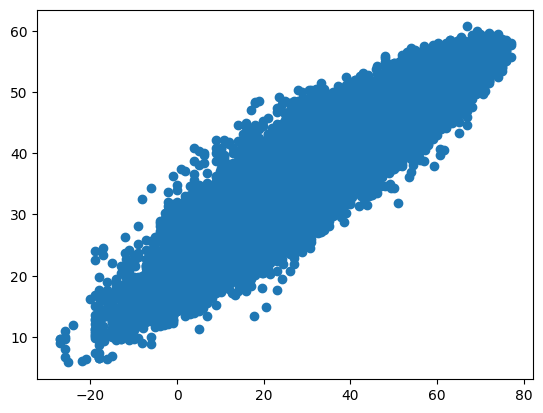

In [19]:
# pred1
plt.scatter(y[:,0], pred[:,0])
plt.show()

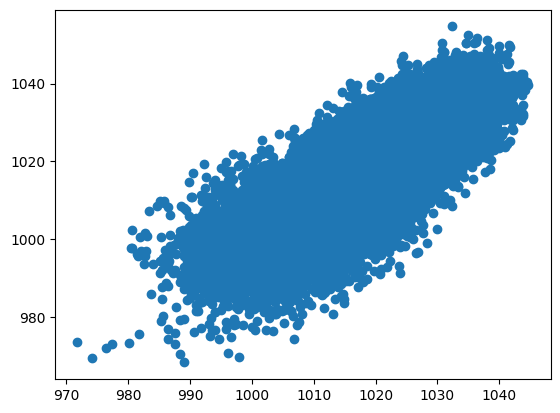

In [20]:
# pred2
plt.scatter(y[:,1], pred[:,1])
plt.show()

In [21]:
# it worked! predict two outputs at once -
# may have taken longer to fit,
# but it worked great!

# you may also try other architectures
# and advanced methods (Conv1D and MaxPooling1D etc)